# 타이타닉 생존 예측과 주요 특성 해석

## 프로젝트 요약

공개 정답이 있는 승객 891명의 특성으로 생존 여부를 예측하고, 성능 비교와 예측 근거를 함께 분석했다. 데이터 품질 점검, 호칭·가족 규모 파생변수, 탐색적 분석, 11개 분류모형 비교와 튜닝, 과적합 진단, 변수 축소 및 SHAP을 수행했다.

내부 검증 179건에서 **KNN이 F1 0.773·정확도 83.2%로 비교표 1위**였다. 그러나 KNN의 LogLoss는 1.710으로, 분류 성능과 확률 예측 품질이 같은 순위를 보이지 않았다. 7개 변수를 사용한 튜닝 RandomForest는 F1 0.734·ROC-AUC 0.860·LogLoss 0.433을 기록했다.

RandomForest의 입력을 7개에서 5개로 줄이면 F1은 0.713으로 낮아졌다. 따라서 변수 축소를 성능 개선으로 채택하지 않았으며, 축소 모델의 SHAP은 예측 기여를 해석한 별도 분석 결과로 구분했다. 호칭의 중요도가 가장 높았고 객실 등급·요금·연령·객실 번호 기록 유무도 예측에 기여했다.

## 분석 질문

1. 성별·호칭·객실 등급·가족 규모에 따라 표본 내 생존율이 어떻게 달라지는가?
2. 동일한 훈련·검증 분할에서 어떤 분류모형이 좋은 성능을 보이는가?
3. 중요도가 높은 변수만 남기면 성능을 유지할 수 있는가?
4. 모델은 어떤 특성을 이용해 생존 예측을 높이거나 낮추는가?

## 데이터와 평가 범위

`jussam.load_data("titanic")`로 불러온 자료 중 PassengerId 1~891만 사용했다. Kaggle의 정답 비공개 테스트 구간에 해당하는 나머지 418건은 학습·평가에서 제외했다. 파생변수와 모델 입력은 같은 891건의 원자료에서 구성했다.

훈련 712건·내부 검증 179건으로 계층화 분할하고, 훈련 데이터 안에서 5-fold 교차검증으로 튜닝했다. 본문의 Test는 내부 검증셋을 뜻하며 Kaggle 비공개 테스트 점수가 아니다. 수치는 저장된 실행 출력에 근거하며, 표의 반올림에 따라 표시 자릿수가 다를 수 있다.

## 구성

- [1. 데이터 품질 점검과 파생변수](#stage-1)
- [2. 탐색적 분석과 변수 검토](#stage-2)
- [3. 분류모형 베이스라인 비교](#stage-3)
- [4. 하이퍼파라미터 튜닝](#stage-4)
- [5. 과적합 진단과 변수 축소](#stage-5)
- [6. 변수 축소 모델의 SHAP 해석](#stage-6)
- [7. 종합 결론과 한계](#conclusion)

데이터 기준: [Kaggle Titanic](https://www.kaggle.com/competitions/titanic/data), 로딩 배포본: [Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset).


In [1]:
# 프로젝트 폴더 안의 helpers와 상대 저장 경로를 사용한다.
from pathlib import Path
import os
import sys

project_dir = Path.cwd()
if not (project_dir / "titanic-survival-analysis.ipynb").is_file():
    project_dir = project_dir / "kaggle프로젝트" / "Titanic 생존 예측"
if not (project_dir / "titanic-survival-analysis.ipynb").is_file():
    raise FileNotFoundError("이 노트북이 있는 프로젝트 폴더에서 실행해 주세요.")
if "helpers" in sys.modules:
    loaded_helpers = Path(sys.modules["helpers"].__file__).resolve().parent
    if loaded_helpers != (project_dir / "helpers").resolve():
        raise RuntimeError("다른 프로젝트의 helpers가 로드되어 있습니다. 커널을 재시작해 주세요.")
os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print("작업 폴더:", project_dir)


작업 폴더: c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측


<a id="stage-1"></a>

## 1. 데이터 품질 점검과 파생변수

분석 대상 891건에 대해 식별자, 중복, 자료형, 결측을 점검했다. 이름의 호칭과 본인을 포함한 가족 규모를 파생변수로 구성하고, 원자료를 보존하여 EDA와 모델링의 전처리를 구분했다.


### 분석 설정

#### 1. 라이브러리 참조

In [2]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

from pandas import DataFrame, crosstab


📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 데이터 불러오기

In [3]:
# 공개 정답이 있는 Kaggle train 구간만 사용한다.
# 892~1309번의 패키지 라벨은 실제 정답으로 사용하지 않는다.
loaded = load_data("titanic")
assert loaded["PassengerId"].is_unique, "PassengerId 중복을 확인하세요."
origin = loaded.loc[loaded["PassengerId"].between(1, 891)].copy()
origin = origin.sort_values("PassengerId").reset_index(drop=True)
assert origin["PassengerId"].tolist() == list(range(1, 892))
assert origin["Survived"].notna().all()
assert origin["Survived"].value_counts().to_dict() == {0: 549, 1: 342}
raw_train = origin.copy()  # 뒤의 모델링 단계에서도 이 원자료를 사용
print(f"로딩 {len(loaded):,}건 → 분석 {len(origin):,}건 / 제외 {len(loaded)-len(origin):,}건")
display(origin.head())


📚 타이타닉호 침몰은 역사상 가장 악명 높은 난파 사고 중 하나입니다. 1912년 4월 15일, 첫 항해 중이던 타이타닉호는 빙산과 충돌하여 침몰했습니다. 당시 배에는 모든 승객과 승무원을 태울 수 있는 구명보트가 충분하지 않아 2,224명의 승객과 승무원 중 1,502명이 목숨을 잃었습니다. 생존에는 어느 정도 운이 작용했지만, 일부 집단은 다른 집단보다 생존 가능성이 더 높았던 것으로 보입니다. 이번 과제에서는 승객 데이터(예: 이름, 나이, 성별, 사회경제적 계층 등)를 사용하여 `어떤 유형의 사람들이 생존할 가능성이 더 높았을까?`라는 질문에 답하는 예측 모델을 구축해야 합니다. (출처: https://www.kaggle.com/datasets/yasserh/titanic-dataset)

변수명       설명
-----------  -------------------------------------------------------
PassengerId  탑승객의 ID(인덱스와 같은 개념)
Survived     생존유무(0은 사망 1은 생존)
Pclass       객실의 등급(1=1등급, 2=2등급, 3=3등급)
Name         이름
Sex          성별
SibSp        동승한 형제 혹은 배우자의 수
Parch        동승한 자녀 혹은 부모의 수
Ticket       티켓번호
Fare         요금
Cabin        선실
Embarked     탑승지 (C = Cherbourg, Q = Queenstown, S = Southampton)

로딩 1,309건 → 분석 891건 / 제외 418건


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


#### 3. 컬럼 의미를 정리한 딕셔너리

In [4]:
column_means = {
    "PassengerId": "탑승객 식별자",
    "Survived":    "생존 여부 (0=사망, 1=생존)",
    "Pclass":      "객실 등급 (1=1등급, 2=2등급, 3=3등급)",
    "Name":        "이름",
    "Sex":         "성별",
    "Age":         "나이",
    "SibSp":       "동승한 형제·배우자 수",
    "Parch":       "동승한 부모·자녀 수",
    "Ticket":      "티켓 번호",
    "Fare":        "요금",
    "Cabin":       "선실 번호",
    "Embarked":    "탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)",
}


### 데이터 품질 점검

#### 1. 자료형 확인

In [5]:
origin.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### 2. 데이터 중복 점검

분석 대상의 중복 행은 0건이며, PassengerId의 유일성과 1~891 구간을 함께 확인했다.


In [6]:
df0 = my_qtcheck.check_duplicates(origin, drop=True)


중복된 행의 수: 0


#### 3. 불필요한 컬럼 제거와 자료형 변환

PassengerId는 식별자이고, Name·Ticket·Cabin은 문자열 원문이므로 EDA 작업본에서 제외했다. 원자료는 남겨 두어 Name에서 Title을 추출하고, 모델링에서 Cabin 기록 유무를 HasCabin으로 구성했다. 따라서 원문 컬럼 제외가 모든 정보를 폐기했다는 뜻은 아니다.

Survived·Pclass·Sex·Embarked를 범주형으로 변환했다. Pclass의 숫자는 등급을 구분하며, 3등급이 1등급의 3배라는 연속적 크기로 해석하지 않는다. HasCabin 역시 객실 번호가 기록되어 있는지를 뜻할 뿐, 객실의 존재나 소유를 직접 측정하지 않는다.


In [7]:
# 원본에서 제거된 중복 데이터가 없으므로 계속 원본 사용
df0 = origin.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df1 = my_qtcheck.set_type(df0, as_category=["Survived", "Pclass", "Sex", "Embarked"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  889 non-null    category
dtypes: category(4), float64(2), int64(2)
memory usage: 32.0 KB


#### 4. 결측치 점검

In [8]:
my_qtcheck.check_missing_values(df1)


,Missing Count,Missing Ratio (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,177,19.865
SibSp,0,0.000
Parch,0,0.000
Fare,0,0.000
Embarked,2,0.224


#### 5. 결측치 처리와 적용 범위

Age는 177건(19.9%), Embarked는 2건(0.2%)이 결측이고 Fare에는 결측이 없었다. EDA에서는 Age의 결측을 중앙값 28세로 대체했다. 이로 인해 28세 주변에 인공적인 집중이 생기므로 연령 분포와 검정 결과에는 대체의 영향이 포함된다.

**Embarked는 최빈값 대체 호출 이후에도 결측 2건이 남아 있다.** 사용한 EDA 함수가 최빈값을 단일 값이 아닌 Series로 전달하여 인덱스에 맞춰 대체하기 때문이다. 아래 품질 점검 출력에 이를 그대로 남겼으며, 승선항의 빈도·생존율·교차분석은 결측이 제외된 **889건** 기준으로 해석했다. 결측이 모두 제거되었다고 보지 않는다.

모델링에는 이 EDA 작업본을 전달하지 않았다. 대체 전 원자료에서 다시 구성한 891건을 사용하고, 모델 파이프라인의 SimpleImputer가 수치형 중앙값·범주형 최빈값을 훈련 데이터에서 학습했다. 튜닝에서도 각 교차검증 훈련 fold에서 대체값을 학습하므로, EDA의 Embarked 결측 잔존과 모델 전처리는 구분된다.


In [9]:
df2 = my_prep.replace_missing(df1, columns=["Age", "Fare"], method="median")
df3 = my_prep.replace_missing(df2, columns=["Embarked"], method="mode")

# 결측치가 모두 처리되었는지 확인
my_qtcheck.check_missing_values(df3)


결측치 처리 방식: 'median'
컬럼                     결측치                 대체값
--------------------------------------------
Age          177개(19.9%)              28.0
Fare            0개(0.0%)           14.4542
결측치 처리 방식: 'mode'
컬럼                     결측치                 대체값
--------------------------------------------
Embarked        2개(0.2%)0    S
Name: Embarked, dtype: category
Categories (3, object): ['C', 'Q', 'S']


,Missing Count,Missing Ratio (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,0,0.000
SibSp,0,0.000
Parch,0,0.000
Fare,0,0.000
Embarked,2,0.224


#### 6. 파생변수 생성 — 동승 가족 수 계산

In [10]:
# 결측 처리까지 끝난 데이터에 파생변수를 더한다 (df3 는 그대로 보존)
derived = df3.copy()

# 새로운 파생 변수 생성
derived["FamilySize"] = derived["SibSp"] + derived["Parch"] + 1

# 컬럼 의미 갱신
column_means["FamilySize"] = "동승 가족 수 (SibSp + Parch + 본인)"

# 결과 확인
derived.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.000,1,0,7.250,S,2
1,1,1,female,38.000,1,0,71.283,C,2
2,1,3,female,26.000,0,0,7.925,S,1
3,1,1,female,35.000,1,0,53.100,S,2
4,0,3,male,35.000,0,0,8.050,S,1


#### 7. 신분 파생변수 추가 (1) - 이름에서 호칭 분리

- 타이타닉의 이름은 `Braund, Mr. Owen Harris`처럼 **`성, 호칭. 이름`** 형식으로 통일되어 있다.
  → **쉼표와 마침표 사이**를 뽑으면 호칭이 나온다. 정규식 `,\s*([^\.]+)\.` 이 그 일을 한다.
- 뽑아 쓰는 대상은 **`origin["Name"]`** 이다. 작업본에서는 이미 지운 컬럼이지만 원본에는 남아 있다.

In [11]:
# ── ① 이름에서 호칭 추출 : "성, 호칭. 이름" 형식이므로 쉼표와 마침표 사이를 뽑는다
title_raw = origin["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
title_raw = title_raw.str.strip()

display(Markdown("**원본 호칭 (통합 전)**"))
display(title_raw.value_counts().rename("빈도").to_frame().T)


**원본 호칭 (통합 전)**

Name,Mr,Miss,Mrs,Master,Dr,Rev,Col,Mlle,Major,Ms,Mme,Don,Lady,Sir,Capt,the Countess,Jonkheer
빈도,517,182,125,40,7,6,2,2,2,1,1,1,1,1,1,1,1


#### 8. 신분 파생변수 추가 (2) - 의미별 호칭 정의

In [12]:
# ── 원본 호칭을 의미가 같은 것끼리 묶어 5종으로 통합한다
#    (도메인 지식이 필요한 부분)
title_map = {
    # 성인 남성 — Don(스페인)·Sir(영국)·Jonkheer(네덜란드)는 남성 귀족 경칭
    "Mr": "Mr", "Don": "Mr", "Sir": "Mr", "Jonkheer": "Mr",
    # 미혼 여성 — Mlle(프랑스)=Miss, Ms=혼인 여부를 밝히지 않는 호칭
    "Miss": "Miss", "Mlle": "Miss", "Ms": "Miss",
    # 기혼 여성 — Mme(프랑스)·Dona(스페인)=Mrs, Lady·the Countess는 여성 귀족 경칭
    "Mrs": "Mrs", "Mme": "Mrs", "Dona": "Mrs", "Lady": "Mrs", "the Countess": "Mrs",
    # 남자아이
    "Master": "Master",
    # 전문직·군인·성직자 — 이름에 직위가 드러난 사람들
    "Dr": "Officer", "Rev": "Officer", "Col": "Officer", "Major": "Officer", "Capt": "Officer",
}


#### 9. 호칭 파생변수 추가

이름에서 추출한 17종의 호칭을 Mr·Miss·Mrs·Master·Officer의 5개 집단으로 통합했다. 매핑 누락은 0건이다. Mr 520명, Miss 185명, Mrs 128명, Master 40명, Officer 18명으로 집단 크기에 차이가 있다.


In [13]:
# ── Title 변수 추가 (origin 과 인덱스가 같으므로 그대로 붙는다)
derived["Title"] = title_raw.map(title_map)

# ── 매핑 누락 점검 : 결측이 1건이라도 있으면 title_map 에 빠진 호칭이 있다는 뜻이다
print("Title 매핑 누락 :", derived["Title"].isna().sum(), "건\n")

# ── 문자열이므로 명목형으로 선언한다. 그대로 두면 더미 인코딩 대상이 되지 않는다
derived = my_qtcheck.set_type(derived, as_category=["Title"])

# ── 컬럼 의미 사전도 함께 갱신한다 (이후 EDA 반복문이 이 사전을 참조한다)
column_means["Title"] = "이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)"

display(origin[["Name"]].join(derived[["Title", "SibSp", "Parch", "FamilySize"]]).head())
display(derived["Title"].value_counts().rename("빈도").to_frame().T)


Title 매핑 누락 : 0 건

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    category
 1   Pclass      891 non-null    category
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Embarked    889 non-null    category
 8   FamilySize  891 non-null    int64   
 9   Title       891 non-null    category
dtypes: category(5), float64(2), int64(3)
memory usage: 40.0 KB


,Name,Title,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",Mr,1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mrs,1,0,2
2,"Heikkinen, Miss. Laina",Miss,0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2
4,"Allen, Mr. William Henry",Mr,0,0,1


Title,Mr,Miss,Mrs,Master,Officer
빈도,520,185,128,40,18


#### 10. 호칭에 포함된 정보 확인

Mr 집단 520명과 Master 집단 40명은 모두 남성, Miss 185명과 Mrs 128명은 모두 여성이다. Officer에는 남성 17명·여성 1명이 포함된다. 따라서 Title은 성별과 상당 부분 정보가 겹치지만 성별과 완전히 같은 변수는 아니다.

결측이 아닌 원래 나이의 중앙값은 Master 3.5세, Miss 21세, Mr 30세, Mrs 35세, Officer 50세였다. 호칭에 연령과 관련된 정보도 포함되지만, Title만으로 실제 나이·혼인 상태·사회적 지위를 정확히 알 수 있다고 해석하지 않는다. Officer는 전문직·군인·성직자 호칭을 묶은 이름이며 승무원 여부가 아니다.


In [14]:
# ── 호칭이 정말 '신분'을 담고 있는지 확인한다
display(Markdown("**호칭별 성별 분포**"))
display(crosstab(derived["Title"], derived["Sex"]))

# ⚠️ 나이는 결측을 채우기 전인 origin 기준으로 본다.
# -> derived 의 Age 는 중앙값 28세로 채워져 있어 호칭별 분포가 왜곡된다.
display(Markdown("**호칭별 나이 요약 (결측 대체 전 · `origin` 기준)**"))
display(origin.assign(Title=derived["Title"])
              .groupby("Title", observed=True)["Age"]
              .agg(["count", "median", "min", "max"]).T)


**호칭별 성별 분포**

Sex,female,male
Title,,
Master,0,40
Miss,185,0
Mr,0,520
Mrs,128,0
Officer,1,17


**호칭별 나이 요약 (결측 대체 전 · `origin` 기준)**

Title,Master,Miss,Mr,Mrs,Officer
count,36.000,149.000,401.000,111.000,17.000
median,3.500,21.000,30.000,35.000,50.000
min,0.420,0.750,11.000,14.000,23.000
max,12.000,63.000,80.000,63.000,70.000


#### 11. 명목형 변수의 기술 통계량

In [15]:
cat_desc = my_qtcheck.categorical_summary(derived, value_counts=False)
cat_desc


,Survived,Pclass,Sex,Embarked,Title
count,891,891,891,889,891
unique,2,3,2,3,5
top,0,3,male,S,Mr
freq,549,491,577,644,520


#### 12. 연속형 변수의 기술 통계량

결측 대체 후의 분포, 사분위수와 이상치 표시를 정리했다. 수치의 의미와 처리 판단은 다음 절의 단변량 분석에서 해석한다.


In [16]:
num_desc = my_qtcheck.numerical_summary(derived)
num_desc.T


,Age,SibSp,Parch,Fare,FamilySize
count,891.000,891.000,891.000,891.000,891.000
mean,29.362,0.523,0.382,32.204,1.905
std,13.020,1.103,0.806,49.693,1.613
min,0.420,0.000,0.000,0.000,1.000
25%,22.000,0.000,0.000,7.910,1.000
50%,28.000,0.000,0.000,14.454,1.000
75%,35.000,1.000,0.000,31.000,2.000
max,80.000,8.000,6.000,512.329,11.000
rel_diff,0.049,inf,inf,1.228,0.905
rdiff_flag,similar,large_diff,large_diff,large_diff,large_diff


### 변수 유형 분류와 EDA 범위

#### 1. 변수 유형 분류

In [17]:
target = "Survived"    # 종속변수
target_is_continuous = False    # 종속변수 연속형 여부  --> 로지스틱이므로 False
nominal_cols = my_qtcheck.get_categorical_column_names(derived) # 명목형 변수
continuous_cols = my_qtcheck.get_number_column_names(derived)   # 연속형 변수

if target_is_continuous:
    continuous_cols.remove(target)  # 연속형 변수 이름에서 종속변수 항목 제거
else:
    nominal_cols.remove(target)     # 명목형 변수 이름에서 종속변수 항목 제거

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)


종속변수 : Survived
종속변수 유형: 명목형
명목형   : ['Pclass', 'Sex', 'Embarked', 'Title']
연속형   : ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']


#### 2. 범주 순서 지정 (서열척도 · 기준 범주)

- 명목형 범주의 순서를 손봐야 하는 경우는 **두 가지**이고, 목적이 서로 다르다.

| 목적 | 대상 | `ordered` | 뜻 |
|---|---|---|---|
| **서열척도 선언** | `Pclass` | `True` | 범주 사이에 **크고 작음이 실제로 있다** |
| **기준 범주 지정** | `Title` | `False` | 순서는 없지만 **더미의 기준을 정하고 싶다** |

In [18]:
# ① 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
ordinal_map = {
    "Pclass": [3, 2, 1],    # 3등급 < 2등급 < 1등급
}

# ② 서열은 없지만 더미변수의 기준(reference) 범주를 지정하기 위해 순서만 재배치할 변수
# -> 맨 앞에 둔 범주가 drop_first 로 빠지면서 기준이 된다.
reference_map = {
    "Title": ["Mr", "Officer", "Master", "Miss", "Mrs"],    # 기준: Mr (성인 남성)
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
df = derived.copy()

for col, order in ordinal_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (서열척도)   : {order}")
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

for col, order in reference_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (기준 범주용) : {order}")
        # ordered=False -> 순서만 바꿀 뿐 서열척도로 선언하지는 않는다
        df[col] = df[col].cat.reorder_categories(order, ordered=False)


'Pclass' 컬럼 순서 재지정 (서열척도)   : [3, 2, 1]
'Title' 컬럼 순서 재지정 (기준 범주용) : ['Mr', 'Officer', 'Master', 'Miss', 'Mrs']


#### 3. EDA 범위 정리

| 종속유형 | 독립유형 | 분석 유형 | 대상 변수 | 적용 여부 | 비고 |
|---|---|---|---|---|---|
| 연속형 | 연속형 | 상관분석 | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| 연속형 | 명목형(2집단) | T검정 | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| 연속형 | 명목형(3집단+) | ANOVA | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| **명목형(2집단)** | **연속형** | **T검정** | `Age`·`SibSp`·`Parch`·`Fare`·**`FamilySize`** → `Survived` | ✅ **적용** | |
| **명목형(2집단)** | **명목형(2집단)** | **교차분석** | `Sex` → `Survived` | ✅ **적용** | |
| **명목형(2집단)** | **명목형(3집단+)** | **교차분석** | `Pclass`·`Embarked`·**`Title`** → `Survived` | ✅ **적용** | |
| 명목형(3집단+) | 연속형 | ANOVA | — | ❌ 미적용 | 종속변수가 2집단 |
| 명목형(3집단+) | 명목형(2집단) | 교차분석 | — | ❌ 미적용 | 종속변수가 2집단 |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석 | — | ❌ 미적용 | 종속변수가 2집단 |

<a id="stage-2"></a>

## 2. 탐색적 분석과 변수 검토

단변량 분포, 생존 집단 간 수치형 분포 차이, 범주별 생존율, 독립변수 간 중복을 살펴봤다. 관계의 유의성과 크기를 함께 검토하되, 관찰 데이터의 연관성을 인과관계로 해석하지 않았다.


### 단변량 분석

#### 1. 명목형 종속변수에 대한 단변량 분석

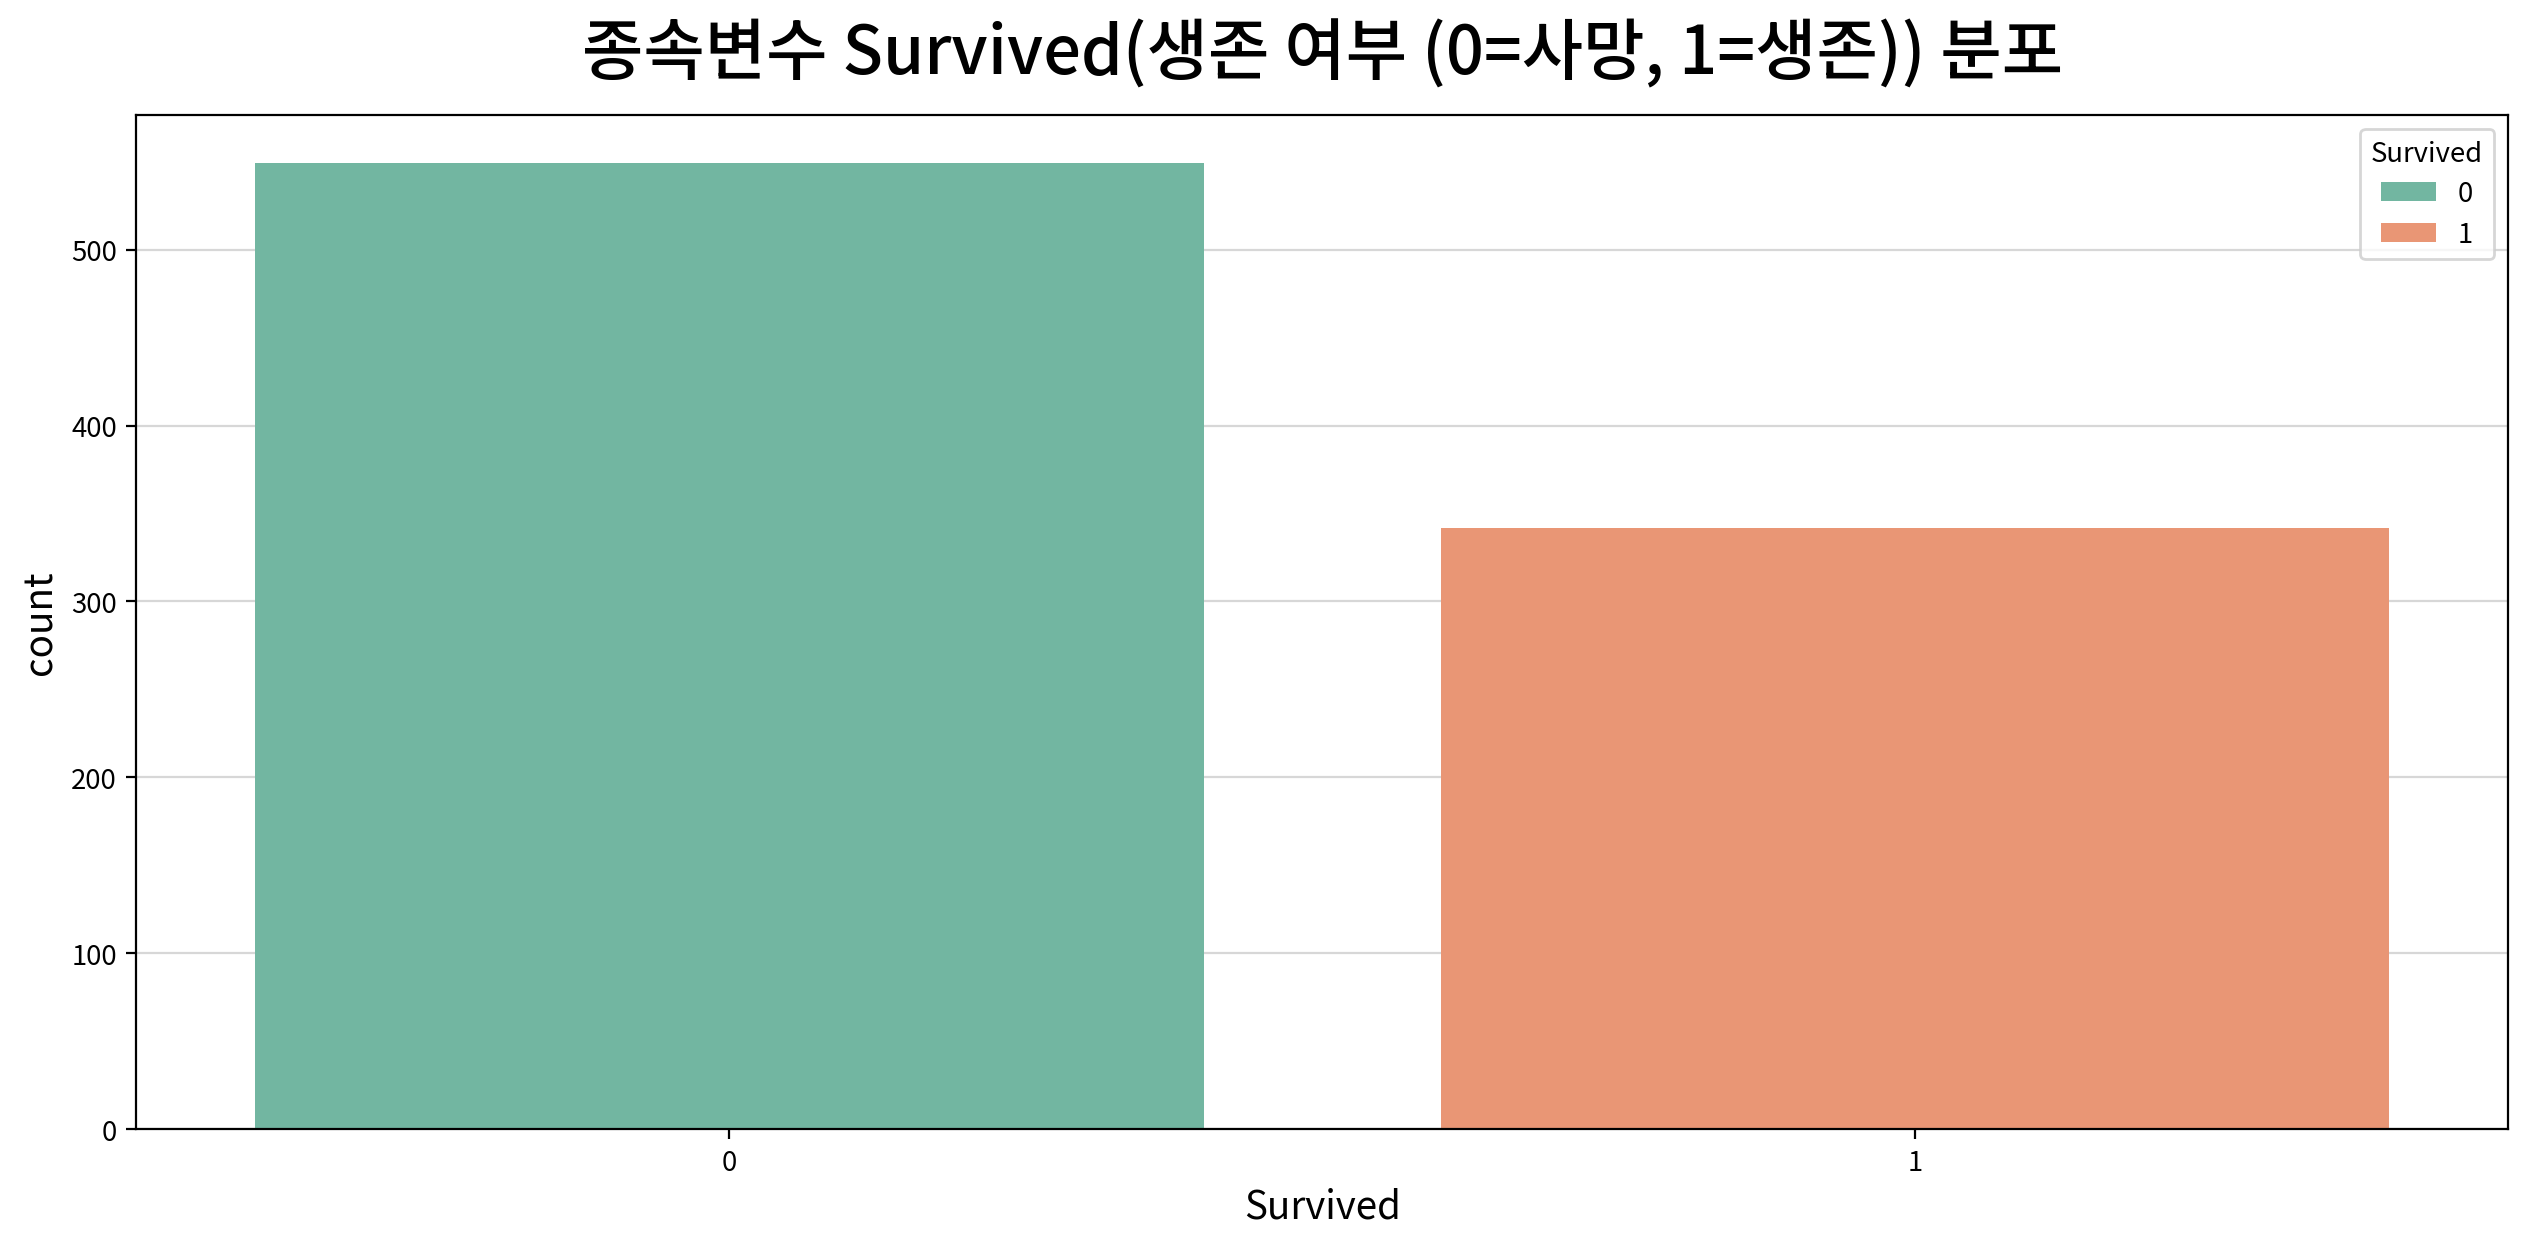

,count,unique,top,freq
Survived,891,2,0,549


,빈도,비율
Survived,,
0,549,0.616
1,342,0.384


In [19]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette="Set2",
                  title=f"종속변수 {target}({column_means[target]}) 분포")

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename("빈도").to_frame()
freq["비율"] = df[target].value_counts(normalize=True)
display(freq)


##### 생존 라벨 분포 해석

사망은 549명(61.6%), 생존은 342명(38.4%)이다. 전체 표본에서 모두 사망으로 예측해도 정확도 약 61.6%가 나오므로 정확도만으로 모델의 가치를 판단하지 않았다. 이는 다수 클래스 기준값이지 모든 모델이 반드시 넘어야 하는 수학적 하한은 아니다.

생존(1)을 양성으로 두었다. 정밀도는 생존 예측의 정확성, 재현율은 실제 생존자를 놓치지 않는 정도, F1은 두 지표의 조화를 나타낸다. ROC-AUC와 LogLoss를 함께 보아 분류 결과·순위 구분·확률 예측 품질을 나누어 평가했다. 리샘플링은 적용하지 않았다.


#### 2. 명목형 독립변수에 대한 단변량 분석

- 명목형 독립변수도 **범주별 빈도의 쏠림**을 확인한다.
  한 범주에 관측치가 지나치게 적으면 그 더미변수의 계수가 불안정해지기 때문이다.

### ▶︎ Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) 분포

Pclass,3,1,2
빈도,491.000,216.000,184.000
비율,0.551,0.242,0.207


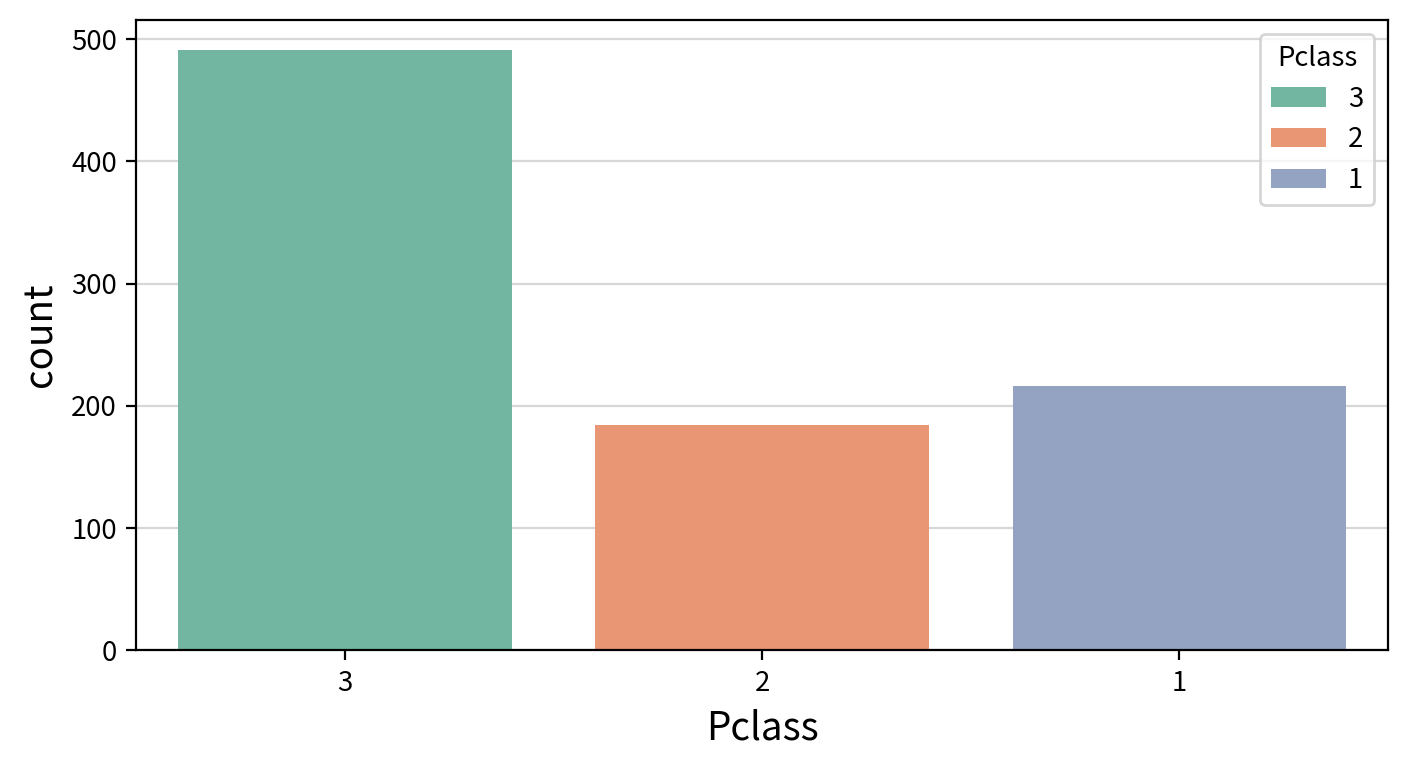

### ▶︎ Sex(성별) 분포

Sex,male,female
빈도,577.000,314.000
비율,0.648,0.352


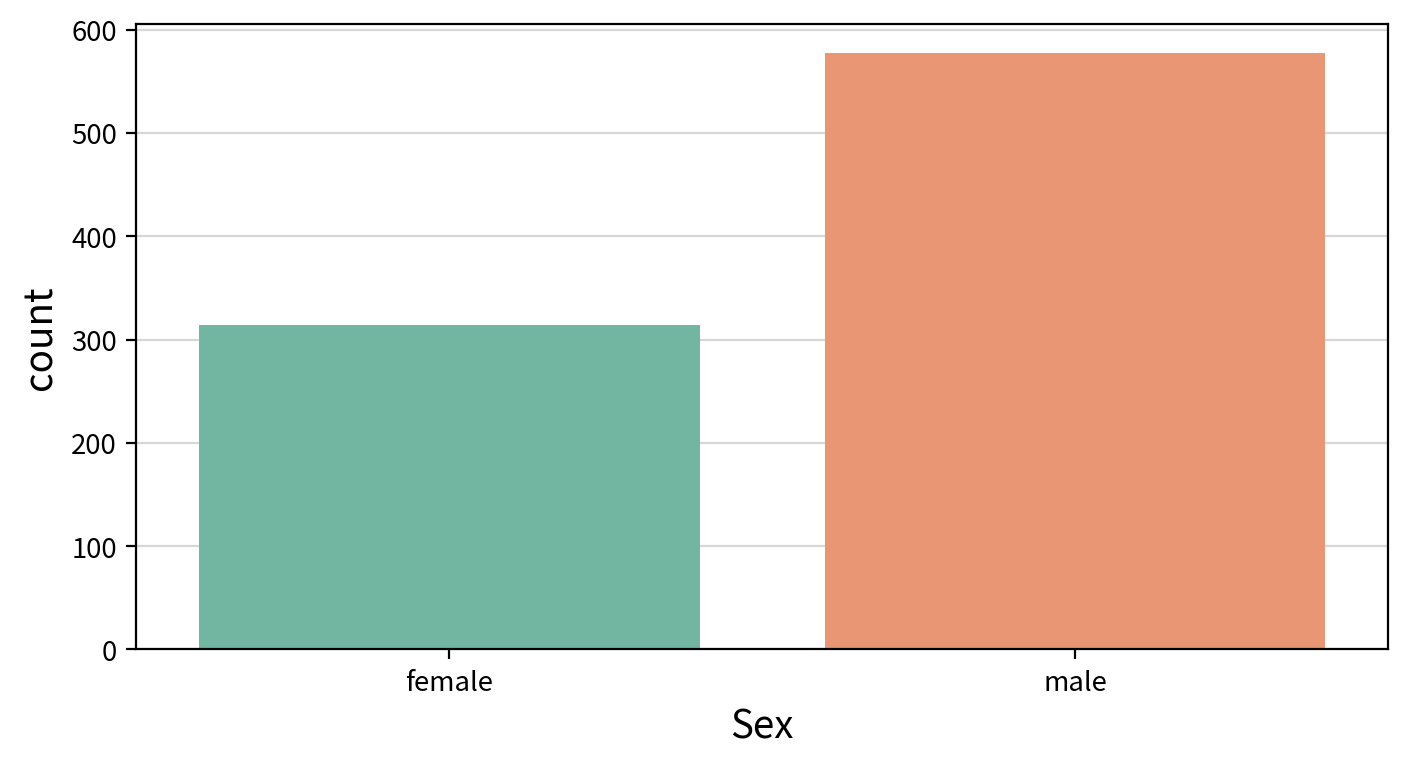

### ▶︎ Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) 분포

Embarked,S,C,Q
빈도,644.000,168.000,77.000
비율,0.724,0.189,0.087


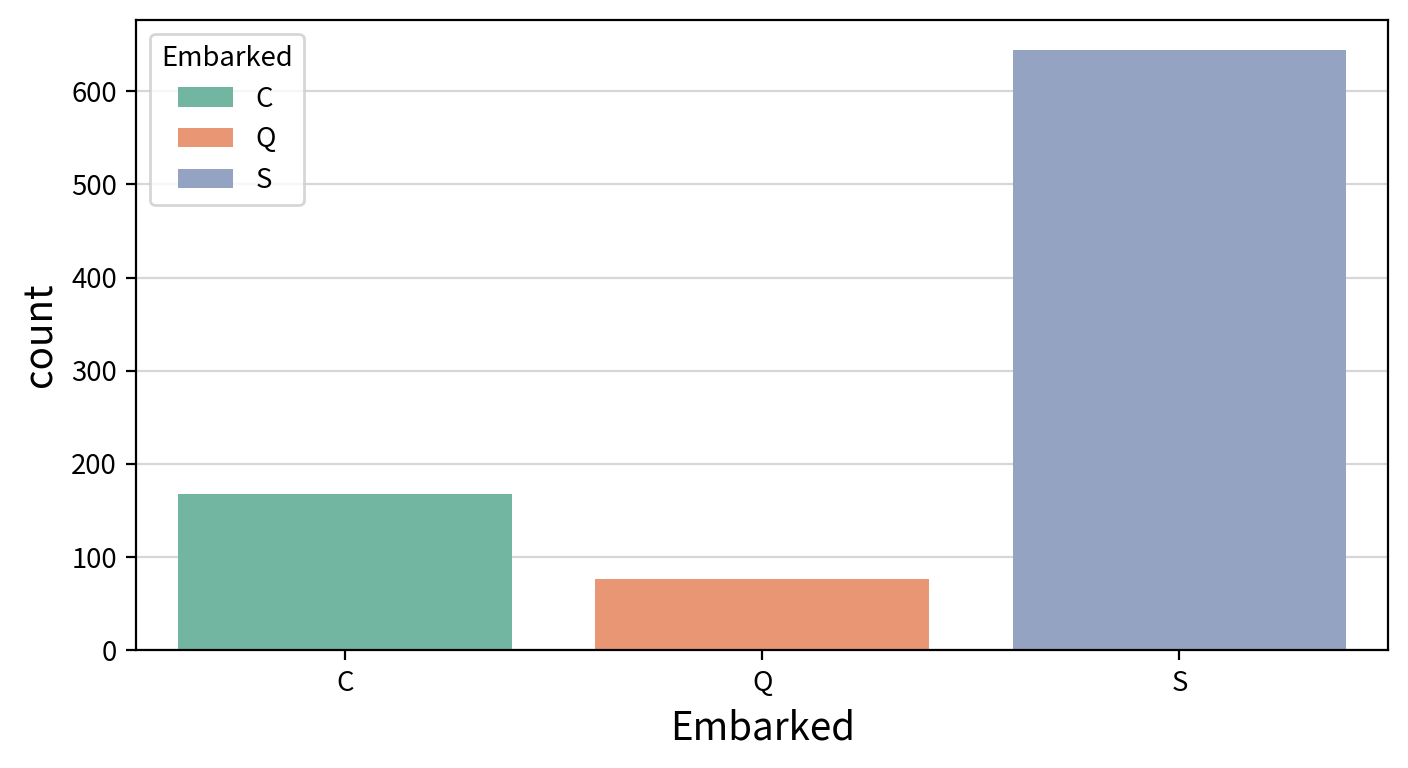

### ▶︎ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) 분포

Title,Mr,Miss,Mrs,Master,Officer
빈도,520.000,185.000,128.000,40.000,18.000
비율,0.584,0.208,0.144,0.045,0.020


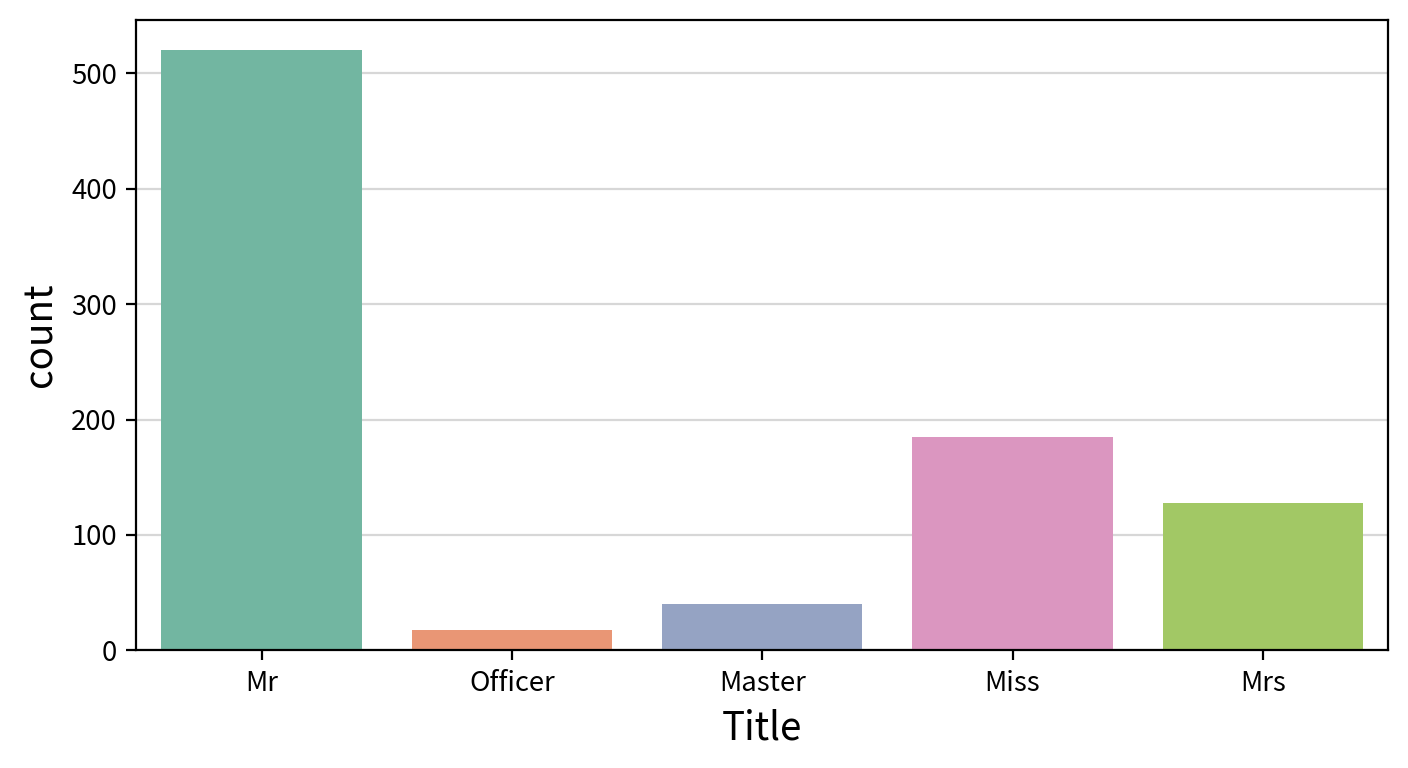

In [20]:
for n in nominal_cols:
    display(Markdown(f"### ▶︎ {n}({column_means[n]}) 분포"))
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq.T)
    
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", width=720, height=400)


##### 범주 분포 해석

| 변수 | 관찰 결과 | 해석상 주의점 |
|---|---|---|
| Pclass | 3등급 491명, 1등급 216명, 2등급 184명 | 3등급이 55.1%로 가장 많음 |
| Sex | 남성 577명(64.8%), 여성 314명(35.2%) | 전체 승객 모집단이 아닌 공개 학습 표본의 구성 |
| Embarked | S 644명, C 168명, Q 77명 | 결측을 제외한 889명 기준; S가 72.4% |
| Title | Mr 520명, Miss 185명, Mrs 128명, Master 40명, Officer 18명 | 희소 집단의 비율은 적은 수의 관측에도 변동 가능 |

호칭 통합은 희소 범주를 줄였지만, Officer의 표본은 여전히 작다. 이 집단의 생존율이나 SHAP 패턴을 다른 집단만큼 안정적인 것으로 일반화하지 않았다. 호칭·성별의 정보 중복도 이후 해석에 반영했다.


#### 3. 연속형 독립변수에 대한 단변량 분석

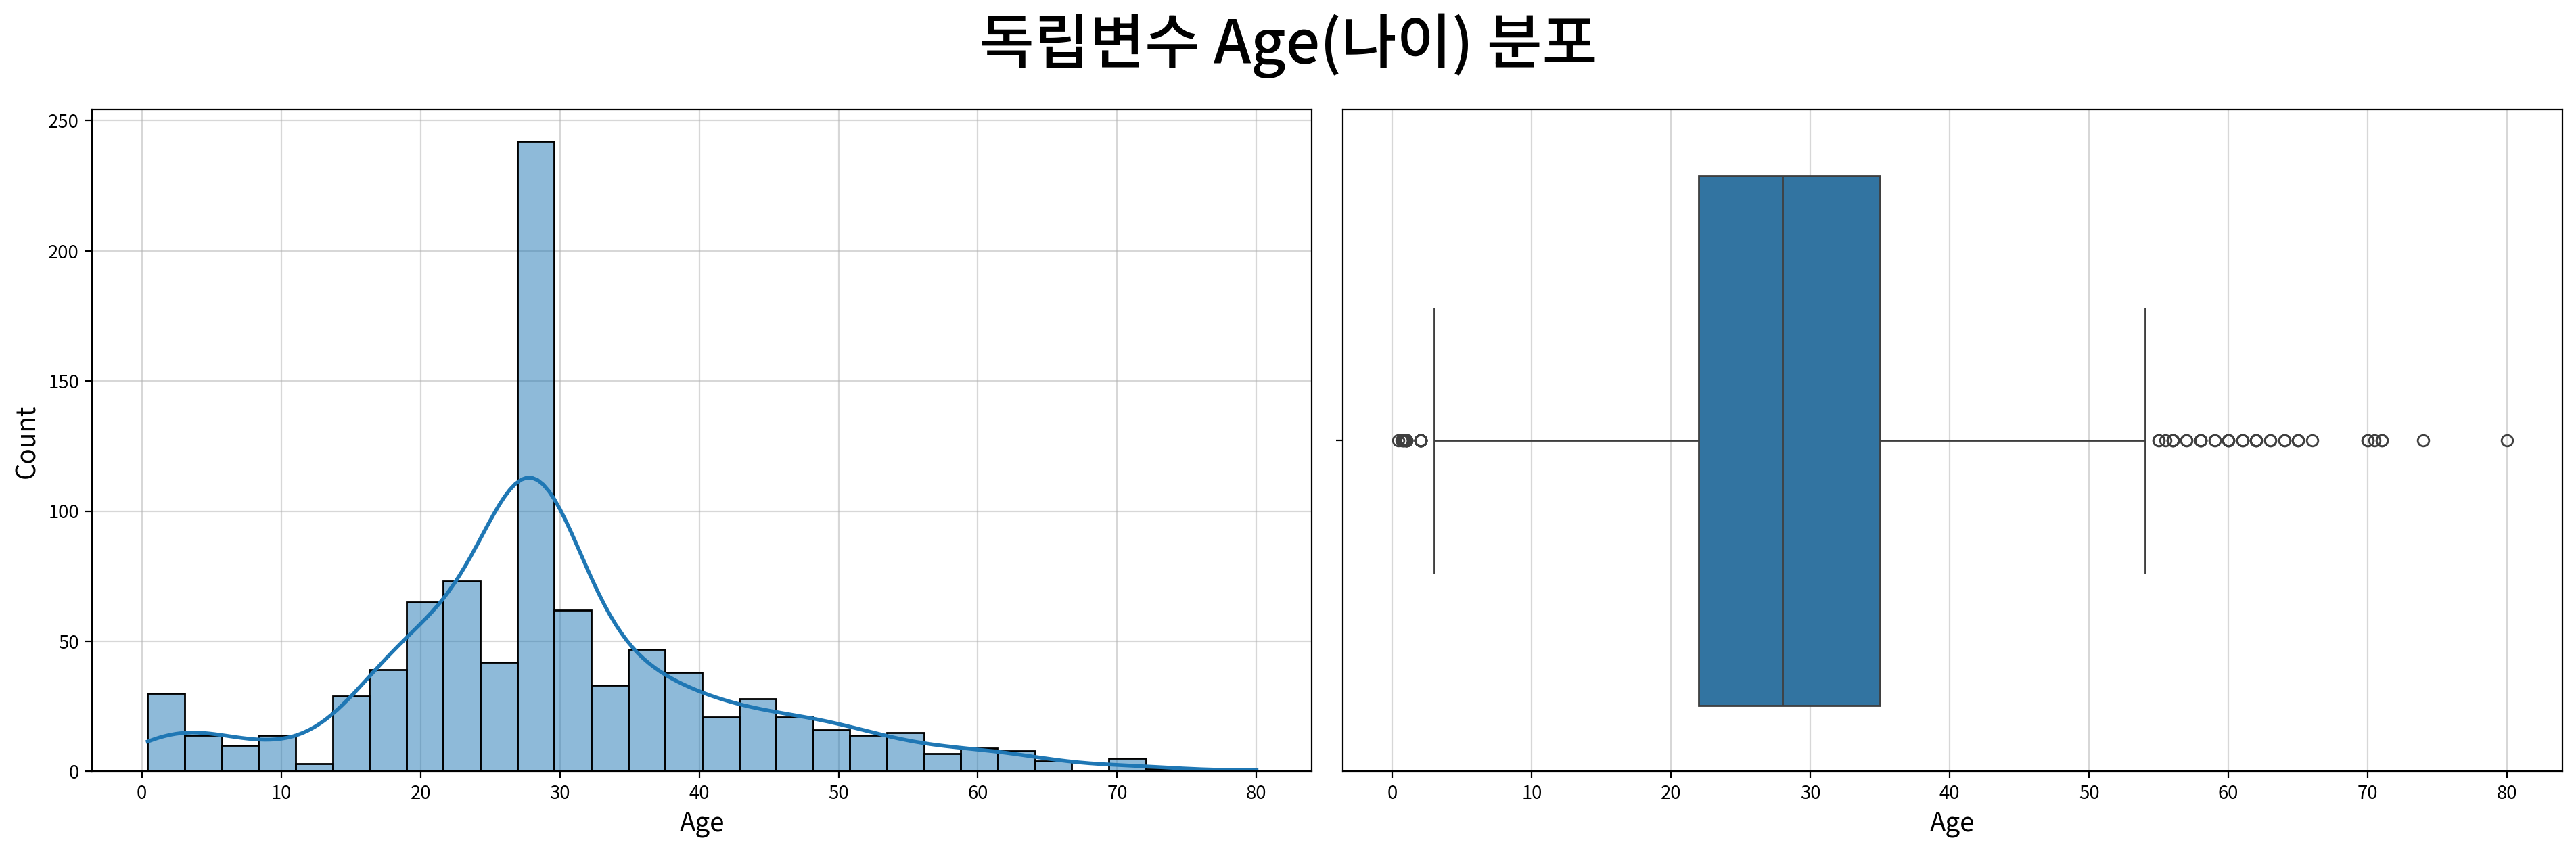

,Age
count,891.000
mean,29.362
std,13.020
min,0.420
25%,22.000
50%,28.000
75%,35.000
max,80.000
rel_diff,0.049
rdiff_flag,similar


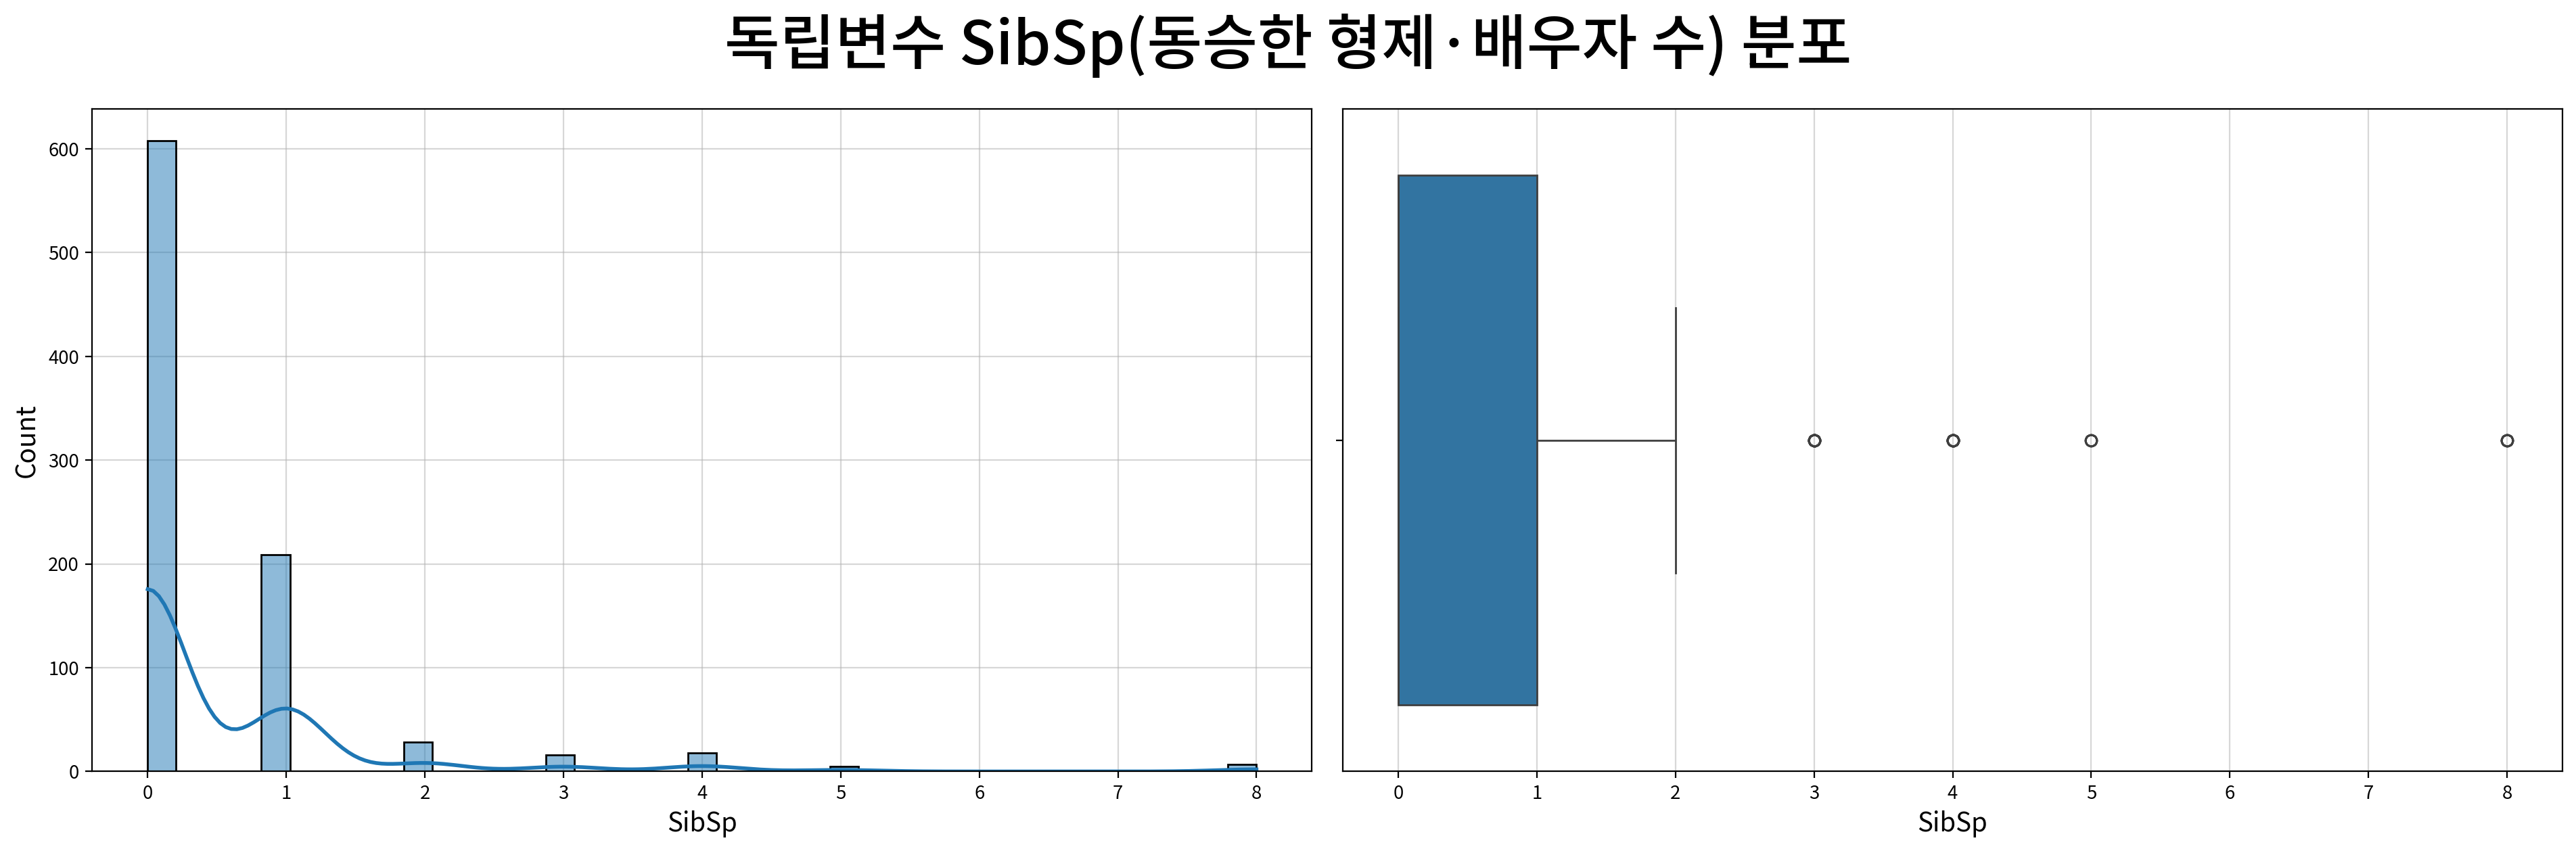

,SibSp
count,891.000
mean,0.523
std,1.103
min,0.000
25%,0.000
50%,0.000
75%,1.000
max,8.000
rel_diff,inf
rdiff_flag,large_diff


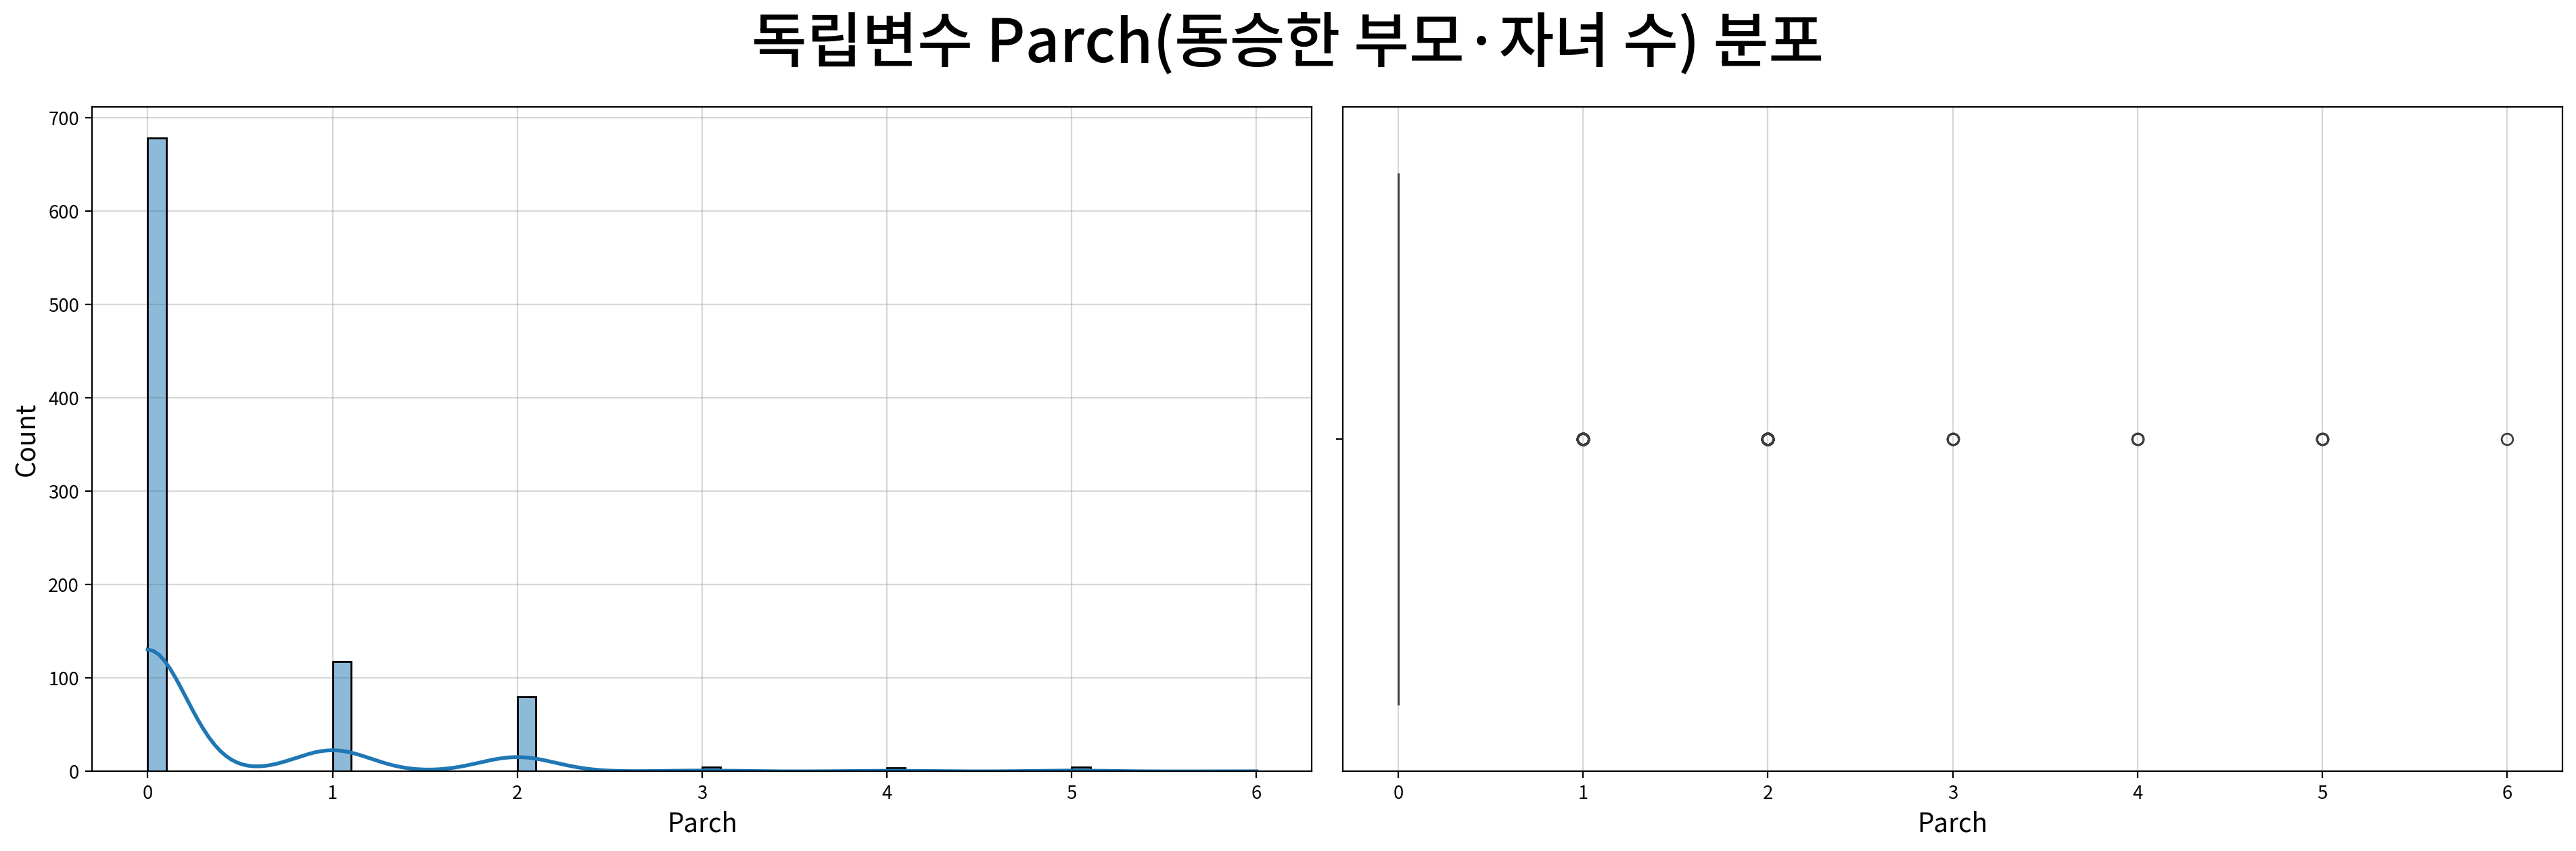

,Parch
count,891.000
mean,0.382
std,0.806
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,6.000
rel_diff,inf
rdiff_flag,large_diff


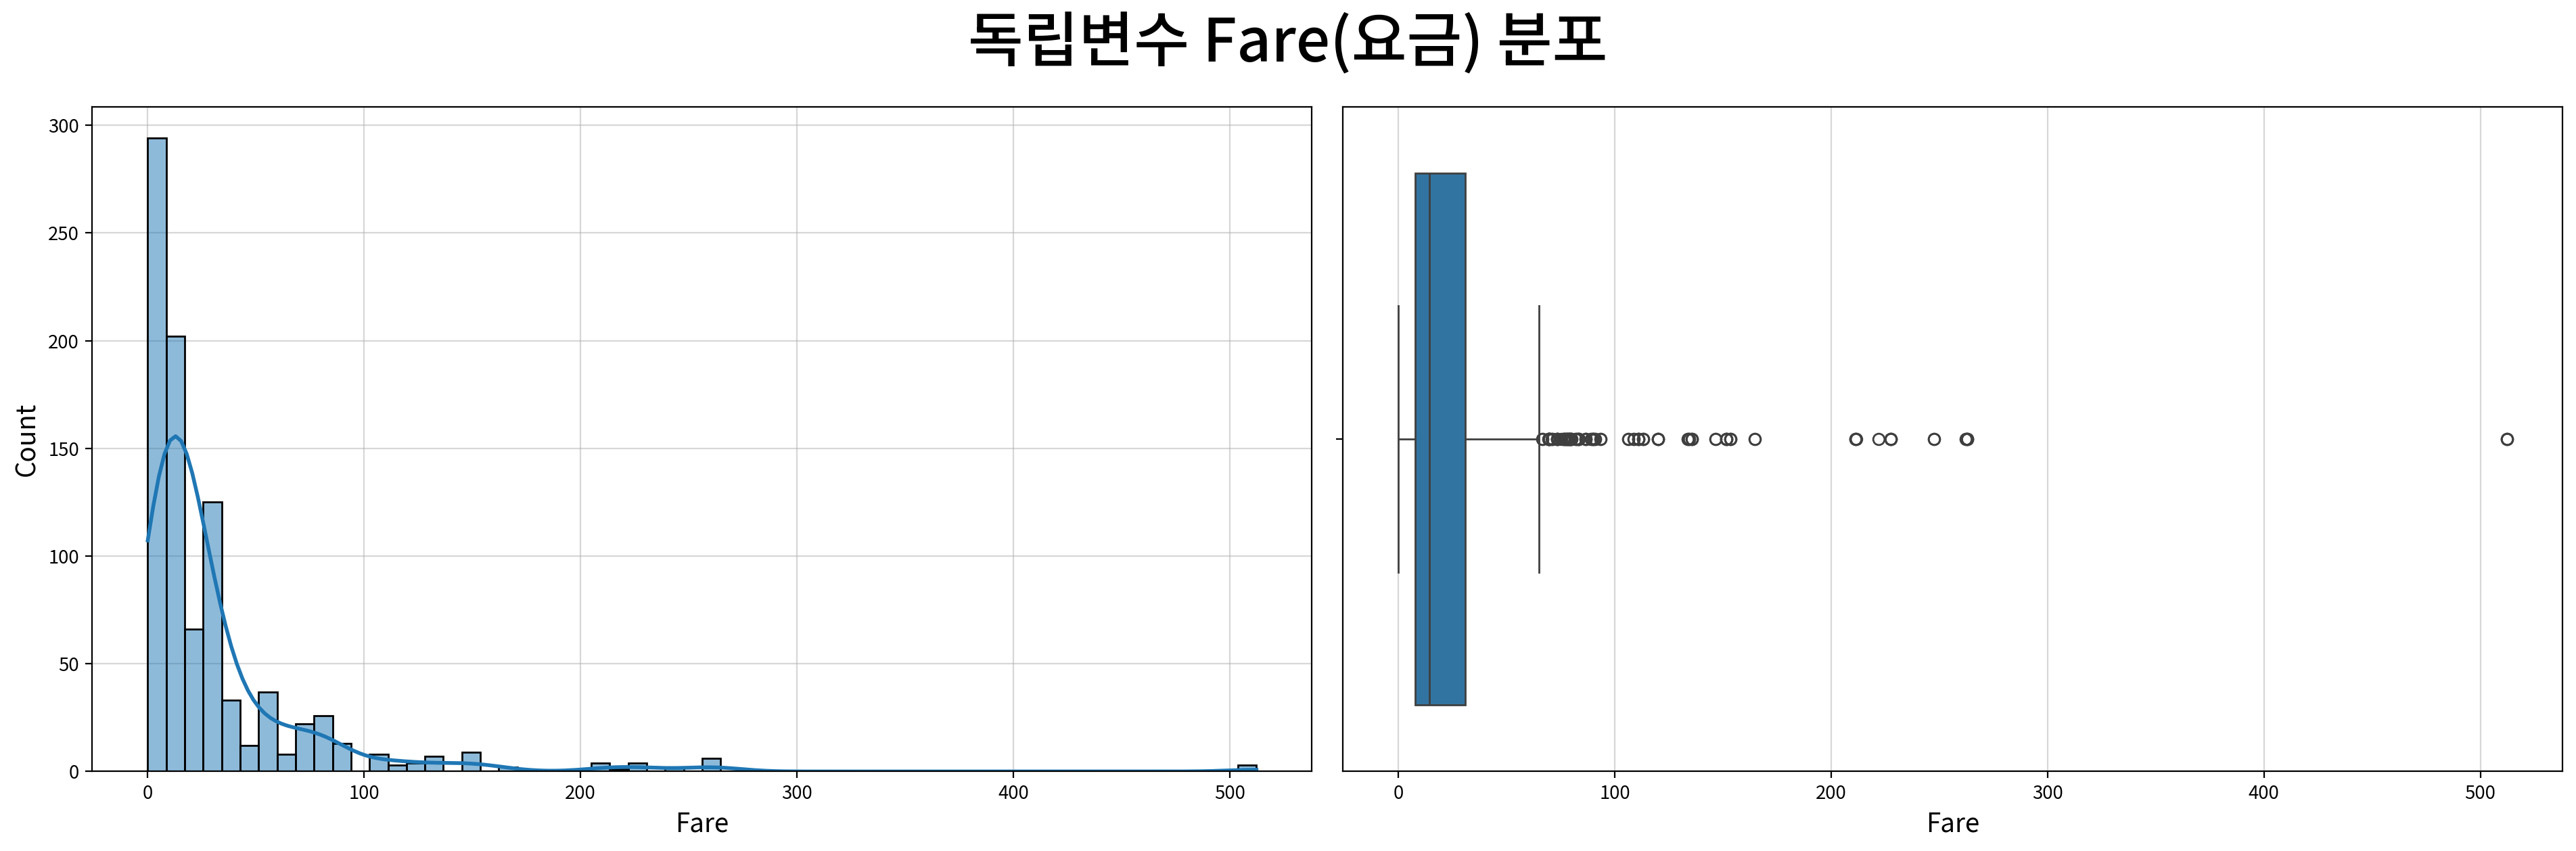

,Fare
count,891.000
mean,32.204
std,49.693
min,0.000
25%,7.910
50%,14.454
75%,31.000
max,512.329
rel_diff,1.228
rdiff_flag,large_diff


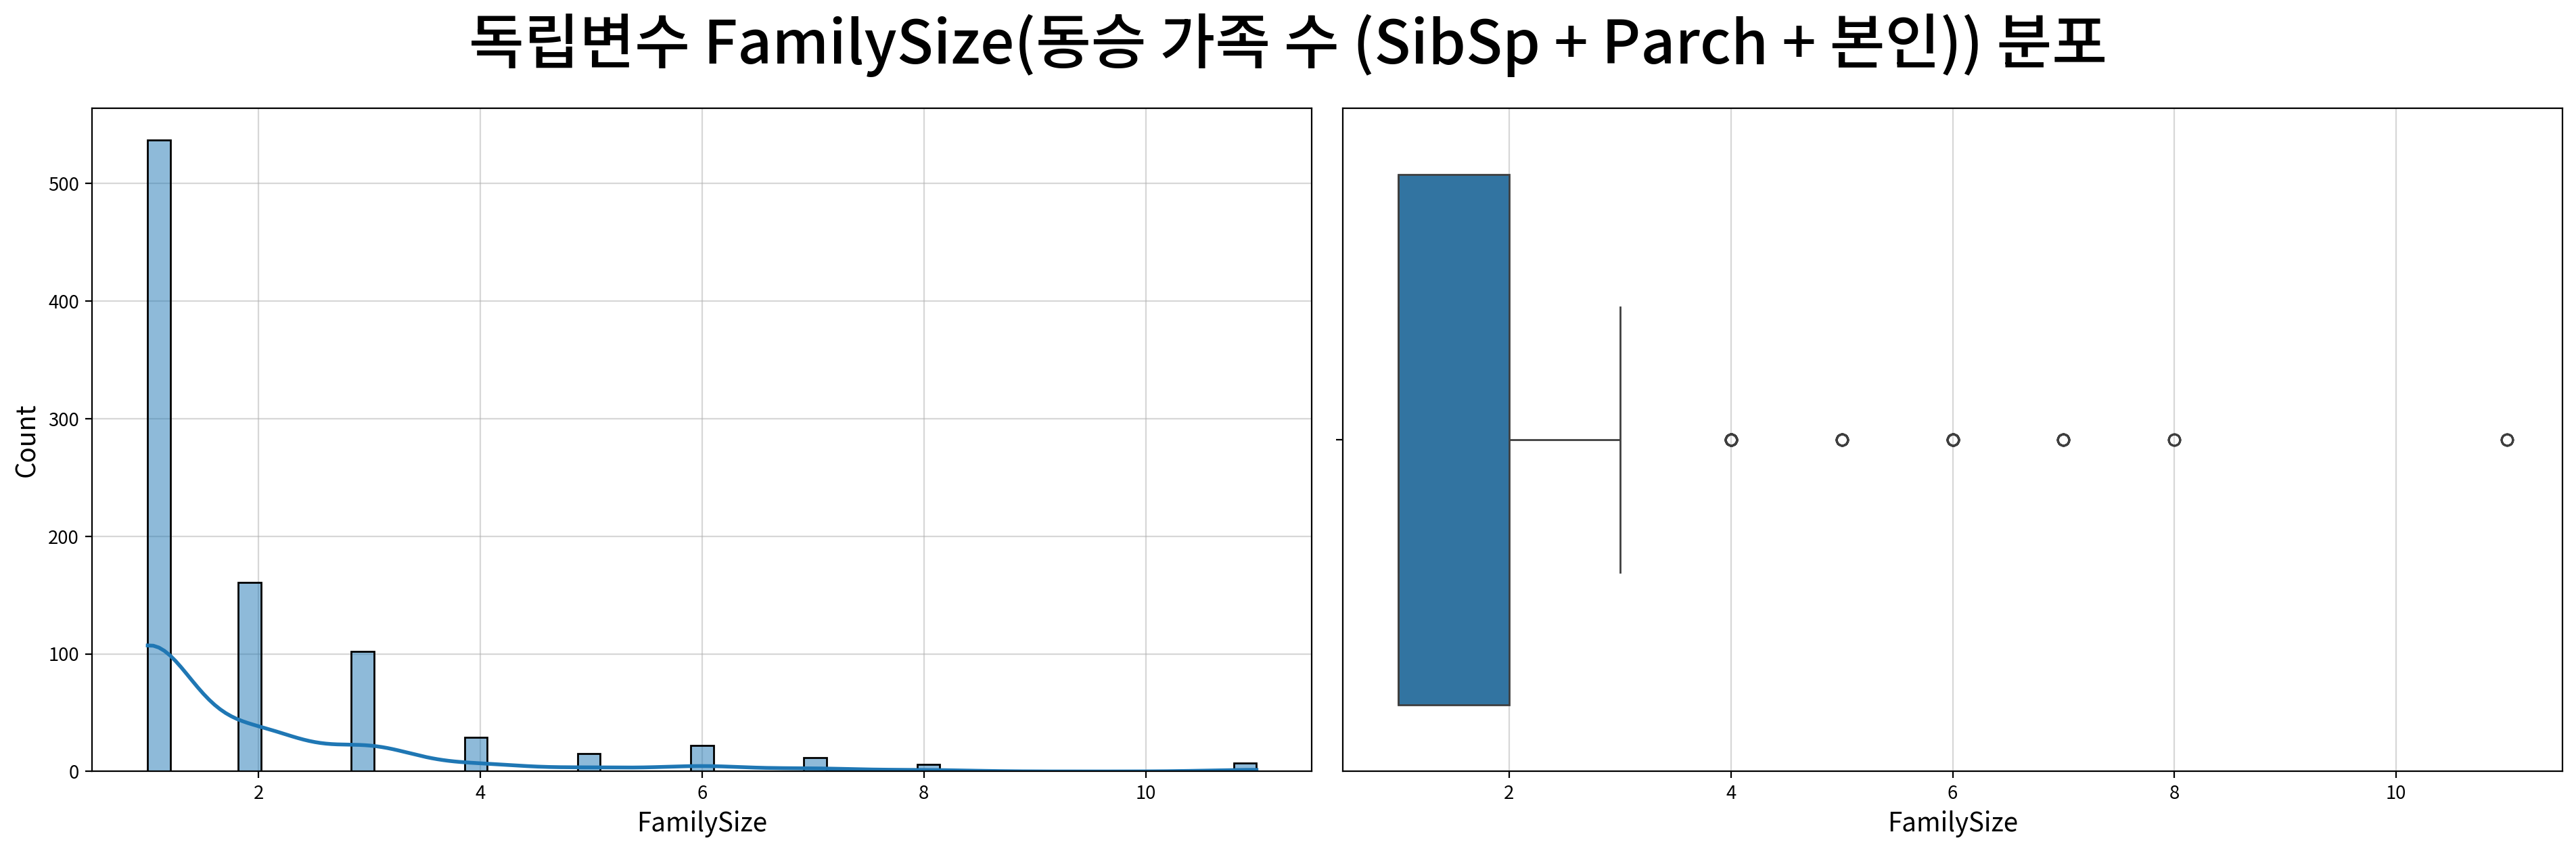

,FamilySize
count,891.000
mean,1.905
std,1.613
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,11.000
rel_diff,0.905
rdiff_flag,large_diff


In [21]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)


##### 수치형 분포 해석

Age는 결측 대체 후 평균 29.36세·중앙값 28세였다. 177건을 같은 값으로 채웠으므로 중앙값 주변의 집중은 실제 연령 구성만으로 만들어진 모양이 아니다.

Fare는 평균 32.20, 중앙값 14.45, 최댓값 512.33으로 평균과 중앙값의 차이가 크고 왜도는 4.787이었다. 고액 요금 관측치가 오른쪽 꼬리를 형성하지만, 큰 값 자체가 입력 오류를 뜻하지 않으므로 자동 삭제·대체하지 않았다. Fare는 로그변환 없이 원래 요금 단위로 사용했다.

Parch는 Q1=Q3=0이어서 IQR 규칙이 0보다 큰 213건을 모두 이상치로 표시했다. FamilySize의 IQR 상한도 3.5로, 가족 규모 4명 이상 91건이 이상치로 표시된다. 이들은 인원수 변수이므로 기계적으로 경계값 대체를 하면 실제 동승 정보를 지울 수 있다.

FamilySize는 본인 포함 인원수다. 1명인 단독 승객은 537명(60.3%)으로 가장 많고, 최대 가족 규모는 11명이다. 큰 가족의 생존율은 적은 표본을 바탕으로 계산되므로 인원수와 함께 읽었다. 독립변수의 왜도가 크다는 사실만으로 로지스틱 회귀의 가정 위반이나 변환 필요성을 단정하지 않았다.


### 이변량 분석

#### 1. T-Test (x: 연속형 독립변수 → y: 2집단 명목형 종속변수)

#### ▶︎ Age(나이) → Survived

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    97978.500    0.270        False   0 = 1
                    less         97978.500    0.865        False  0 >= 1
                    greater      97978.500    0.135        False  0 <= 1

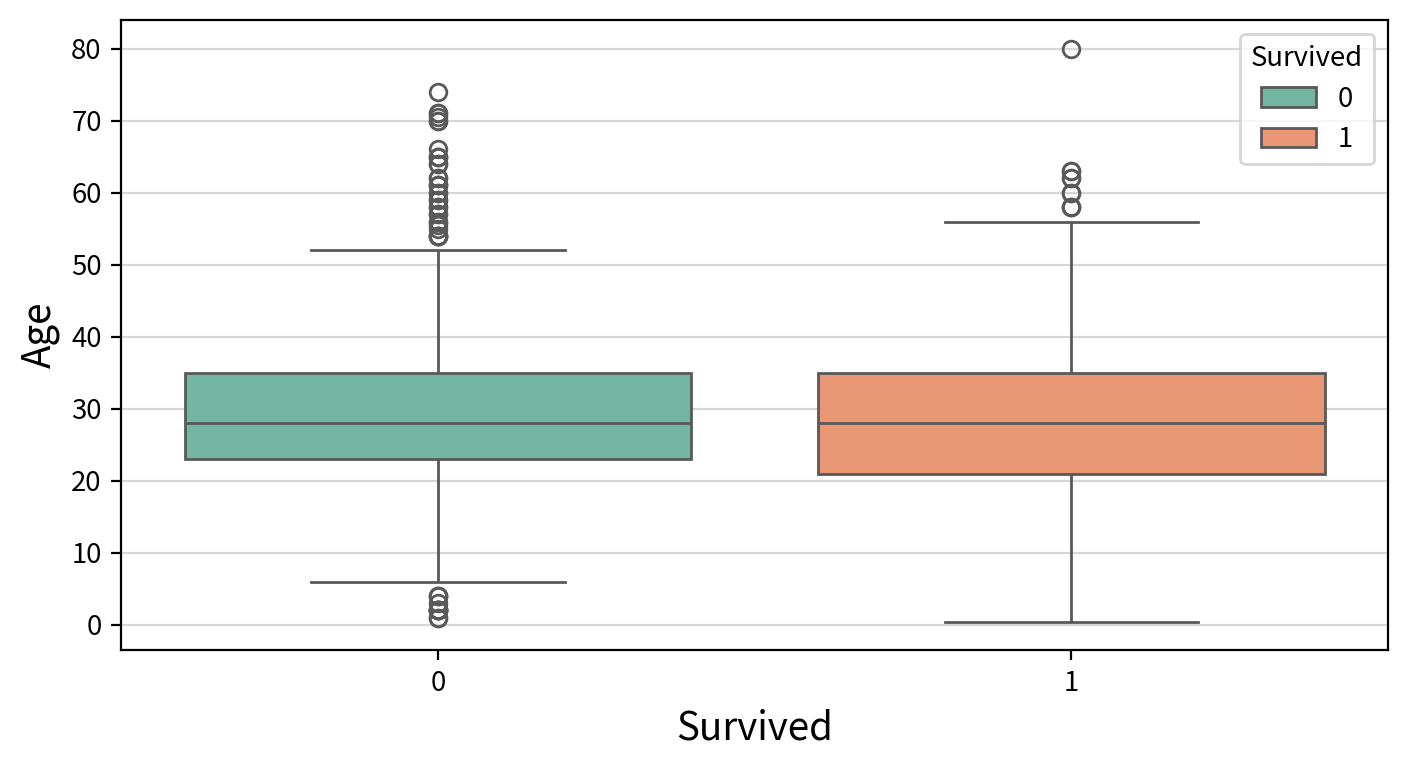

#### ▶︎ SibSp(동승한 형제·배우자 수) → Survived

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    85775.000    0.008         True  0 != 1
                    less         85775.000    0.004         True   0 < 1
                    greater      85775.000    0.996        False  0 <= 1

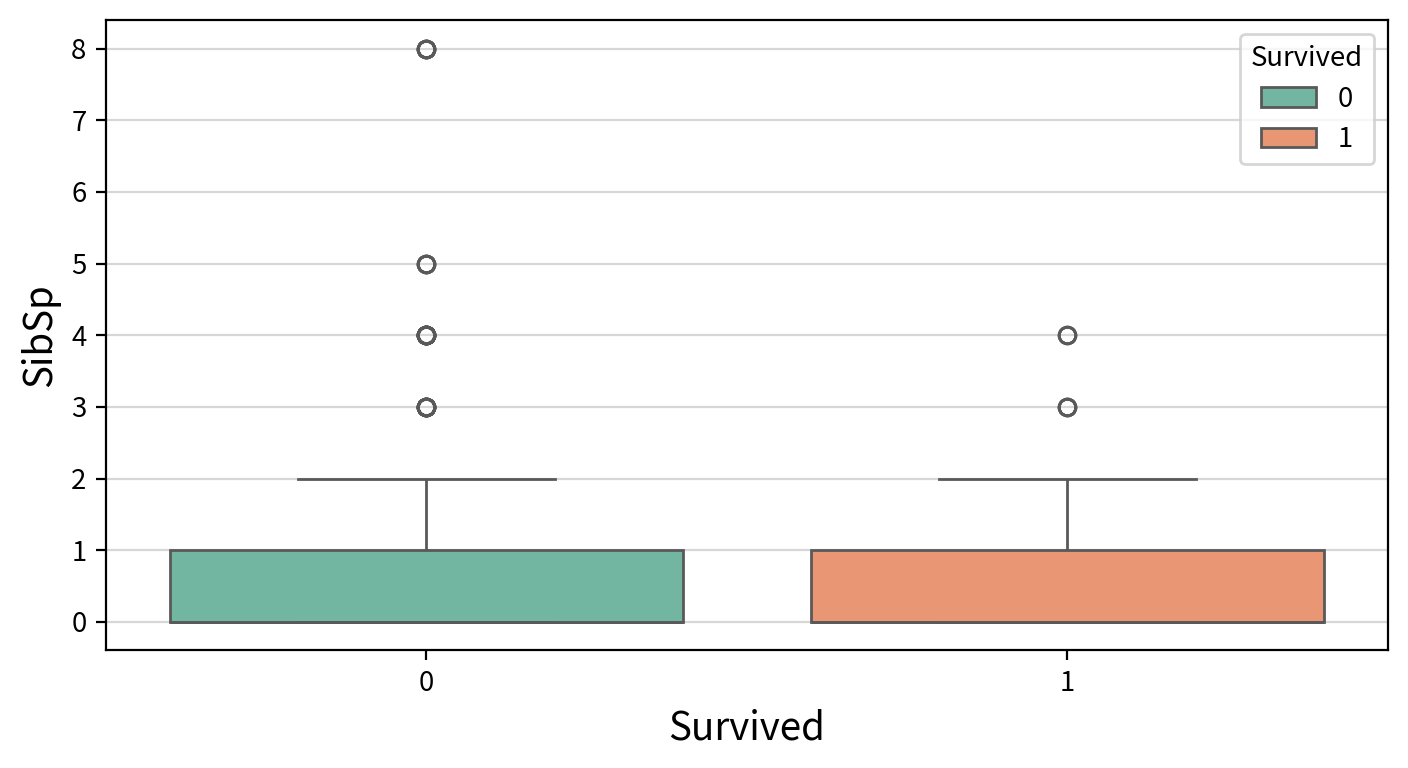

#### ▶︎ Parch(동승한 부모·자녀 수) → Survived

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    82385.000    0.000         True  0 != 1
                    less         82385.000    0.000         True   0 < 1
                    greater      82385.000    1.000        False  0 <= 1

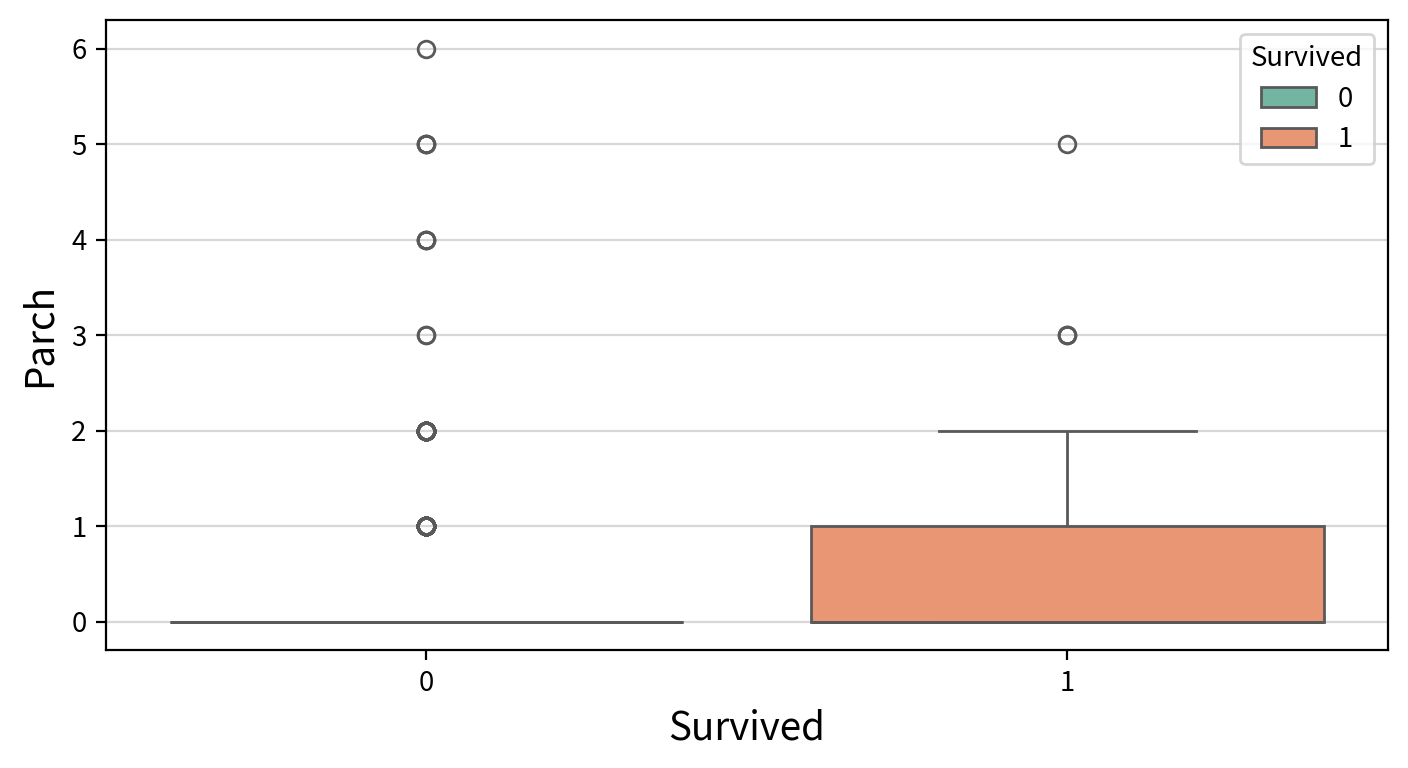

#### ▶︎ Fare(요금) → Survived

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    57806.500    0.000         True  0 != 1
                    less         57806.500    0.000         True   0 < 1
                    greater      57806.500    1.000        False  0 <= 1

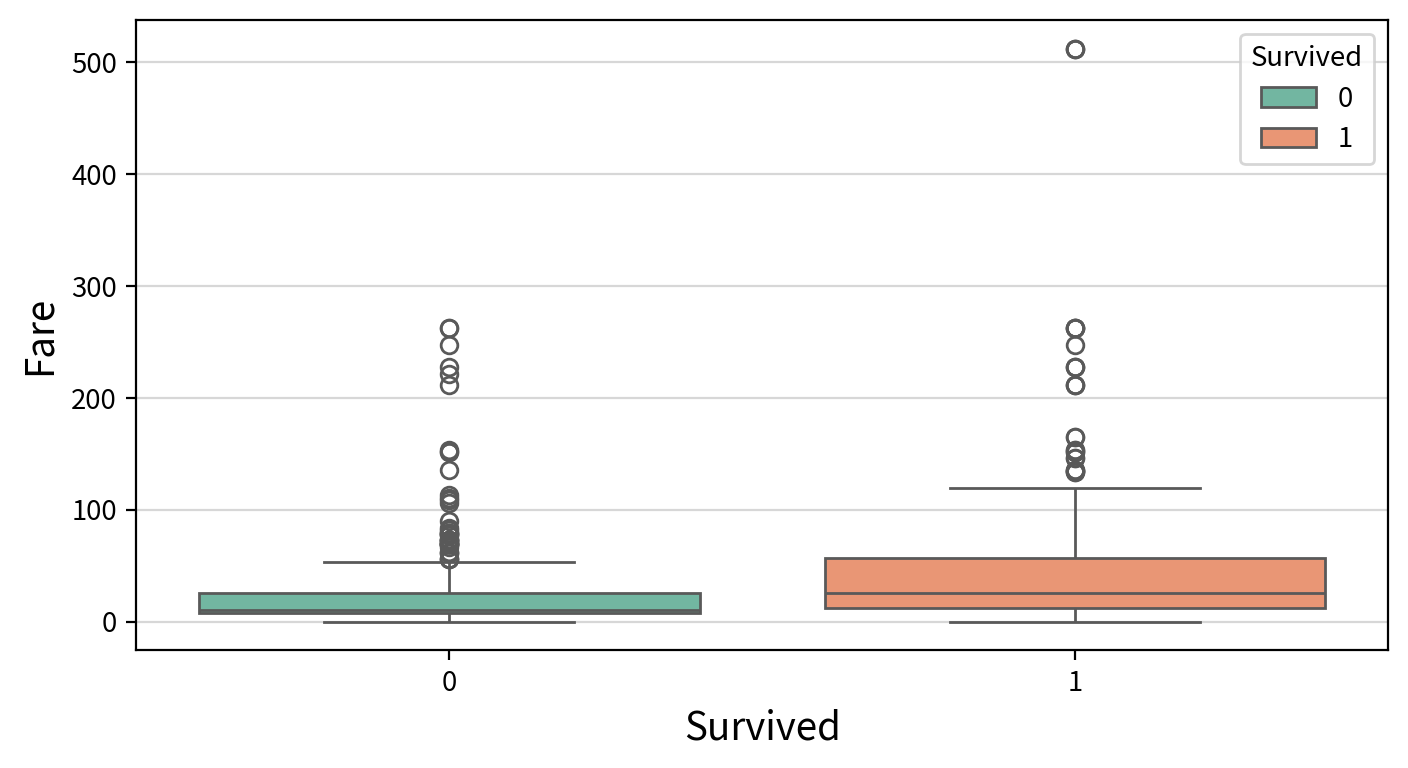

#### ▶︎ FamilySize(동승 가족 수 (SibSp + Parch + 본인)) → Survived

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    77659.000    0.000         True  0 != 1
                    less         77659.000    0.000         True   0 < 1
                    greater      77659.000    1.000        False  0 <= 1

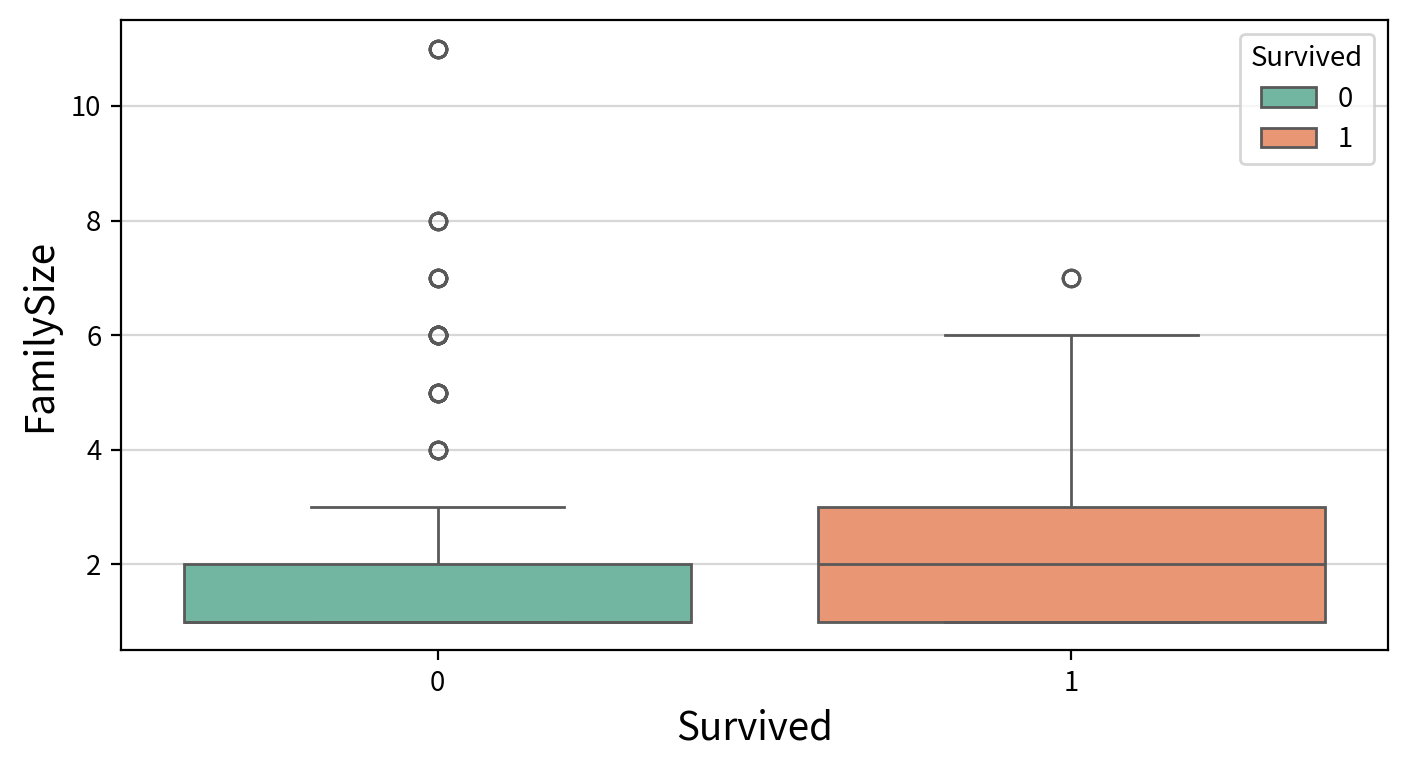

In [22]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df,
                group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette="Set2",
                    width=720, height=400)


#### 2. FamilySize 범주별 분포

t검정은 평균 차이, 여기서 사용되는 Mann–Whitney U는 순위 기반 분포 차이를 검토한다. 어느 쪽도 가족 규모별 생존율의 곡선 모양을 그대로 보여주지는 않는다. FamilySize는 본인을 포함한 인원수이므로 값별 생존율도 확인한다.

,사망률,생존률,인원수
FamilySize,,,
1,0.696,0.304,537
2,0.447,0.553,161
3,0.422,0.578,102
4,0.276,0.724,29
5,0.800,0.200,15
6,0.864,0.136,22
7,0.667,0.333,12
8,1.000,0.000,6
11,1.000,0.000,7


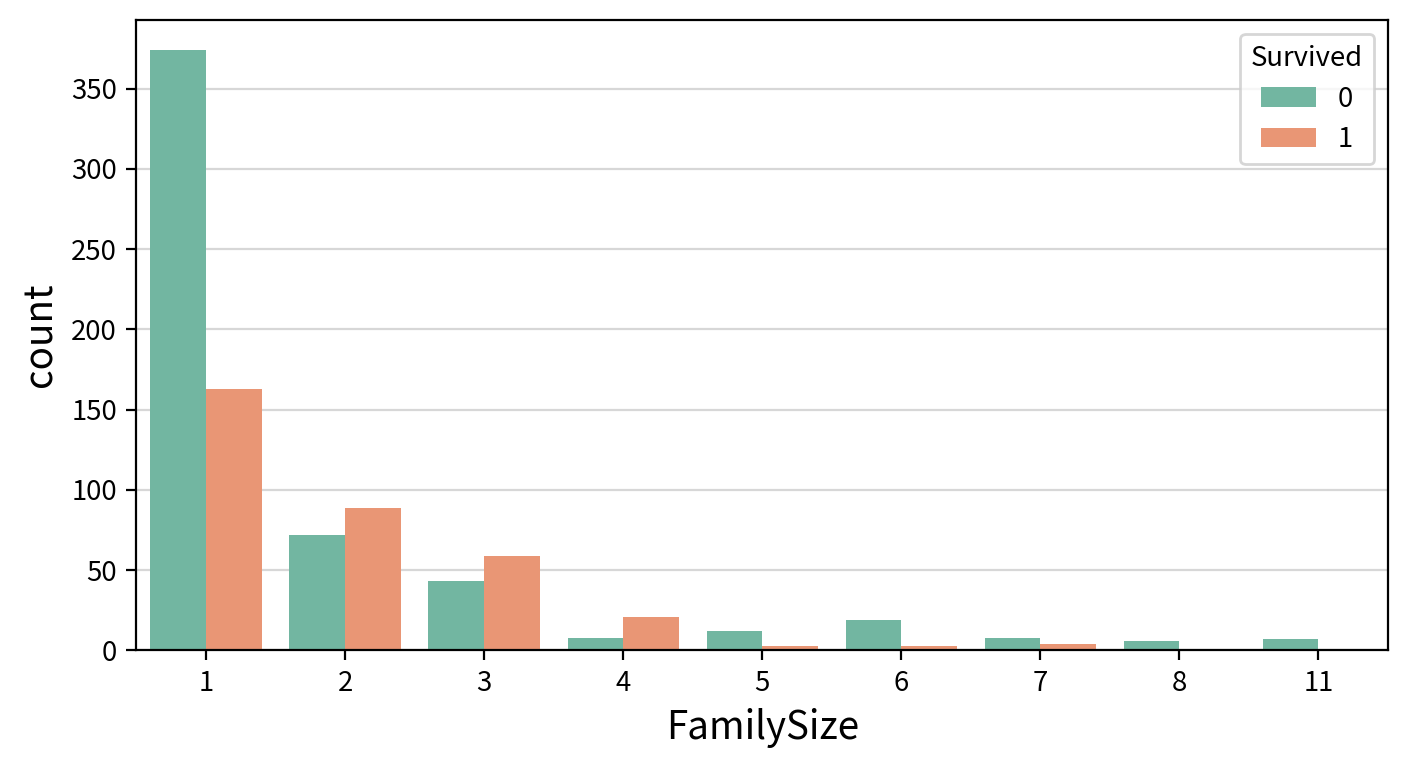

In [23]:
# 가족 규모별 생존율을 직접 계산한다
fs_rate = df.groupby("FamilySize", observed=True)[target].value_counts(normalize=True).unstack()
fs_rate.columns = ["사망률", "생존률"]
fs_rate["인원수"] = df["FamilySize"].value_counts().sort_index()
display(fs_rate)

# 시각화: 가족 규모별 생존 빈도
my_plot.countplot(data=df, x="FamilySize", hue=target, palette="Set2", 
                  width=720, height=400)


##### 수치형 특성과 생존의 관계 해석

아래는 실행 결과에서 선택된 Mann–Whitney U 양측검정의 요약이다. 이 검정은 순위 기반 분포 차이를 검토하므로 평균 차이 자체를 검증했다고 표현하지 않았다. 출력의 0.000은 반올림이며 p값이 정확히 0이라는 뜻이 아니다.

| 특성 | p값 | 관찰 결과 |
|---|---|---|
| Age | 0.270 | 두 집단의 분포 차이에 대한 유의한 증거를 발견하지 못함 |
| SibSp | 0.008 | 분포 차이가 관찰됨 |
| Parch | <0.001 | 분포 차이가 관찰됨 |
| Fare | <0.001 | 분포 차이가 관찰됨 |
| FamilySize | <0.001 | 분포 차이가 관찰됨 |

가족 규모별 생존율은 단독 승객 30.4%(537명), 2명 55.3%(161명), 3명 57.8%(102명), 4명 72.4%(29명)였다. 반면 5명은 20.0%(15명), 6명은 13.6%(22명)로 낮았다. 따라서 가족 수가 많을수록 생존율이 계속 높아지는 단순 직선 관계는 아니었다. 8명·11명 집단의 생존율은 0%지만 표본이 각각 6명·7명으로 작아 보편적 규칙으로 볼 수 없다.

Age의 비유의성은 연령이 무관하다는 증거가 아니다. 결측 대체가 포함된 단독 분포 비교이며, 이후 다른 변수와 함께 학습한 모델에서의 기여와는 질문이 다르다. 여러 변수를 탐색적으로 검정했으므로 개별 p값을 확증적 인과 결론으로 사용하지 않았다.


#### 3. 교차분석 (x: 명목형 독립변수 → y: 명목형 종속변수)

- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.
  - 명목형 독립변수가 없을 경우 출력 결과가 없을 수 있다.

#### ▶︎ Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Pclass,Survived,Chi-square test of independence,102.889,2,0.000,True,0.340,Moderate,70.630,True


Survived,0,1
Pclass,,
3,0.758,0.242
2,0.527,0.473
1,0.370,0.630


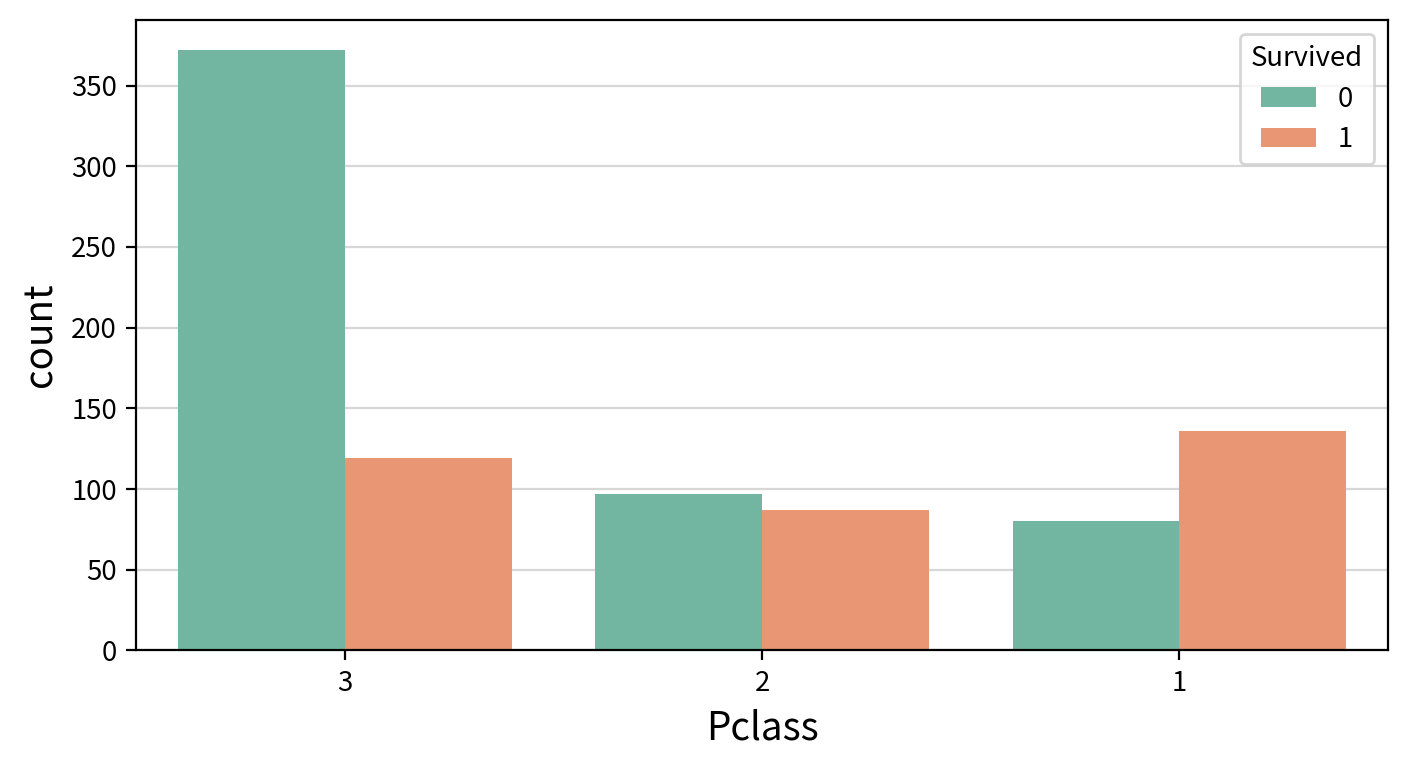

#### ▶︎ Sex(성별) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Sex,Survived,Chi-square test of independence,260.717,1,0.000,True,0.541,Strong,120.530,True


Survived,0,1
Sex,,
female,0.258,0.742
male,0.811,0.189


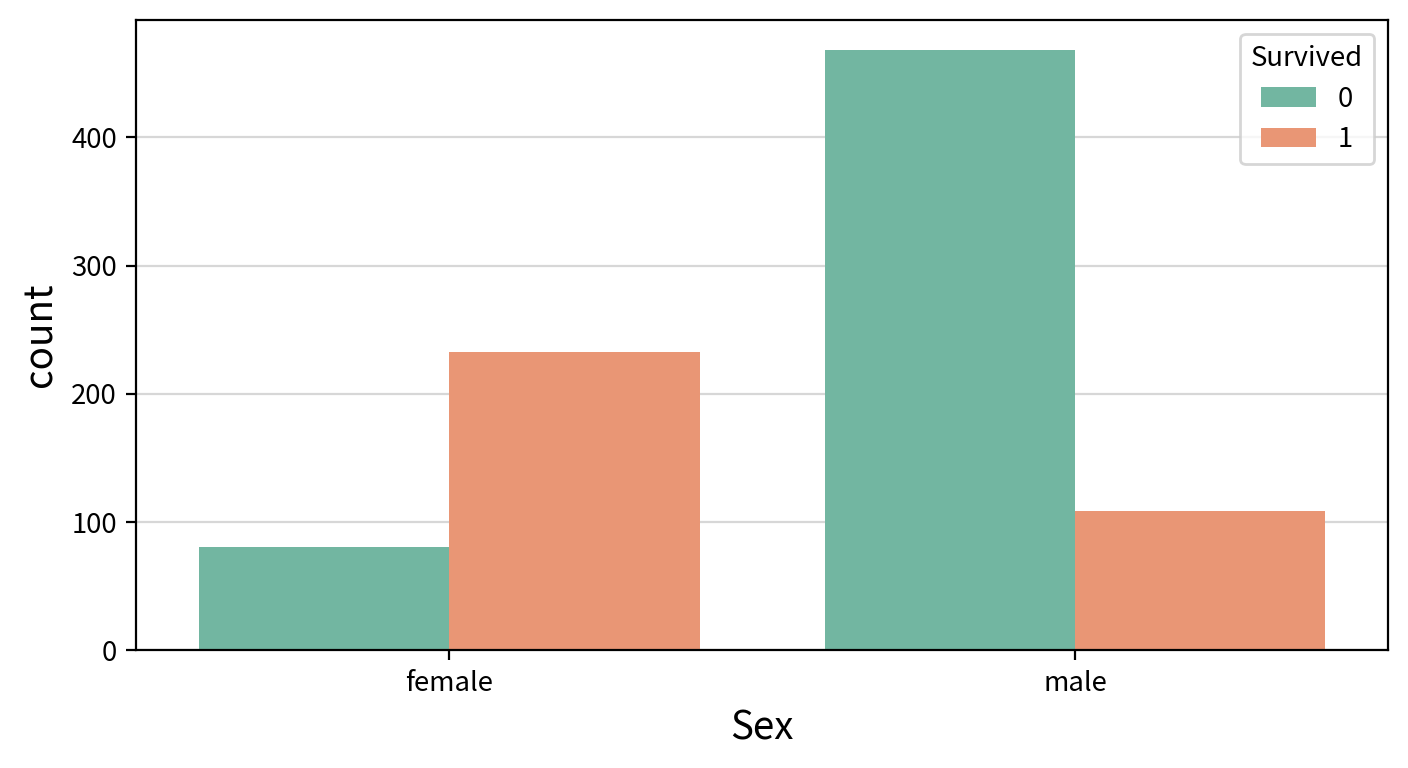

#### ▶︎ Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Embarked,Survived,Chi-square test of independence,26.489,2,0.000,True,0.173,Weak,29.450,True


Survived,0,1
Embarked,,
C,0.446,0.554
Q,0.610,0.390
S,0.663,0.337


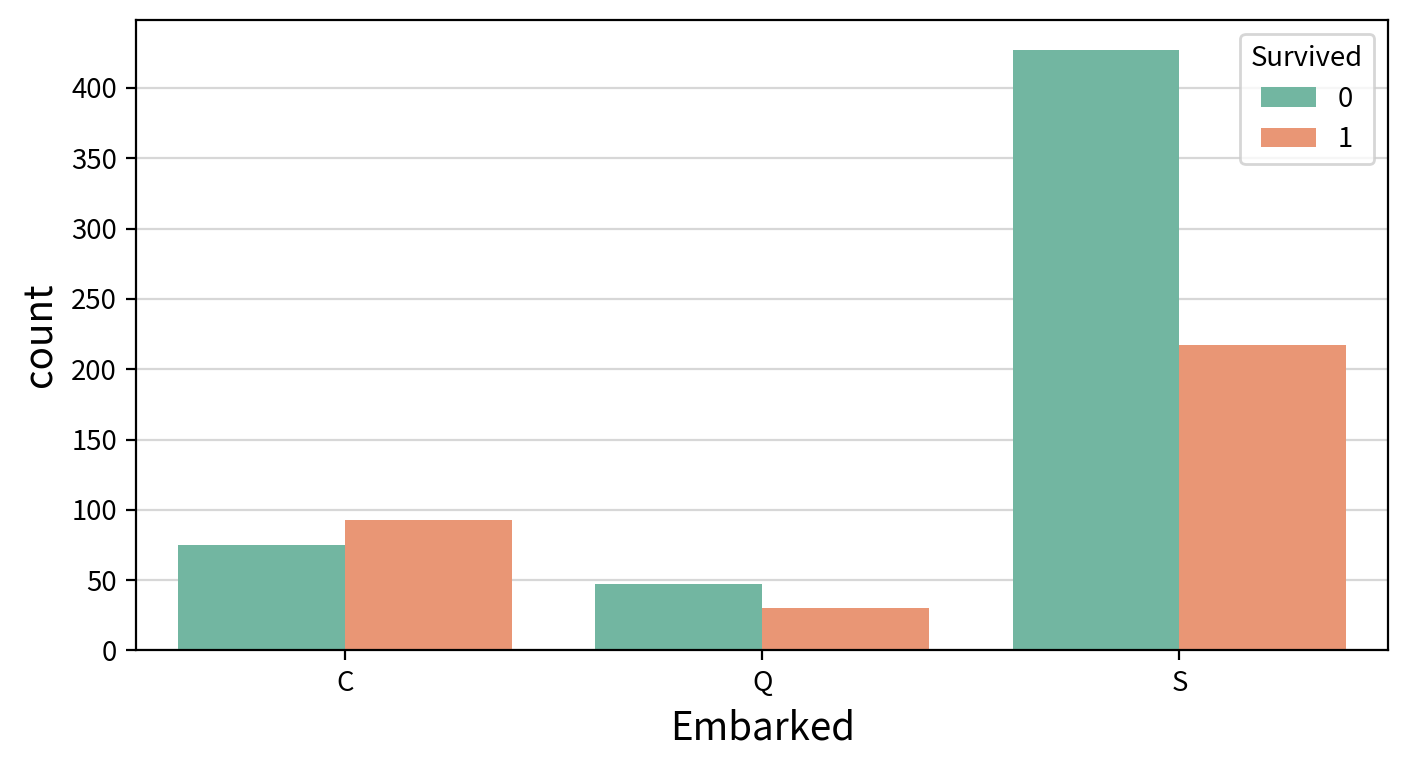

#### ▶︎ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Title,Survived,Chi-square test of independence,291.343,4,0.000,True,0.572,Strong,6.910,True


Survived,0,1
Title,,
Mr,0.842,0.158
Officer,0.722,0.278
Master,0.425,0.575
Miss,0.297,0.703
Mrs,0.203,0.797


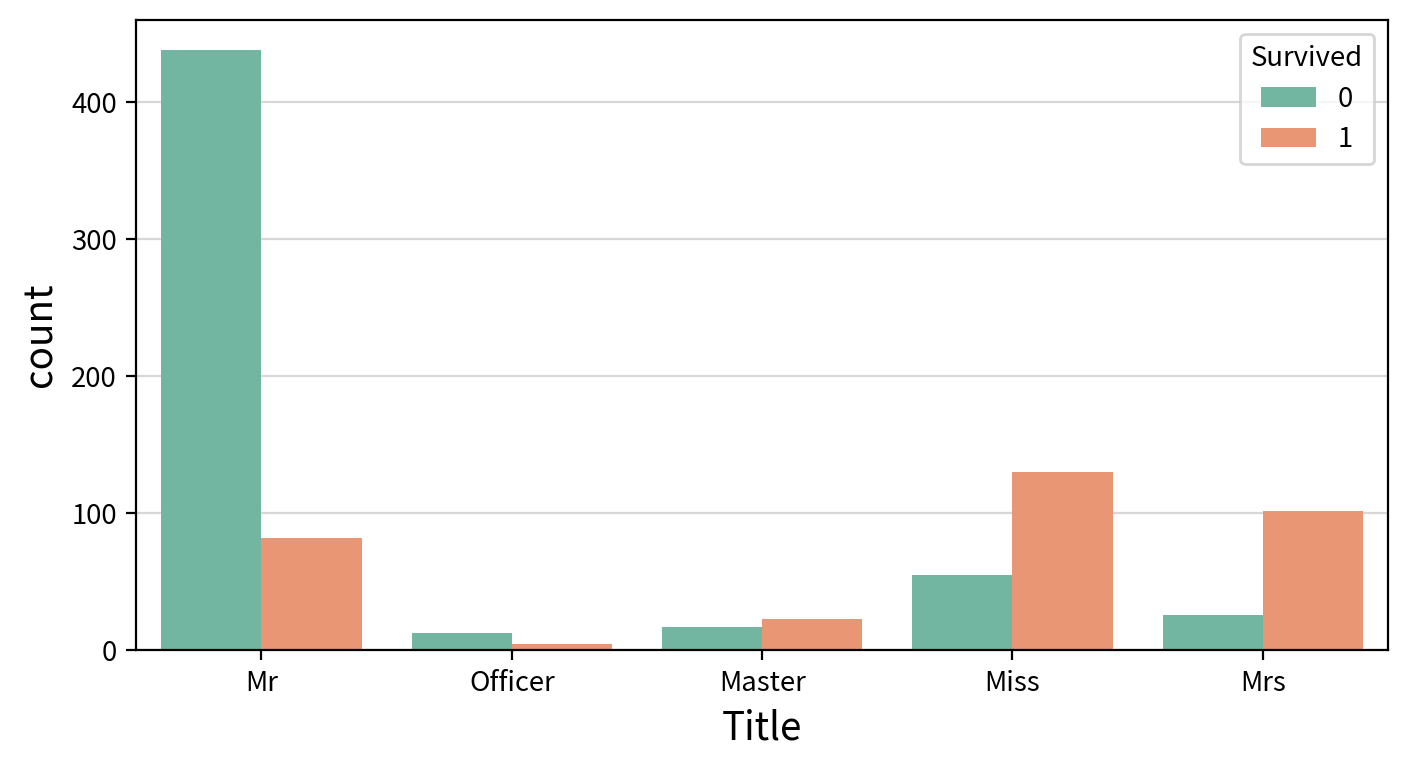

In [24]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

    # 범주별 생존율 표
    rate = df.groupby(n, observed=True)[target].value_counts(normalize=True).unstack()
    display(rate)

    # 시각화: 범주별 생존 비율
    my_plot.countplot(data=df, x=n, hue=target, palette="Set2", width=720, height=400)


##### 범주형 특성과 생존의 관계 해석

| 특성 | Cramer's V | 주요 집단의 생존율 |
|---|---:|---|
| Title | 0.572 | Mrs 79.7%, Miss 70.3%, Master 57.5%, Officer 27.8%, Mr 15.8% |
| Sex | 0.541 | 여성 74.2%, 남성 18.9% |
| Pclass | 0.340 | 1등급 63.0%, 2등급 47.3%, 3등급 24.2% |
| Embarked | 0.173 | C 55.4%, Q 39.0%, S 33.7% — 유효 889건 |

네 변수의 카이제곱 독립성 검정은 모두 p<0.001이었다. Title·Sex의 연관성이 상대적으로 강했고, 객실 등급은 1등급에서 3등급으로 갈수록 표본 생존율이 낮았다. Embarked도 유의하지만 효과크기는 상대적으로 작다. 표에 표시된 최소 기대빈도는 모두 5 이상이었으나, 이는 희소 집단의 생존율 추정이 충분히 안정적이라는 보장은 아니다.

Title의 V가 Sex보다 높다고 해서 호칭을 추가하면 예측 성능이 그만큼 개선된다고 결론 내릴 수 없다. 두 변수는 정보를 공유하며, 별도의 성별 단독 모델과의 성능 차이를 검증하지 않았다. 승선항·등급·호칭별 차이에는 승객 구성과 다른 특성이 함께 관련될 수 있다. 구체적인 대피 순서나 개인의 행동을 이 결과로 입증하지 않았다.


### 다변량 분석

#### 1. 독립변수 간 상관과 공선성

FamilySize는 SibSp+Parch+1로 계산되므로 세 변수를 동시에 사용하면 정확한 선형관계가 생긴다. 상관과 VIF를 통해 파생변수와 원재료 변수의 정보 중복을 확인했다.


In [25]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
display(my_stats.correlation_summary(corr))

# 분산팽창지수(VIF)로 한 번 더 확인
display(my_stats.compute_vif(df[continuous_cols]))


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_stats.py:955: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_stats.py:955: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_stats.py:955: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_stats.py:955: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


,Age,SibSp,Parch,Fare,FamilySize
Age,1.000,-0.145,-0.217,0.126,-0.183
SibSp,-0.145,1.000,0.450,0.447,0.849
Parch,-0.217,0.450,1.000,0.410,0.801
Fare,0.126,0.447,0.410,1.000,0.529
FamilySize,-0.183,0.849,0.801,0.529,1.000


,max-y,max-coef,count,columns
x,,,,
FamilySize,SibSp,0.849,2,"SibSp, Parch"
SibSp,FamilySize,0.849,1,FamilySize
Parch,FamilySize,0.801,1,FamilySize
Fare,FamilySize,0.529,0,-
Age,Parch,-0.217,0,-


c:\Users\jh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\jh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
FamilySize,inf
Parch,inf
SibSp,inf
Age,1.092
Fare,1.082


### EDA와 모델 입력 변수의 연결

FamilySize·SibSp·Parch의 VIF는 무한대로 나타났고 Age는 1.092, Fare는 1.082였다. 가족 관련 세 변수의 무한대 VIF는 계산식에서 비롯된 공선성으로, 자료가 잘못됐다는 뜻은 아니다. 모델에서는 SibSp·Parch 대신 FamilySize를 사용했다.

| 모델 입력 | 구성 및 판단 |
|---|---|
| Title | 이름에서 추출한 5개 호칭 범주; 성별·연령 정보를 일부 포함 |
| Pclass | 연속량이 아닌 객실 등급 범주 |
| Embarked | 승선항 범주; 모델 파이프라인에서 결측 대체 |
| HasCabin | Cabin 기록 유무; 실제 객실 소유 여부로 해석하지 않음 |
| Age·Fare | 원래 수치 단위 사용; Age 결측은 모델 파이프라인에서 처리 |
| FamilySize | 본인을 포함한 동승 가족 규모 |

식별자·이름·티켓·객실 번호 원문은 모델 입력에서 제외했다. Sex는 Title과 정보가 상당히 겹쳐 별도 투입하지 않았지만, 이 구성이 모든 대안보다 우수하다고 검증한 것은 아니다. Age는 단변량 검정이 유의하지 않아도 다변량 예측에서의 활용 가능성을 남겼다. EDA의 p값만으로 변수를 자동 탈락시키지는 않았다.


<a id="stage-3"></a>

## 3. 분류모형 베이스라인 비교

### 모델링 데이터와 평가 설계

동일한 원자료 891건에서 7개 입력을 구성하고, 712건은 훈련·179건은 내부 검증에 사용했다. `random_state=3217`, `test_size=0.2`, `stratify=target`으로 분할하여 클래스 비율을 유지했다. 계층화 분할은 불균형을 없애는 처리가 아니다.

EDA에서 값을 채운 작업본 대신 대체 전 원자료를 사용했다. 수치형 중앙값·범주형 최빈값 대체, VIF 처리, 모델별 스케일링과 인코딩을 파이프라인에 묶었다. CatBoost는 범주형을 자체 처리하며 나머지 모델은 설정에 따라 원핫 인코딩을 사용했다. 범주 코드의 크기에 순서 의미를 부여하지 않았다.

11개 모형을 같은 내부 검증셋에서 비교했다. F1을 주 지표로 사용하고 ROC-AUC·Accuracy를 보조 지표로 확인했다. 비교 함수의 5% 근소 격차 그룹은 순위 규칙이며 통계적으로 동등한 성능 집단을 뜻하지 않는다. LogLoss도 별도로 검토하여 확률 예측의 품질을 구분했다.


### 분석 설정

#### 1. 라이브러리 참조

In [26]:
from jussam import load_data
from helpers import *
import datetime as dt
import os
import glob as gl   # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈

# 훈련,검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV


In [27]:
# 선형 계열 모델
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 트리계열 모델
from sklearn.tree import DecisionTreeClassifier

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


#### 2. 모델링 데이터 준비

891건의 동일한 7개 특성을 사용했다. 이 시점의 Age·Embarked 결측은 파이프라인이 훈련 데이터에서 학습한 중앙값·최빈값으로 처리한다.


In [28]:
# 앞서 확인한 891건에서 기존 모델링의 7개 변수를 재구성한다.
# EDA에서 결측치를 채운 df가 아니라, 대체 전 raw_train을 사용한다.
model_data = raw_train[["Pclass", "Embarked", "Age", "Fare", "Survived"]].copy()
model_data["Title"] = raw_train["Name"].str.extract(
    r",\s*([^\.]+)\.", expand=False).str.strip().map(title_map)
assert model_data["Title"].notna().all(), "호칭 매핑 누락을 확인하세요."
model_data["HasCabin"] = raw_train["Cabin"].notna().astype(int)
model_data["FamilySize"] = raw_train["SibSp"] + raw_train["Parch"] + 1

# 기존 가공 데이터의 범주 코드 체계 유지 (숫자의 크기에 순서 의미 없음)
title_codes = {"Master": "0", "Miss": "1", "Mr": "2", "Mrs": "3", "Officer": "4"}
embarked_codes = {"C": "0", "Q": "1", "S": "2"}
model_data["Title"] = model_data["Title"].map(title_codes)
model_data["Embarked"] = model_data["Embarked"].map(embarked_codes)
for col in ["Pclass", "HasCabin"]:
    model_data[col] = model_data[col].astype(str)
# CatBoost에도 결측 대체 후 문자열 범주를 전달하기 위해 코드는 문자열로 보관한다.
# Age와 Embarked의 결측은 그대로 두고 fit_pipeline(impute=True)에서 처리한다.
model_data = model_data[["Title", "Pclass", "Embarked", "HasCabin",
                         "Age", "Fare", "FamilySize", "Survived"]]
model_data = my_qtcheck.set_type(model_data,
    as_category=["Title", "Pclass", "Embarked", "HasCabin", "Survived"])
assert len(model_data) == 891
assert model_data["Survived"].astype(int).equals(raw_train["Survived"].astype(int))
origin = model_data.copy()
df = origin.copy()
display(df.head())
display(df.isna().sum().rename("모델링 전 결측 수").to_frame())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Title       891 non-null    category
 1   Pclass      891 non-null    category
 2   Embarked    889 non-null    category
 3   HasCabin    891 non-null    category
 4   Age         714 non-null    float64 
 5   Fare        891 non-null    float64 
 6   FamilySize  891 non-null    int64   
 7   Survived    891 non-null    category
dtypes: category(5), float64(2), int64(1)
memory usage: 26.1 KB


,Title,Pclass,Embarked,HasCabin,Age,Fare,FamilySize,Survived
0,2,3,2,0,22.000,7.250,2,0
1,3,1,0,1,38.000,71.283,2,1
2,1,3,2,0,26.000,7.925,1,1
3,3,1,2,1,35.000,53.100,2,1
4,2,3,2,0,35.000,8.050,1,0


,모델링 전 결측 수
Title,0
Pclass,0
Embarked,2
HasCabin,0
Age,177
Fare,0
FamilySize,0
Survived,0


#### 3. 독립변수와 종속변수 분리 및 훈련, 검증 데이터 분할

In [29]:
feature = df.drop(columns=["Survived"])
target = df["Survived"]

# 훈련, 검증 데이터 분리
# 분류 문제이므로 stratify=target 을 지정해 훈련/검증의 클래스 비율을 원본과 같게 유지한다
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((712, 7), (179, 7), (712,), (179,))

#### 4. 학습을 완료한 모델이 저장될 폴더

In [30]:
baseline_dir = f"titanic_train891/baseline"  # 베이스라인 모델이 저장될 경로

if not os.path.exists(baseline_dir):
    os.makedirs(baseline_dir)


### 선형계열 모델

#### 1. LogisticRegression

In [31]:
# 학습 모델 객체 생성
model = LogisticRegression(random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "regression" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("regression")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 기본값이 L2 규제이므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: logistic
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: logistic
모델 저장: titanic_train891/baseline/logistic.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LogisticRegression,0.793,0.767,0.667,0.713,0.836,0.827,0.468,0.556


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. RidgeClassifier

In [32]:
# 학습 모델 객체 생성
model = RidgeClassifier(random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 계수에 벌점을 매기므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: ridge
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: ridge
모델 저장: titanic_train891/baseline/ridge.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RidgeClassifier,0.821,0.794,0.725,0.758,0.834,0.824,NaN,0.618


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 3. Lasso

In [33]:
# 학습 모델 객체 생성
# 분류에는 Lasso 클래스가 없다. L1 규제를 건 로지스틱 회귀가 그 자리를 대신한다.
model = LogisticRegression(l1_ratio=1, solver="liblinear", random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (1번 모델과 클래스가 같아 이름이 겹치므로 직접 지정)
model_name = "lasso"

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 계수에 벌점을 매기므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                name=model_name,                          # 모델을 구분할 이름
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: lasso
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: lasso
모델 저장: titanic_train891/baseline/lasso.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LogisticRegression,0.816,0.781,0.725,0.752,0.837,0.831,0.464,0.607


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 4. ElasticNet

In [34]:
# 학습 모델 객체 생성
# loss="log_loss" 는 로지스틱 회귀와 같은 확률 모형, penalty="elasticnet" 은 L1+L2 규제
model = SGDClassifier(loss="log_loss", penalty="elasticnet",
                      random_state=RANDOM_STATE, n_jobs=-1)

# 모델이름 문자열 구성 (클래스명(sgd)이 아니라 규제 방식으로 부르기 위해 직접 지정)
model_name = "elasticnet"

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 계수에 벌점을 매기므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                name=model_name,                          # 모델을 구분할 이름
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: elasticnet
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: elasticnet
모델 저장: titanic_train891/baseline/elasticnet.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
SGDClassifier,0.799,0.851,0.580,0.690,0.816,0.793,0.572,0.571


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 비선형 계열 모델

#### 1. KNN

In [35]:
# 학습 모델 객체 생성
model = KNeighborsClassifier(n_jobs=-1)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 거리로 학습하므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: kneighbors
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: kneighbors
모델 저장: titanic_train891/baseline/kneighbors.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
KNeighborsClassifier,0.832,0.810,0.739,0.773,0.863,0.788,1.710,0.642


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. Support Vector Classifier

In [36]:
# 학습 모델 객체 생성
# probability=True 로 두어야 확률 기반 지표(LogLoss)까지 계산된다.
# 확률을 얻으려고 내부에서 교차검증을 한 번 더 돌리므로 그만큼 느려진다.
model = SVC(probability=True, random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                scale=True,                               # 마진으로 학습하므로 스케일링 필요
                drop_first=True,                          # 더미변수 생성(첫번째 컬럼 제거)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: svc
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=True)

모델 학습 완료: svc
모델 저장: titanic_train891/baseline/svc.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
SVC,0.804,0.774,0.696,0.733,0.849,0.835,0.460,0.581


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 트리 계열 모델

#### 1. Decision Tree

In [37]:
# 학습 모델 객체 생성
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                encode=True,                              # 더미변수 생성(모든 범주 유지)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: decisiontree
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=False)

모델 학습 완료: decisiontree
모델 저장: titanic_train891/baseline/decisiontree.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
DecisionTreeClassifier,0.771,0.694,0.725,0.709,0.763,0.608,8.065,0.521


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 앙상블 모델

#### 1. Random Forest

In [38]:
# 학습 모델 객체 생성
model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                encode=True,                              # 더미변수 생성(모든 범주 유지)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: randomforest
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=False)

모델 학습 완료: randomforest
모델 저장: titanic_train891/baseline/randomforest.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RandomForestClassifier,0.782,0.714,0.725,0.719,0.867,0.832,0.799,0.541


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. XGBoost

In [39]:
# 학습 모델 객체 생성
model = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                encode=True,                              # 더미변수 생성(모든 범주 유지)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: xgb
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=False)

모델 학습 완료: xgb
모델 저장: titanic_train891/baseline/xgb.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
XGBClassifier,0.777,0.723,0.681,0.701,0.844,0.820,0.537,0.524


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 3.  LightGBM

In [40]:
# 학습 모델 객체 생성
model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                encode=True,                              # 더미변수 생성(모든 범주 유지)
                save_path=f"{baseline_dir}/{model_name}.pkl")  # 모델 저장 경로

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: lgbm
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=False)

모델 학습 완료: lgbm
모델 저장: titanic_train891/baseline/lgbm.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LGBMClassifier,0.832,0.820,0.725,0.769,0.865,0.840,0.450,0.641


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 4. CatBoost

In [41]:
# 학습 모델 객체 생성
model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)

# 모델이름 문자열 구성 (클래스 이름을 소문자 변환 후 "classifier" 꼬리 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
                model=model,                              # 학습 모델
                x_train=x_train, y_train=y_train,         # 훈련 데이터 (독립,종속)
                vif=True,                                 # 다중공선성 확인 여부
                encode=False,                             # CatBoost는 자체적으로 범주형 처리
                save_path=f"{baseline_dir}/{model_name}.pkl",   # 모델 저장 경로
                # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
                model__cat_features=my_qtcheck.get_categorical_column_names(x_train))

display(my_ml.cls_score(model, x_test, y_test))           # 모델 성능평가
display(model)                                            # 모델 구조 출력


대상: 712행 x 7열 | 모델: catboost
명목형: ['Title', 'Pclass', 'Embarked', 'HasCabin']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent)

모델 학습 완료: catboost
모델 저장: titanic_train891/baseline/catboost.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
CatBoostClassifier,0.788,0.754,0.667,0.708,0.846,0.838,0.435,0.545


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 최고 성능 모델 선정

#### 1. 학습 모델 파일 목록

In [42]:
# 작업폴더 내의 모든 pkl 파일 목록 확인
model_pickles = gl.glob(f"{baseline_dir}/*.pkl")
print(model_pickles)


['titanic_train891/baseline\\catboost.pkl', 'titanic_train891/baseline\\decisiontree.pkl', 'titanic_train891/baseline\\elasticnet.pkl', 'titanic_train891/baseline\\kneighbors.pkl', 'titanic_train891/baseline\\lasso.pkl', 'titanic_train891/baseline\\lgbm.pkl', 'titanic_train891/baseline\\logistic.pkl', 'titanic_train891/baseline\\randomforest.pkl', 'titanic_train891/baseline\\ridge.pkl', 'titanic_train891/baseline\\svc.pkl', 'titanic_train891/baseline\\xgb.pkl']


#### 2. 학습 모델 불러오기

In [43]:
models = {}                         # 모델명과 모델 객체를 저장할 딕셔너리

for p in model_pickles:
    model_name = p.split(".")[0]    # 파일 목록에서 파일명만 분리
    model = my_ml.load_model(p)     # 모델 로드
    models[model.name_] = model     # 모델명과 모델 객체를 딕셔너리에 저장

# 로드된 모델과 모델 객체의 타입 출력
for name, model in models.items():
    print(f"- {name}: {type(model)}")


- catboost: <class 'sklearn.pipeline.Pipeline'>
- decisiontree: <class 'sklearn.pipeline.Pipeline'>
- elasticnet: <class 'sklearn.pipeline.Pipeline'>
- kneighbors: <class 'sklearn.pipeline.Pipeline'>
- lasso: <class 'sklearn.pipeline.Pipeline'>
- lgbm: <class 'sklearn.pipeline.Pipeline'>
- logistic: <class 'sklearn.pipeline.Pipeline'>
- randomforest: <class 'sklearn.pipeline.Pipeline'>
- ridge: <class 'sklearn.pipeline.Pipeline'>
- svc: <class 'sklearn.pipeline.Pipeline'>
- xgb: <class 'sklearn.pipeline.Pipeline'>


#### 3. 모델간 성능평가 비교

In [44]:
my_ml.cls_compare_models(models,    # 모델 객체들을 담은 딕셔너리
                         x_test,    # 검증 데이터의 독립 변수
                         y_test,    # 검증 데이터의 종속 변수
                         primary="F1",                 # 주 지표
                         aux=["ROC_AUC", "Accuracy"])  # 보조 지표



◆ Score Table Ranking : primary='F1', aux=['ROC_AUC', 'Accuracy']

▲ step1: 주 지표(F1) 기준 정렬 — 높을수록 좋음 (DESC)
    1. kneighbors     F1    =            0.773
    2. lgbm           F1    =            0.769
    3. ridge          F1    =            0.758
    4. lasso          F1    =            0.752
    5. svc            F1    =            0.733
    6. randomforest   F1    =            0.719
    7. logistic       F1    =            0.713
    8. decisiontree   F1    =            0.709
    9. catboost       F1    =            0.708
   10. xgb            F1    =            0.701
   11. elasticnet     F1    =            0.690

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
   - 1등 F1     : 0.773
   - 허용 범위    : F1 ≥ 0.734
   - 근소 격차 그룹 (4) : ['kneighbors', 'lgbm', 'ridge', 'lasso']
   - 그룹 외부     (7) : ['svc', 'randomforest', 'logistic', 'decisiontree', 'catboost', 'xgb', 'elasticnet']

▲ step3: 보조 지표 결정적 결함 점검 (근소 격차 그룹 내부)
   - 그룹 1등 점수 / 결함 임계치:
       · ROC_AUC best=     0.865   결함조건: row < 0.815  (1등 −

,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC,F1_Gap
name,,,,,,,,,,,,
kneighbors,1,Contender,KNeighborsClassifier,0.832,0.810,0.739,0.773,0.863,0.788,1.710,0.642,-0.000
lgbm,2,Contender,LGBMClassifier,0.832,0.820,0.725,0.769,0.865,0.840,0.450,0.641,0.005
ridge,3,Contender,RidgeClassifier,0.821,0.794,0.725,0.758,0.834,0.824,NaN,0.618,0.020
lasso,4,Contender,LogisticRegression,0.816,0.781,0.725,0.752,0.837,0.831,0.464,0.607,0.027
svc,5,Outside,SVC,0.804,0.774,0.696,0.733,0.849,0.835,0.460,0.581,0.052
randomforest,6,Outside,RandomForestClassifier,0.782,0.714,0.725,0.719,0.867,0.832,0.799,0.541,0.069
logistic,7,Outside,LogisticRegression,0.793,0.767,0.667,0.713,0.836,0.827,0.468,0.556,0.077
decisiontree,8,Outside,DecisionTreeClassifier,0.771,0.694,0.725,0.709,0.763,0.608,8.065,0.521,0.082
catboost,9,Outside,CatBoostClassifier,0.788,0.754,0.667,0.708,0.846,0.838,0.435,0.545,0.084


### 베이스라인 비교 결과

KNN이 F1 0.773·정확도 0.832로 1위였고, LightGBM은 F1 0.769·정확도 0.832로 근접했다. Ridge와 L1 로지스틱 회귀도 각각 F1 0.758·0.752를 기록했다. 복잡한 앙상블을 사용했다는 사실만으로 단순한 모델보다 성능이 높아지지는 않았다.

KNN의 재현율은 0.739, 정밀도는 0.810이었다. 다만 LogLoss는 1.710으로 LightGBM의 0.450보다 높았다. F1과 정확도는 확률의 확신 정도를 직접 평가하지 않는 반면 LogLoss는 높은 확신의 오분류에 민감하므로, KNN을 확률 추정에서도 가장 좋은 모델로 해석하지 않았다.

베이스라인 DecisionTree의 LogLoss는 8.065로 특히 높았고, RandomForest도 F1 0.719·LogLoss 0.799였다. 후속 튜닝에서는 분류 성능뿐 아니라 트리 복잡도 조절 후 확률 예측 품질이 어떻게 달라졌는지도 살펴봤다. Ridge의 LogLoss가 NaN인 것은 이 모델이 predict_proba를 제공하지 않기 때문이며 실행 실패가 아니다.


<a id="stage-4"></a>

## 4. 하이퍼파라미터 튜닝

각 모델의 지정된 파라미터 조합을 훈련 데이터에서 5-fold GridSearchCV로 탐색했고, 평균 CV F1을 기준으로 모델별 최적 설정을 선택했다. 전처리도 각 훈련 fold 안에서 다시 학습했다. 선택된 모델은 같은 내부 검증 179건으로 평가했다.

교차검증에서 최적화한 지표와 내부 검증셋 지표가 반드시 함께 개선되는 것은 아니다. 따라서 튜닝을 수행했다는 사실 자체를 성능 향상으로 간주하지 않고, 베이스라인과 실제 평가값을 비교했다.


### 분석 설정

#### 1. 라이브러리 참조

In [45]:
from jussam import load_data
from helpers import *
import datetime as dt
import os
import glob as gl   # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈

# 훈련,검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV


In [46]:
# 선형 계열 모델
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 트리계열 모델
from sklearn.tree import DecisionTreeClassifier

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


#### 2. 모델링 데이터 준비

891건의 동일한 7개 특성을 사용했다. 이 시점의 Age·Embarked 결측은 파이프라인이 훈련 데이터에서 학습한 중앙값·최빈값으로 처리한다.


In [47]:
# 같은 891건, 같은 파생변수, 결측 대체 전 데이터를 계속 사용한다.
origin = model_data.copy()
df = origin.copy()
assert len(df) == 891


#### 3. 독립변수와 종속변수 분리 및 훈련, 검증 데이터 분할

In [48]:
feature = df.drop(columns=["Survived"])
target = df["Survived"]

# 훈련, 검증 데이터 분리
# 분류 문제이므로 stratify=target 을 지정해 훈련/검증의 클래스 비율을 원본과 같게 유지한다
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((712, 7), (179, 7), (712,), (179,))

#### 4. 학습을 완료한 모델이 저장될 폴더

In [49]:
baseline_dir = f"titanic_train891/baseline"  # 베이스라인 모델이 저장되어 있는 경로

if not os.path.exists(baseline_dir):
    os.makedirs(baseline_dir)

tune_dir = f"titanic_train891/tune"          # 하이퍼파라미터 튜닝 모델이 저장될 경로

if not os.path.exists(tune_dir):
    os.makedirs(tune_dir)


### 하이퍼파라미터 튜닝

#### 1. LogisticRegression

In [50]:
%%time

# 로지스틱 회귀의 핵심 하이퍼파라미터는 규제 강도 C 다.
# C 는 규제 강도의 "역수" 라서 값이 작을수록 규제가 강해진다 (Ridge 의 alpha 와 반대 방향).
param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],       # 규제 강도의 역수
    "model__solver": ["lbfgs", "liblinear"]   # 최적화 알고리즘
}

model = my_ml.load_model(f"{baseline_dir}/logistic.pkl")    # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="f1", n_jobs=-1)

gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/logistic.pkl")    # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LogisticRegression,0.777,0.746,0.638,0.688,0.833,0.816,0.474,0.519


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

CPU times: total: 578 ms
Wall time: 886 ms


#### 2. RidgeClassifier

In [51]:
%%time
# [실제 탐색용] 20개 조합
# param_grid = {
#     "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
#     "model__solver": ["auto", "svd", "cholesky", "lsqr"]
# }
# [수업용] 8개 조합. alpha 가 클수록 계수를 0 쪽으로 강하게 눌러 분산을 줄인다.
param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0],        # 규제 강도
    "model__solver": ["auto", "lsqr"]               # 최적화 알고리즘
}

model = my_ml.load_model(f"{baseline_dir}/ridge.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/ridge.pkl")       # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RidgeClassifier,0.816,0.790,0.710,0.748,0.833,0.825,NaN,0.606


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1.0, ...], 'model__solver': ['auto', 'lsqr']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

CPU times: total: 500 ms
Wall time: 846 ms


#### 3. Lasso

In [52]:
%%time

# [실제 탐색용] 15개 조합
# param_grid = {
#     "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
#     "model__solver": ["liblinear"]
# }
# [수업용] 8개 조합.
param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],       # 규제 강도의 역수 (L1)
    "model__solver": ["liblinear"]            # L1 을 지원하는 최적화 알고리즘
}

model = my_ml.load_model(f"{baseline_dir}/lasso.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/lasso.pkl")       # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LogisticRegression,0.816,0.781,0.725,0.752,0.837,0.831,0.464,0.607


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

CPU times: total: 422 ms
Wall time: 668 ms


#### 4. ElasticNet

In [53]:
%%time

# [실제 탐색용] 20개 조합
# param_grid = {
#     "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
#     "model__l1_ratio": [0.1, 0.3, 0.5, 0.9]
# }
# [수업용] 8개 조합.
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],   # 규제 강도
    "model__l1_ratio": [0.2, 0.8]                 # L1 규제의 비중
}

model = my_ml.load_model(f"{baseline_dir}/elasticnet.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                                # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                       # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/elasticnet.pkl")      # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))            # 성능 평가 결과 출력
display(gs)                                             # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
SGDClassifier,0.788,0.731,0.710,0.721,0.840,0.831,0.466,0.550


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'model__l1_ratio': [0.2, 0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

CPU times: total: 484 ms
Wall time: 857 ms


#### 5. KNN

In [54]:
%%time

# [실제 탐색용] 24개 조합
# param_grid = {
#     "model__n_neighbors": [3, 5, 10, 20, 30, 50],
#     "model__weights": ["uniform", "distance"],
#     "model__p": [1, 2]
# }
# [수업용] 8개 조합. 이웃 수가 적으면 과대적합, 많으면 과소적합 쪽으로 기운다.
param_grid = {
    "model__n_neighbors": [5, 10, 20, 30],       # 참조할 이웃 수
    "model__weights": ["uniform", "distance"]    # 거리에 따른 가중 방식
}

model = my_ml.load_model(f"{baseline_dir}/kneighbors.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                                # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                       # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/kneighbors.pkl")      # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))            # 성능 평가 결과 출력
display(gs)                                             # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
KNeighborsClassifier,0.832,0.810,0.739,0.773,0.863,0.788,1.710,0.642


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [5, 10, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

CPU times: total: 562 ms
Wall time: 972 ms


#### 6. Support Vector Machine

In [55]:
%%time

# [실제 탐색용] 18개 조합 --> 표본 수의 제곱에 비례해 학습 시간이 늘어나므로 매우 오래 걸린다
# param_grid = {
#     "model__C": [0.1, 1.0, 10.0],
#     "model__gamma": ["scale", 0.01, 0.1],
#     "model__kernel": ["rbf", "poly"]
# }
# [수업용] SVC 는 확률 계산 때문에 이 노트북에서 가장 느리므로 튜닝 시간을 줄이기 위해 조합을 2개로 축소한다.
param_grid = {
    "model__C": [1.0],              # 오차 허용에 대한 벌점 (클수록 훈련 데이터에 밀착)
    "model__gamma": ["scale", 0.01] # RBF 커널의 영향 반경
}

model = my_ml.load_model(f"{baseline_dir}/svc.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/svc.pkl")         # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
SVC,0.804,0.774,0.696,0.733,0.849,0.835,0.460,0.581


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [1.0], 'model__gamma': ['scale', 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the f

CPU times: total: 469 ms
Wall time: 712 ms


#### 7. Decision Tree

In [56]:
%%time

# [실제 탐색용] 24개 조합
# param_grid = {
#     "model__max_depth": [4, 6, 10, 14, 20, None],
#     "model__min_samples_leaf": [1, 5, 10, 20]
# }
# [수업용] 8개 조합.
param_grid = {
    "model__max_depth": [6, 10, 14, None],   # 트리의 최대 깊이
    "model__min_samples_leaf": [1, 10]       # 잎 노드가 가져야 할 최소 표본 수
}

model = my_ml.load_model(f"{baseline_dir}/decisiontree.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                                # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                       # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/decisiontree.pkl")    # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))            # 성능 평가 결과 출력
display(gs)                                             # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
DecisionTreeClassifier,0.804,0.783,0.681,0.729,0.864,0.809,0.987,0.580


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [6, 10, ...], 'model__min_samples_leaf': [1, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

CPU times: total: 438 ms
Wall time: 793 ms


#### 8. Random Forest

In [57]:
%%time

# [실제 탐색용] 18개 조합
# param_grid = {
#     "model__n_estimators": [100, 300, 500],
#     "model__max_depth": [10, 20, None],
#     "model__min_samples_leaf": [1, 5]
# }
# [수업용] 트리를 n_estimators 개 만큼 학습하므로 조합 하나당 성능 평가 시간이 오래 걸린다 --> 4개로 축소
param_grid = {
    "model__n_estimators": [100, 300],     # 숲을 이루는 트리 개수
    "model__min_samples_leaf": [1, 5]      # 잎 노드가 가져야 할 최소 표본 수
}

model = my_ml.load_model(f"{baseline_dir}/randomforest.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                                # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                       # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/randomforest.pkl")    # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))            # 성능 평가 결과 출력
display(gs)                                             # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RandomForestClassifier,0.810,0.797,0.681,0.734,0.860,0.841,0.433,0.592


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__min_samples_leaf': [1, 5], 'model__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

CPU times: total: 1.58 s
Wall time: 3.18 s


#### 9. XGBoost

In [58]:
%%time

# [실제 탐색용] 27개 조합
# param_grid = {
#     "model__n_estimators": [300, 600, 1000],
#     "model__max_depth": [3, 4, 6],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }
# [수업용] 8개 조합.
param_grid = {
    "model__n_estimators": [300, 600],        # 부스팅 라운드 수
    "model__max_depth": [4, 6],               # 트리 깊이
    "model__learning_rate": [0.05, 0.1]       # 각 트리의 반영 비율
}

model = my_ml.load_model(f"{baseline_dir}/xgb.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/xgb.pkl")         # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
XGBClassifier,0.816,0.800,0.696,0.744,0.850,0.833,0.456,0.605


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6], 'model__n_estimators': [300, 600]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

CPU times: total: 12.2 s
Wall time: 4.72 s


#### 10.  LightGBM

In [59]:
%%time

# [실제 탐색용] 27개 조합
# param_grid = {
#     "model__n_estimators": [300, 600, 1000],
#     "model__num_leaves": [15, 31, 63],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }
# [수업용] 8개 조합. LightGBM 은 깊이 대신 잎 개수(num_leaves)로 복잡도를 조절한다.
param_grid = {
    "model__n_estimators": [300, 600],        # 부스팅 라운드 수
    "model__num_leaves": [31, 63],            # 트리 하나가 가질 잎 개수
    "model__learning_rate": [0.05, 0.1]       # 각 트리의 반영 비율
}

model = my_ml.load_model(f"{baseline_dir}/lgbm.pkl")   # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(x_train, y_train)                            # 파라미터 탐색 수행
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/lgbm.pkl")        # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
LGBMClassifier,0.804,0.783,0.681,0.729,0.856,0.833,0.502,0.580


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [300, 600], 'model__num_leaves': [31, 63]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

CPU times: total: 3.97 s
Wall time: 14.4 s


#### 11. CatBoost

In [60]:
%%time
# [실제 탐색용] 36개 조합 x 5-fold = CatBoost 학습 180회
# param_grid = {
#     "model__iterations": [500, 1000, 2000],
#     "model__depth": [4, 6, 8, 10],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }
# [수업용] 각 하이퍼파라미터를 일부만 두어 조합을 축소한다.
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

model = my_ml.load_model(f"{baseline_dir}/catboost.pkl") # 베이스모델 로드

# 파라미터 탐색을 위한 그리드 서치 객체 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)

# 파라미터 탐색 수행 --> 카테고리타입 지정해야 함
gs.fit(x_train, y_train, model__cat_features=my_qtcheck.get_categorical_column_names(x_train))
gs.name_ = f"{model.name_}_tuned"                   # 튜닝 완료 객체에 이름 부여
my_ml.save_model(gs, f"{tune_dir}/catboost.pkl")    # 튜닝된 모델 저장
display(my_ml.cls_score(gs, x_test, y_test))        # 성능 평가 결과 출력
display(gs)                                         # 학습 모형 구조 출력


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
CatBoostClassifier,0.810,0.787,0.696,0.738,0.848,0.828,0.478,0.593


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [4, 6, ...], 'model__iterations': [500, 1000], 'model__learning_rate': [0.03, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

CPU times: total: 2min 42s
Wall time: 7min 59s


### 최고 성능 모델 선정

#### 1. 튜닝 모델 파일 목록

In [61]:
# 작업폴더 내의 모든 pkl 파일 목록 확인
model_pickles = gl.glob(f"{tune_dir}/*.pkl")
print(model_pickles)


['titanic_train891/tune\\catboost.pkl', 'titanic_train891/tune\\decisiontree.pkl', 'titanic_train891/tune\\elasticnet.pkl', 'titanic_train891/tune\\kneighbors.pkl', 'titanic_train891/tune\\lasso.pkl', 'titanic_train891/tune\\lgbm.pkl', 'titanic_train891/tune\\logistic.pkl', 'titanic_train891/tune\\randomforest.pkl', 'titanic_train891/tune\\ridge.pkl', 'titanic_train891/tune\\svc.pkl', 'titanic_train891/tune\\xgb.pkl']


#### 2. 튜닝 모델 불러오기

In [62]:
models = {}                         # 모델명과 모델 객체를 저장할 딕셔너리

for p in model_pickles:
    model = my_ml.load_model(p)     # 모델 로드
    models[model.name_] = model     # 모델명과 모델 객체를 딕셔너리에 저장

# 로드된 모델과 모델 객체의 타입 출력
for name, model in models.items():
    print(f"- {name}: {type(model)}")


- catboost_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- decisiontree_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- elasticnet_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- kneighbors_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- lasso_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- lgbm_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- logistic_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- randomforest_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- ridge_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- svc_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- xgb_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>


#### 3. 모델간 성능평가 비교

In [63]:
my_ml.cls_compare_models(models,                       # 모델 객체들을 담은 딕셔너리
                         x_test,                       # 검증 데이터의 독립 변수
                         y_test,                       # 검증 데이터의 종속 변수
                         primary="F1",                 # 주 지표
                         aux=["ROC_AUC", "Accuracy"])  # 보조 지표



◆ Score Table Ranking : primary='F1', aux=['ROC_AUC', 'Accuracy']

▲ step1: 주 지표(F1) 기준 정렬 — 높을수록 좋음 (DESC)
    1. kneighbors_tuned F1    =            0.773
    2. lasso_tuned    F1    =            0.752
    3. ridge_tuned    F1    =            0.748
    4. xgb_tuned      F1    =            0.744
    5. catboost_tuned F1    =            0.738
    6. randomforest_tuned F1    =            0.734
    7. svc_tuned      F1    =            0.733
    8. decisiontree_tuned F1    =            0.729
    9. lgbm_tuned     F1    =            0.729
   10. elasticnet_tuned F1    =            0.721
   11. logistic_tuned F1    =            0.688

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
   - 1등 F1     : 0.773
   - 허용 범위    : F1 ≥ 0.734
   - 근소 격차 그룹 (6) : ['kneighbors_tuned', 'lasso_tuned', 'ridge_tuned', 'xgb_tuned', 'catboost_tuned', 'randomforest_tuned']
   - 그룹 외부     (5) : ['svc_tuned', 'decisiontree_tuned', 'lgbm_tuned', 'elasticnet_tuned', 'logistic_tuned']

▲ step3: 보조 지표 결정적 결함 점검 (근소 격차 그룹 내부)
   - 

,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC,F1_Gap
name,,,,,,,,,,,,
kneighbors_tuned,1,Contender,KNeighborsClassifier,0.832,0.810,0.739,0.773,0.863,0.788,1.710,0.642,-0.000
lasso_tuned,2,Contender,LogisticRegression,0.816,0.781,0.725,0.752,0.837,0.831,0.464,0.607,0.027
ridge_tuned,3,Contender,RidgeClassifier,0.816,0.790,0.710,0.748,0.833,0.825,NaN,0.606,0.032
xgb_tuned,4,Contender,XGBClassifier,0.816,0.800,0.696,0.744,0.850,0.833,0.456,0.605,0.037
catboost_tuned,5,Contender,CatBoostClassifier,0.810,0.787,0.696,0.738,0.848,0.828,0.478,0.593,0.044
randomforest_tuned,6,Contender,RandomForestClassifier,0.810,0.797,0.681,0.734,0.860,0.841,0.433,0.592,0.050
svc_tuned,7,Outside,SVC,0.804,0.774,0.696,0.733,0.849,0.835,0.460,0.581,0.052
decisiontree_tuned,8,Outside,DecisionTreeClassifier,0.804,0.783,0.681,0.729,0.864,0.809,0.987,0.580,0.057
lgbm_tuned,9,Outside,LGBMClassifier,0.804,0.783,0.681,0.729,0.856,0.833,0.502,0.580,0.057


### 튜닝 결과와 모델별 역할

튜닝 후에도 KNN이 F1 0.773·정확도 83.2%로 비교표 1위였다. 그다음은 L1 로지스틱 회귀(F1 0.752), Ridge(0.748), XGBoost(0.744), CatBoost(0.738), RandomForest(0.734) 순이었다. 이 순위는 특정 내부 검증 분할의 관찰 결과이며 모델 간 통계적 우열을 증명하지 않는다.

| 모델 | 베이스라인 F1 | 튜닝 F1 | 결과 해석 |
|---|---:|---:|---|
| KNN | 0.773 | 0.773 | 표시된 검증 지표상 개선 없이 1위 유지 |
| LightGBM | 0.769 | 0.729 | CV 기반 튜닝 후 내부 검증 F1은 하락 |
| XGBoost | 0.701 | 0.744 | 내부 검증 F1 개선 |
| CatBoost | 0.708 | 0.738 | 개선됐지만 KNN을 넘지는 못함 |
| RandomForest | 0.719 | 0.734 | F1 개선과 함께 LogLoss 0.799 → 0.433 |

CatBoost는 정밀도 0.787·재현율 0.696·ROC-AUC 0.848이었다. F1이 개선됐어도 LogLoss는 0.435에서 0.478로 높아져, 모든 품질 지표가 함께 좋아진 것은 아니다.

7변수 RandomForest는 F1에서 KNN보다 낮지만 ROC-AUC 0.860으로 근접했고, LogLoss 0.433은 튜닝 비교표의 확률 출력 가능 모델 중 가장 낮았다. 반면 KNN의 LogLoss는 1.710이었다. **분류 F1 기준 최고 모델은 KNN으로 기록하고, 후속 RandomForest 분석은 확률 지표·변수 기여·축소 효과를 검토하는 별도 경로로 구분했다.** RandomForest를 전체 최고 성능 모델로 제시하지 않았다.


<a id="stage-5"></a>

## 5. 과적합 진단과 변수 축소

DecisionTree와 RandomForest의 훈련·교차검증·내부 검증 지표를 진단한 뒤, RandomForest의 원변수 중요도를 이용해 입력을 축소했다. 변수 수 감소 자체가 아니라 축소 전후 성능 변화로 간소화의 타당성을 판단했다.


### 분석 설정

#### 1. 라이브러리 참조

In [64]:
from jussam import load_data
from helpers import *
import glob as gl

# 훈련/검증 데이터 분할
from sklearn.model_selection import train_test_split

# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

# 이 예제에서 최고 성능 모델로 선정된 모델의 재학습을 위해 참조
from sklearn.ensemble import RandomForestClassifier


#### 2. 데이터 불러오기 + 범주형 타입 변환

In [65]:
# 같은 891건, 같은 파생변수, 결측 대체 전 데이터를 계속 사용한다.
origin = model_data.copy()
df = origin.copy()
assert len(df) == 891


#### 3. 데이터 분할

In [66]:
# 독립변수 분리
feature = df.drop(columns=["Survived"])

# 종속변수 분리
target = df["Survived"]

# 훈련, 검증 데이터 분할
# 분류 문제이므로 stratify=target 을 지정해 클래스 비율을 유지한다.
x_train, x_test, y_train, y_test = train_test_split(
        feature, target, test_size=0.2, 
        random_state=RANDOM_STATE, stratify=target)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((712, 7), (179, 7), (712,), (179,))

#### 4. 모델 저장 폴더 지정

In [67]:
# 이전 학습 결과(하이퍼파라미터 튜닝)가 저장되어 있는 폴더 위치
workdir = "titanic_train891/tune"
workdir


'titanic_train891/tune'

In [68]:
# 새로운 학습 결과를 저장할 폴더 위치
savedir = workdir.replace("tune", "importance")
savedir


'titanic_train891/importance'

### 트리 계열 후보의 과적합 진단

#### 1. DecisionTree

선택된 설정은 max_depth=6, min_samples_leaf=10이다. 훈련–CV 성능 격차와 내부 검증값을 비교했다. 출력의 15% 기준은 helper의 경험적 진단 규칙이며 일반화 성능을 통계적으로 보장하는 기준은 아니다.


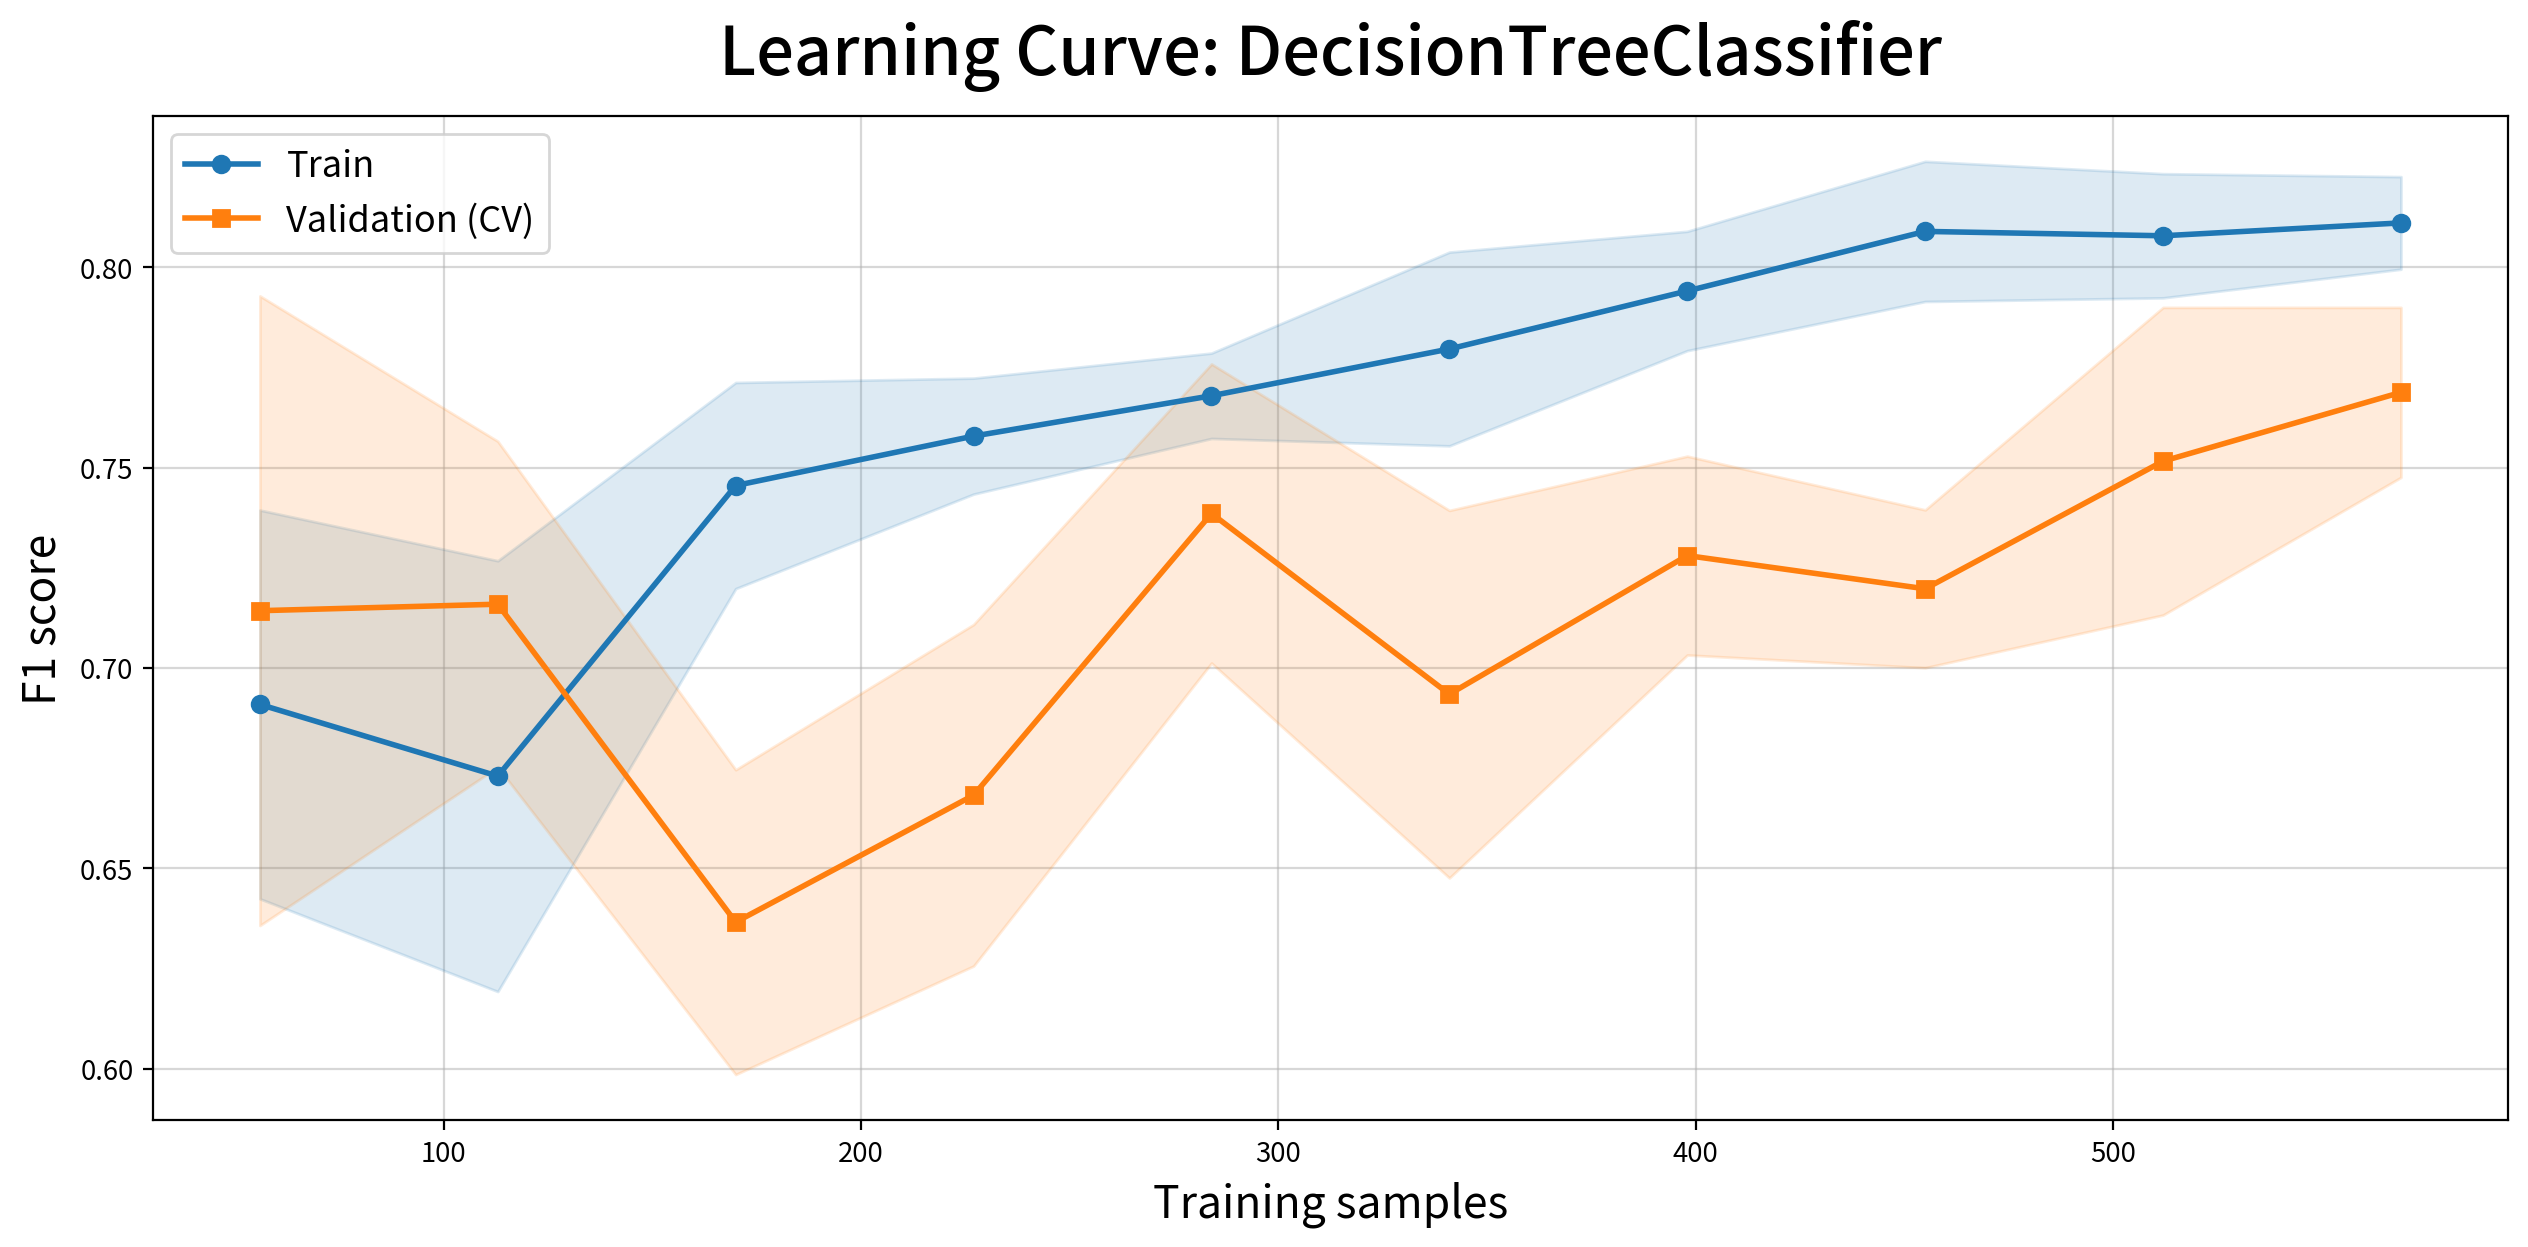


◆ Fit Diagnosis: DecisionTreeClassifier  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__max_depth': 6, 'model__min_samples_leaf': 10}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - F1      Train=     0.8008  CV=     0.7688 (±0.0212)  Test=     0.7287  Gap%=    3.20%  [일반화]
   - ROC_AUC  Train=     0.9173  CV=     0.8563 (±0.0274)  Test=     0.8638  Gap%=    6.11%  [일반화]
   - Accuracy  Train=     0.8596  CV=     0.8315 (±0.0143)  Test=     0.8045  Gap%=    2.81%  [일반화]

   ▶ 진단: ✔ 일반화 (Good fit) — 격차가 작고 훈련 성능도 양호
     · train ROC_AUC=0.9173 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8563

CPU times: total: 375 ms
Wall time: 1.1 s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.801,0.769,0.021,0.729,0.032,3.200,일반화
ROC_AUC,0.917,0.856,0.027,0.864,0.061,6.110,일반화
Accuracy,0.860,0.831,0.014,0.804,0.028,2.810,일반화


In [69]:
%%time
model = my_ml.load_model(f"{workdir}/decisiontree.pkl")
my_ml.cls_overfit(model, x_train, y_train, x_test, y_test)


#### 2. RandomForest

선택된 설정은 n_estimators=300, min_samples_leaf=5이다. 같은 분할의 훈련·CV·내부 검증 지표를 대조하여 트리 단일 모델과 앙상블의 차이를 살펴봤다.


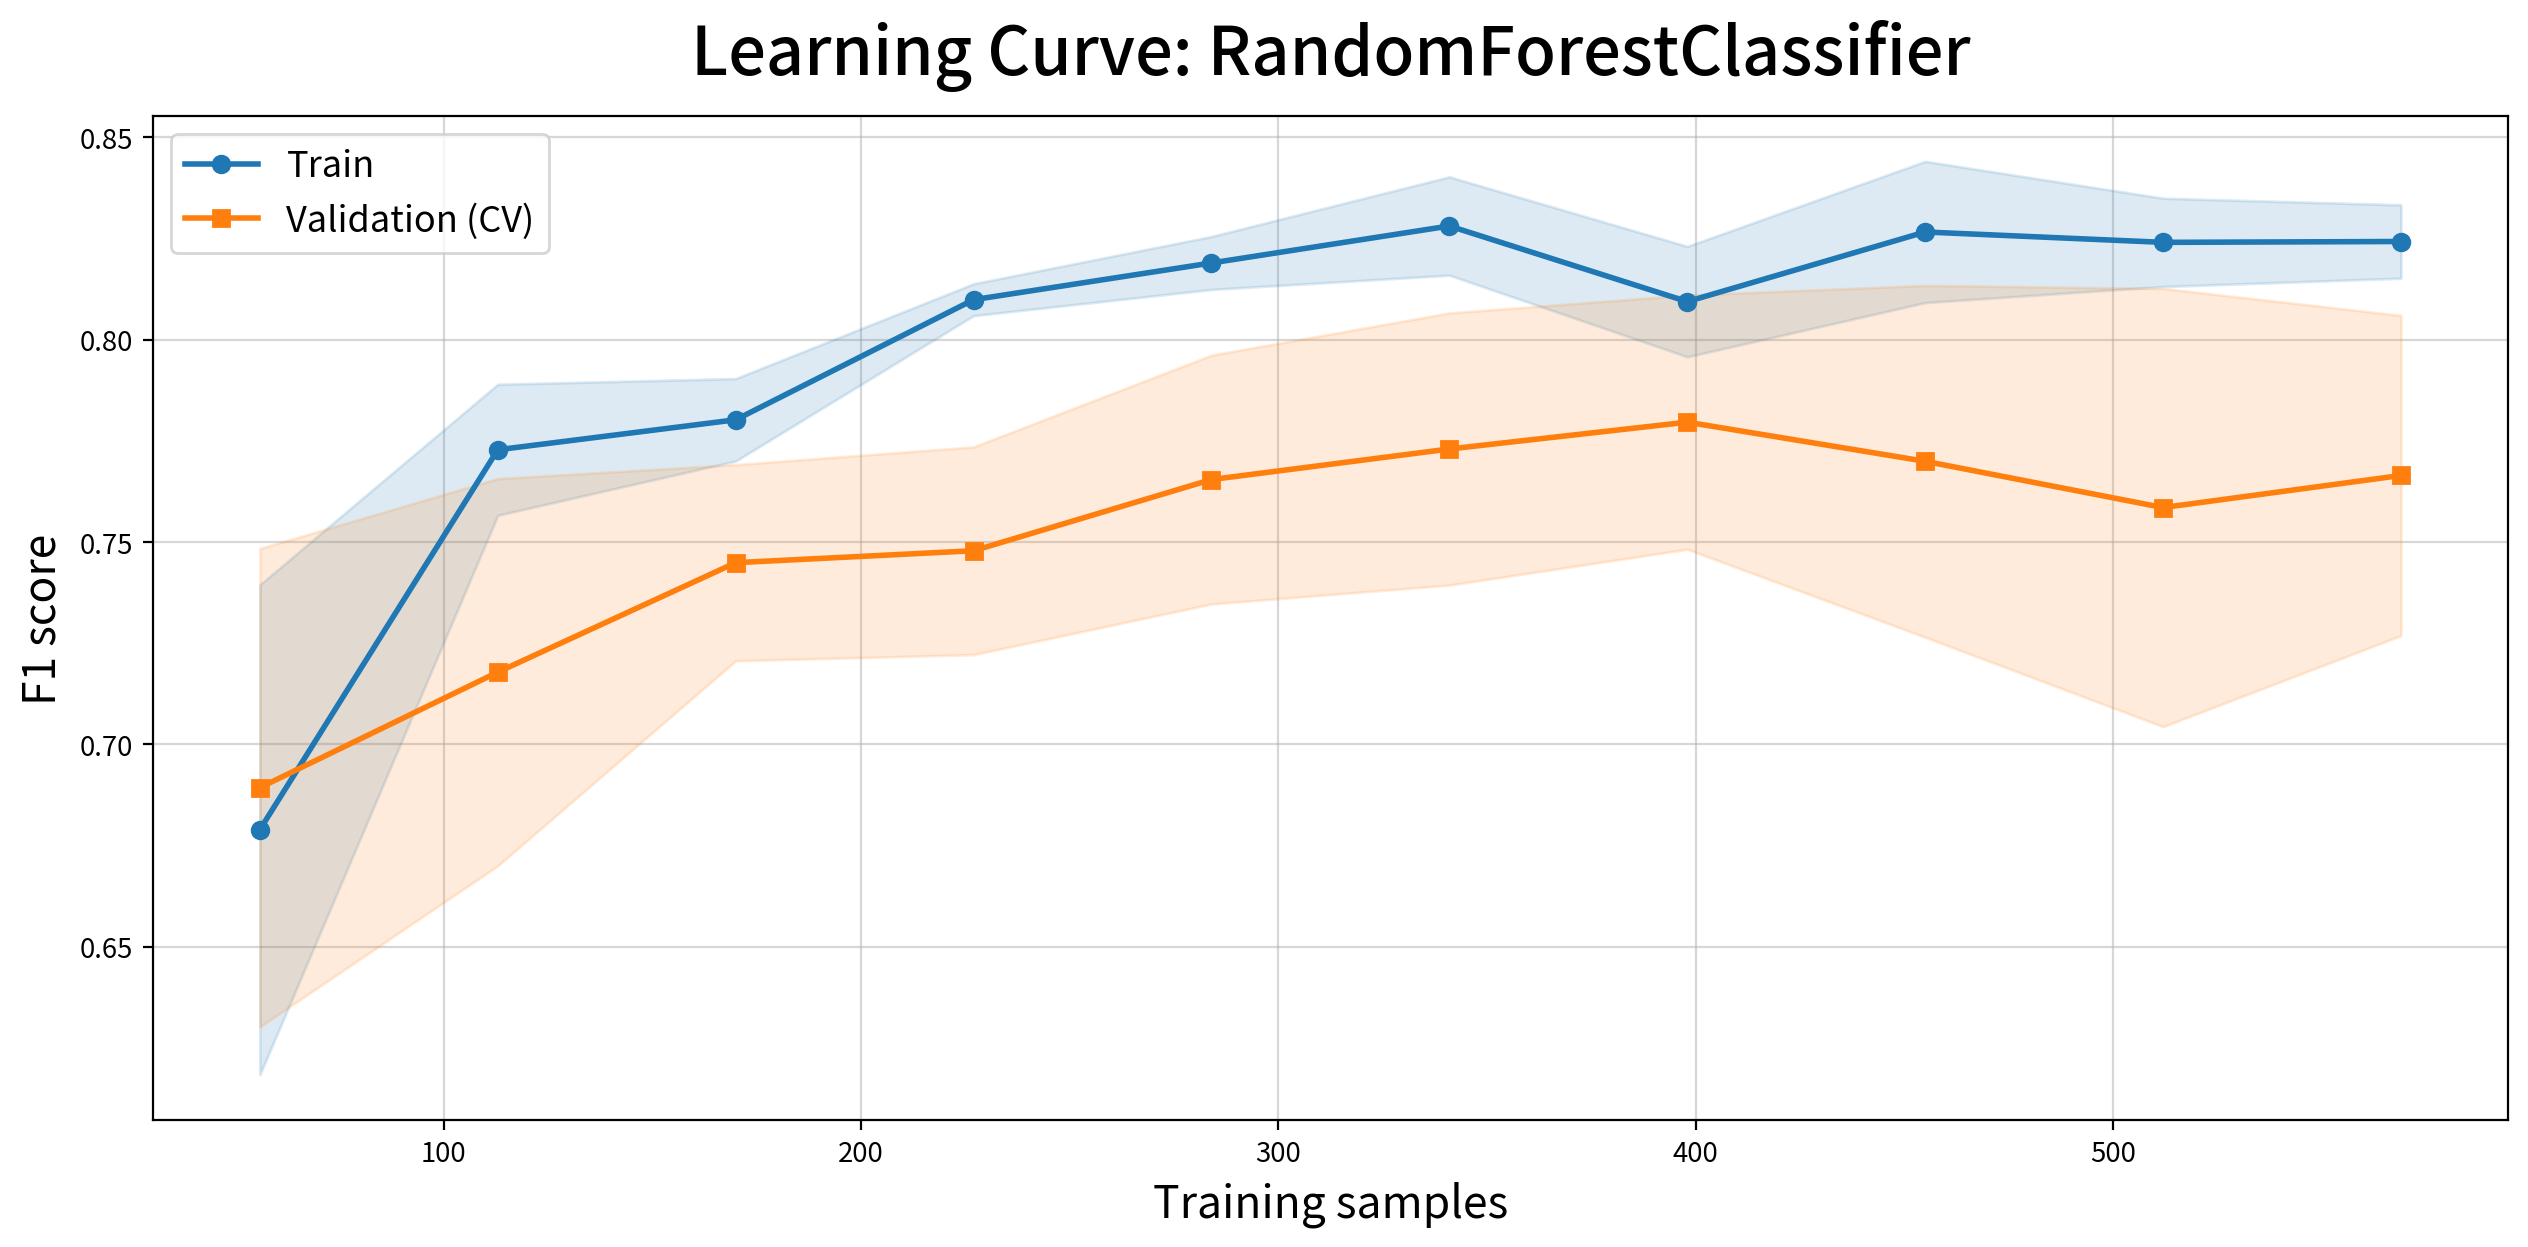


◆ Fit Diagnosis: RandomForestClassifier  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__min_samples_leaf': 5, 'model__n_estimators': 300}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - F1      Train=     0.8210  CV=     0.7635 (±0.0398)  Test=     0.7344  Gap%=    5.75%  [일반화]
   - ROC_AUC  Train=     0.9358  CV=     0.8726 (±0.0194)  Test=     0.8598  Gap%=    6.32%  [일반화]
   - Accuracy  Train=     0.8708  CV=     0.8301 (±0.0234)  Test=     0.8101  Gap%=    4.07%  [일반화]

   ▶ 진단: ✔ 일반화 (Good fit) — 격차가 작고 훈련 성능도 양호
     · train ROC_AUC=0.9358 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8726

CPU times: total: 672 ms
Wall time: 6.95 s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.821,0.764,0.040,0.734,0.057,5.750,일반화
ROC_AUC,0.936,0.873,0.019,0.860,0.063,6.320,일반화
Accuracy,0.871,0.830,0.023,0.810,0.041,4.070,일반화


In [70]:
%%time
model = my_ml.load_model(f"{workdir}/randomforest.pkl")
my_ml.cls_overfit(model, x_train, y_train, x_test, y_test)


##### 과적합 진단 결과

| 모델 | 훈련 F1 | CV F1 평균 ± 표준편차 | 내부 검증 F1 | CV ROC-AUC | 내부 검증 ROC-AUC |
|---|---:|---:|---:|---:|---:|
| DecisionTree | 0.8008 | 0.7688 ± 0.0212 | 0.7287 | 0.8563 | 0.8638 |
| RandomForest 7변수 | 0.8210 | 0.7635 ± 0.0398 | 0.7344 | 0.8726 | 0.8598 |

DecisionTree는 CV F1이 조금 높았고, RandomForest는 내부 검증 F1과 CV ROC-AUC가 조금 높았다. 반면 내부 검증 ROC-AUC는 DecisionTree가 높았다. 어느 모델이 모든 지표에서 일관되게 우월한 결과는 아니다.

훈련–CV F1 격차는 DecisionTree 0.0320, RandomForest 0.0575였다. helper는 둘 다 일반화 범주로 분류했지만, 내부 검증 F1은 두 모델 모두 CV 평균보다 낮았다. 이 진단만으로 미래 데이터에 대한 과적합 위험이 사라졌다고 볼 수 없다. 차이를 해석할 때 CV 표준편차와 단일 검증 분할의 변동성을 함께 고려했다.

이 CV는 최적 설정을 선택한 뒤 같은 훈련 자료에 다시 수행한 진단이다. 독립적인 중첩 교차검증이나 새 데이터 평가와 동일하지 않다. 이후 RandomForest를 이용한 변수 축소는 성능 개선 여부를 확인하는 실험으로 해석했다.


### Feature Importance

#### 1. Feature Importance 도출

불순도 기반 중요도(MDI)를 이용해 누적 중요도 90%를 차지하는 원변수 목록을 구한다. 변수 수를 줄이면 설명을 간소화할 수 있지만, 일반화 성능이 반드시 좋아지는 것은 아니므로 같은 조건으로 재학습·튜닝하여 비교한다.


In [71]:
# 최종 채택 모델인 RandomForestClassifier 모델 로드
model = my_ml.load_model(f"{workdir}/randomforest.pkl")

# 로드한 모델의 feature importance 확인
fi = my_ml.feature_importance(model, cum_ratio=0.9, plot=False)
fi



◆ Feature Importance: RandomForestClassifier  (중요도 기준=MDI(불순도 감소), 채택 기준=cum_ratio=90%)
   ▷ 탐색 객체의 best_params: {'model__min_samples_leaf': 5, 'model__n_estimators': 300}
   ▷ 원핫 더미 16개 → 원본 컬럼 7개로 중요도 합산
   전체 변수 7개 중 5개 채택 (누적 중요도 90.32% 설명)
   ▶ 채택된 변수: ['Title', 'Fare', 'Pclass', 'Age', 'HasCabin']



,Importance,Ratio,CumRatio,채택여부
Feature,,,,
Title,0.519,0.519,0.519,채택
Fare,0.125,0.125,0.645,채택
Pclass,0.105,0.105,0.750,채택
Age,0.081,0.081,0.831,채택
HasCabin,0.072,0.072,0.903,채택
FamilySize,0.066,0.066,0.969,탈락
Embarked,0.031,0.031,1.000,탈락


##### 원변수 단위 중요도 해석

원핫 인코딩된 16개 열의 불순도 감소 중요도(MDI)를 원변수 7개로 합산했다. Title 약 51.9%, Fare 12.5%, Pclass 10.5%, Age 8.1%, HasCabin 7.2%, FamilySize 6.6%, Embarked 3.1% 순이었다. 표시 비율은 반올림값이다.

호칭이 이 RandomForest의 분기에 가장 큰 비중으로 활용되었다. 이는 앞의 호칭·성별별 생존율 차이와 함께 읽을 수 있지만, 전체 생존 원인의 51.9%가 호칭 때문이라는 뜻은 아니다. Title은 성별·연령 등과 정보를 공유하며, 다른 변수의 중요도에도 정보 분배와 상관관계가 영향을 줄 수 있다.

MDI는 분할 후보가 많은 수치형 변수나 범주 수의 영향을 받을 수 있다. 또한 Sex 단독 모델과 비교한 실험은 없으므로 Title을 만든 덕분에 성능이 얼마나 증가했는지는 이 표로 확정하지 않았다.


#### 2. Title에 따른 생존 비율

모델 중요도가 가장 높았던 호칭의 의미를 원자료의 집단 생존율과 대조했다. 모델의 중요도와 집단별 관찰 비율은 서로 다른 결과이므로, 두 수치를 동일한 영향력 척도로 취급하지 않았다.


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Titanic 생존 예측\helpers\my_plot.py:610: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue,


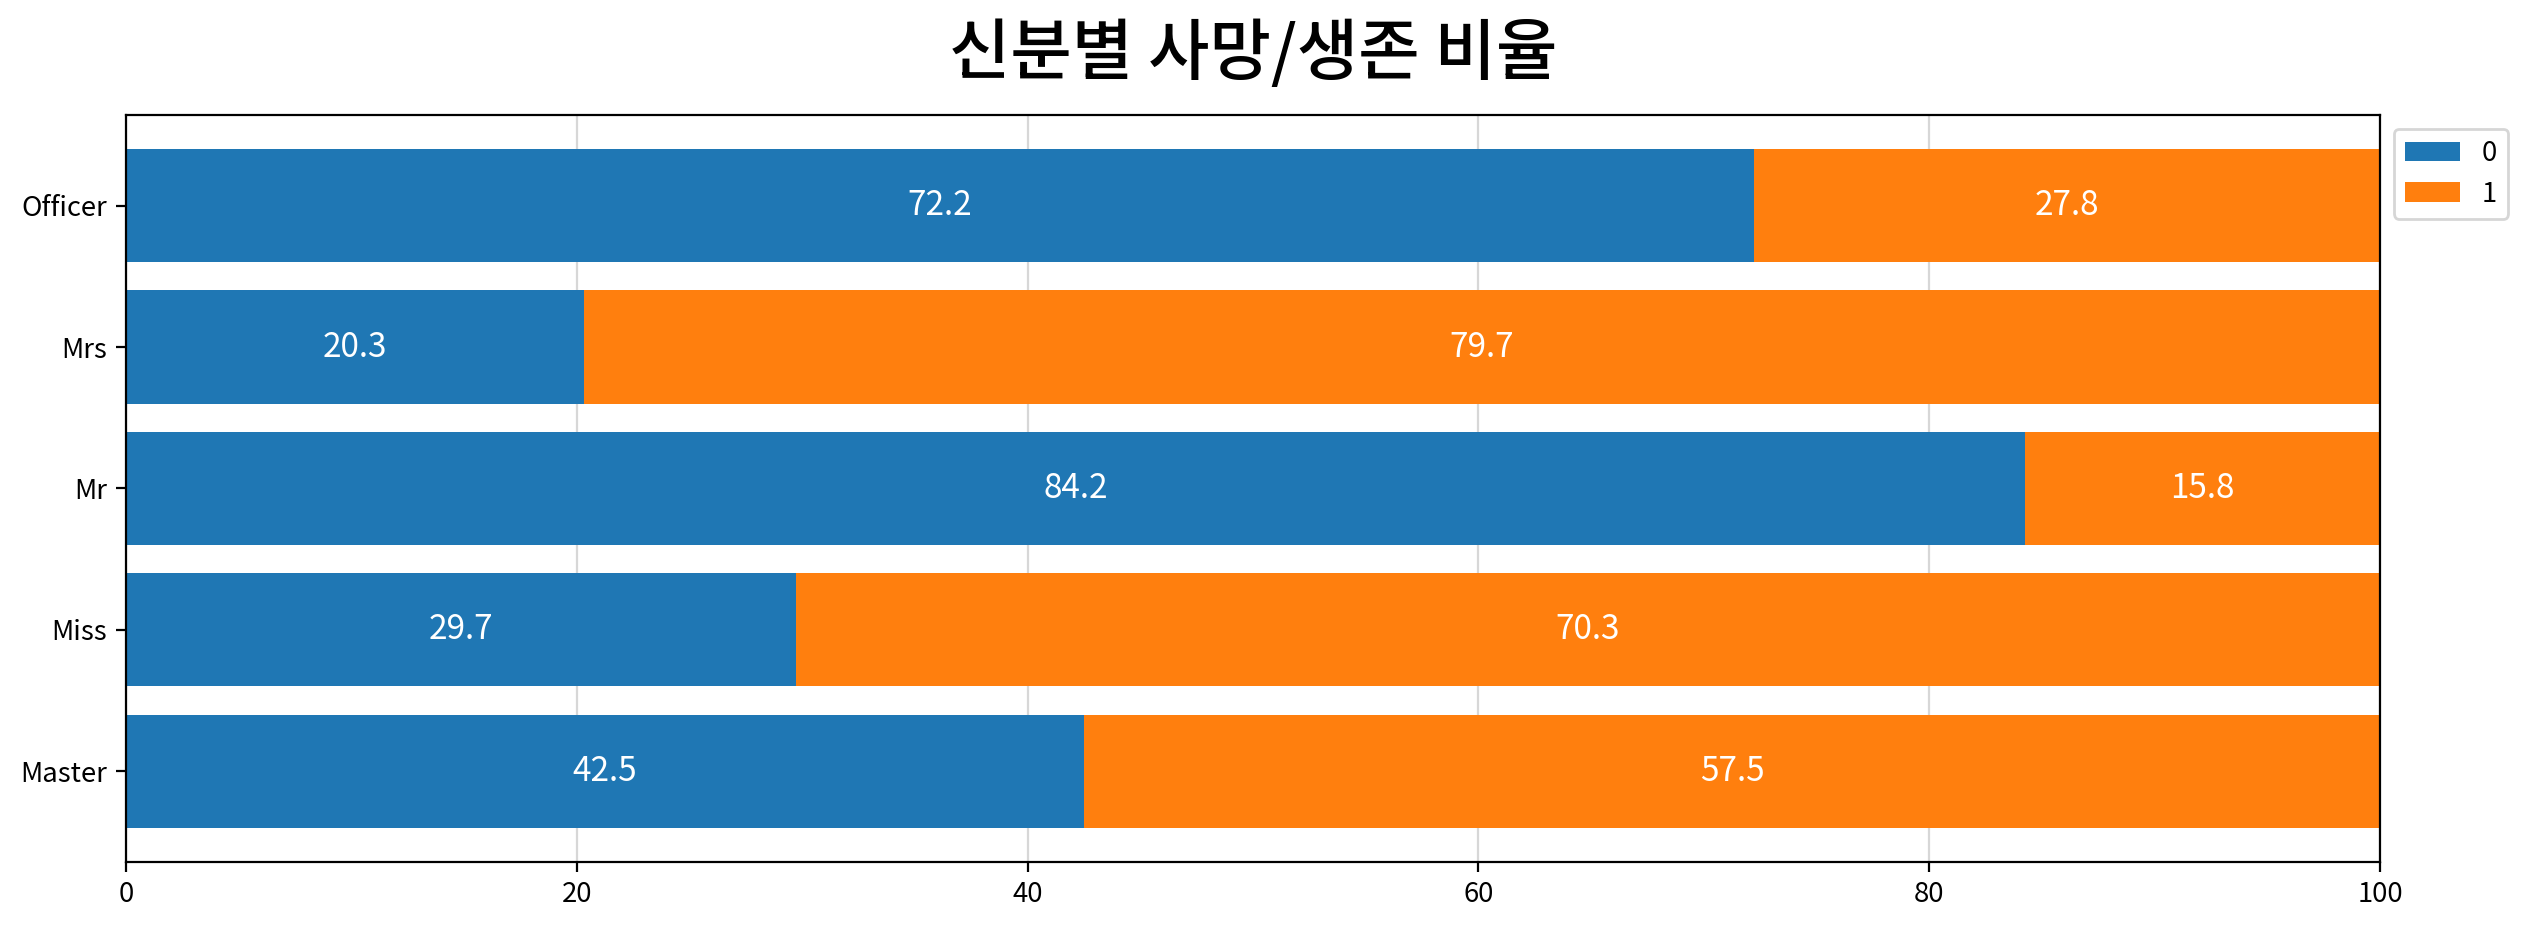

In [72]:
fig, ax = my_plot.init(title="신분별 사망/생존 비율", height=480)

# 탑승객 수를 단순히 count하여 Survived 여부에 따라 비율로 시각화
my_plot.stackplot(origin, x="Title", y="Fare", hue="Survived", ratio=True, 
                  orient='h', aggfunc="count", ax=ax)

ax.set_yticks([0, 1, 2, 3, 4], ['Master', 'Miss', 'Mr', 'Mrs', 'Officer'])
my_plot.show()


##### 호칭별 생존율 해석

생존율은 Mrs 79.7%, Miss 70.3%, Master 57.5%, Officer 27.8%, Mr 15.8% 순이었다. 여성 호칭 집단과 Master의 생존율이 Mr보다 높게 나타났지만, 이는 표본의 집단 차이이며 실제 대피 행동의 인과효과를 뜻하지 않는다.

Officer는 18명 중 5명이 생존한 작은 집단이고, Master도 40명이다. 희소 집단을 일반화하는 데 주의했다. Mrs·Miss의 차이를 혼인 상태 자체의 효과로 해석하지 않았으며, 호칭과 함께 달라질 수 있는 연령·등급·요금 등 다른 특성을 고려했다.


#### 3. 채택된 변수 추출

- `feature_importance()` 의 반환 표에서 채택/탈락을 확인하고    
   **채택된 변수 목록만** 꺼내 재학습에 사용한다.

In [73]:
# 채택된 변수 목록 (재학습에 사용)
selected = fi.attrs['selected_features']
dropped = [c for c in x_train.columns if c not in selected]

print(f"채택 {len(selected)}개: {selected}")
print(f"탈락 {len(dropped)}개: {dropped}")


채택 5개: ['Title', 'Fare', 'Pclass', 'Age', 'HasCabin']
탈락 2개: ['Embarked', 'FamilySize']


##### 변수 축소의 기준과 선택 결과

누적 중요도 90% 기준을 적용하여 **Title·Fare·Pclass·Age·HasCabin**의 5개 변수를 선택했다. 이들의 누적 MDI 비중은 90.32%였으며 FamilySize와 Embarked가 제외되었다.

이 기준은 중요도의 합을 이용한 간소화 규칙이지, 예측정보나 성능의 90%를 보존한다는 보장이 아니다. FamilySize는 EDA에서 생존과 관련된 패턴이 있었지만, 다른 변수와 함께 사용하는 모델에서 상대적 중요도 순위가 낮아 제외되었다. 이 차이를 무관함이나 순수 잡음의 증거로 해석하지 않고 재학습 결과로 축소의 영향을 확인했다.


#### 4. 선택된 변수로 훈련·검증 입력 구성


In [74]:
# 훈련 데이터에서 채택된 변수만 추출
x_tr = x_train[selected]
display(x_tr.columns)

# 검증 데이터에서 채택된 변수만 추출
x_te = x_test[selected]
display(x_te.columns)


Index(['Title', 'Fare', 'Pclass', 'Age', 'HasCabin'], dtype='object')

Index(['Title', 'Fare', 'Pclass', 'Age', 'HasCabin'], dtype='object')

#### 5. 변수 축소 모델의 베이스라인 재학습

선택된 5개 입력으로 RandomForest를 재학습한 후 동일한 4개 튜닝 조합과 5-fold 조건을 적용했다. 변수 수 감소와 함께 지표가 어떻게 달라지는지 7변수 모델과 비교했다.


In [75]:
randomforest = my_ml.fit_pipeline(
                impute=True,  # 중앙값·최빈값을 훈련 데이터/각 CV 훈련 fold에서 학습
            model=RandomForestClassifier(
                    random_state=RANDOM_STATE, n_jobs=-1),
            x_train=x_tr, y_train=y_train,
            vif=True,
            encode=True)    # 트리 계열이므로 모든 범주를 유지한 더미변수 생성

display(my_ml.cls_score(randomforest, x_te, y_test))

randomforest


대상: 712행 x 5열 | 모델: randomforest
명목형: ['Title', 'Pclass', 'HasCabin']
연속형: ['Fare', 'Age']

전처리 단계
  연속형: 결측치 대체(median) → 다중공선성 제거(VIF >= 10.0)
  명목형: 결측치 대체(most_frequent) → 더미변수 인코딩(drop_first=False)

모델 학습 완료: randomforest


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RandomForestClassifier,0.788,0.712,0.754,0.732,0.850,0.787,0.855,0.557


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 6. 변수 축소 모델의 하이퍼파라미터 튜닝


In [76]:
%%time

# 수업용 탐색 조합 (01-모델링의 RandomForest 튜닝과 같은 조합을 쓴다.
# 변수만 줄이고 조건을 똑같이 맞춰야 "변수 선택의 효과"만 따로 볼 수 있다)
param_grid = {
    "model__n_estimators": [100, 300],     # 숲을 이루는 트리 개수
    "model__min_samples_leaf": [1, 5]      # 잎 노드가 가져야 할 최소 표본 수
}

# 하이퍼파라미터 튜닝 수행
gs = GridSearchCV(estimator=randomforest, param_grid=param_grid, cv=5, 
                  scoring="f1", n_jobs=-1)
gs.fit(x_tr, y_train)

gs.name_ = f"{model.name_}_selected"   # 변수 선택 후 재튜닝된 모델임을 이름에 남긴다
my_ml.save_model(gs, f"{savedir}/randomforest.pkl") # 튜닝이 완료된 모델을 저장한다.
display(my_ml.cls_score(gs, x_te, y_test))          # 성능 평가


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
Model,,,,,,,,
RandomForestClassifier,0.793,0.767,0.667,0.713,0.845,0.826,0.455,0.556


CPU times: total: 1.08 s
Wall time: 2.4 s


#### 7. 변수 축소 모델의 과적합 진단


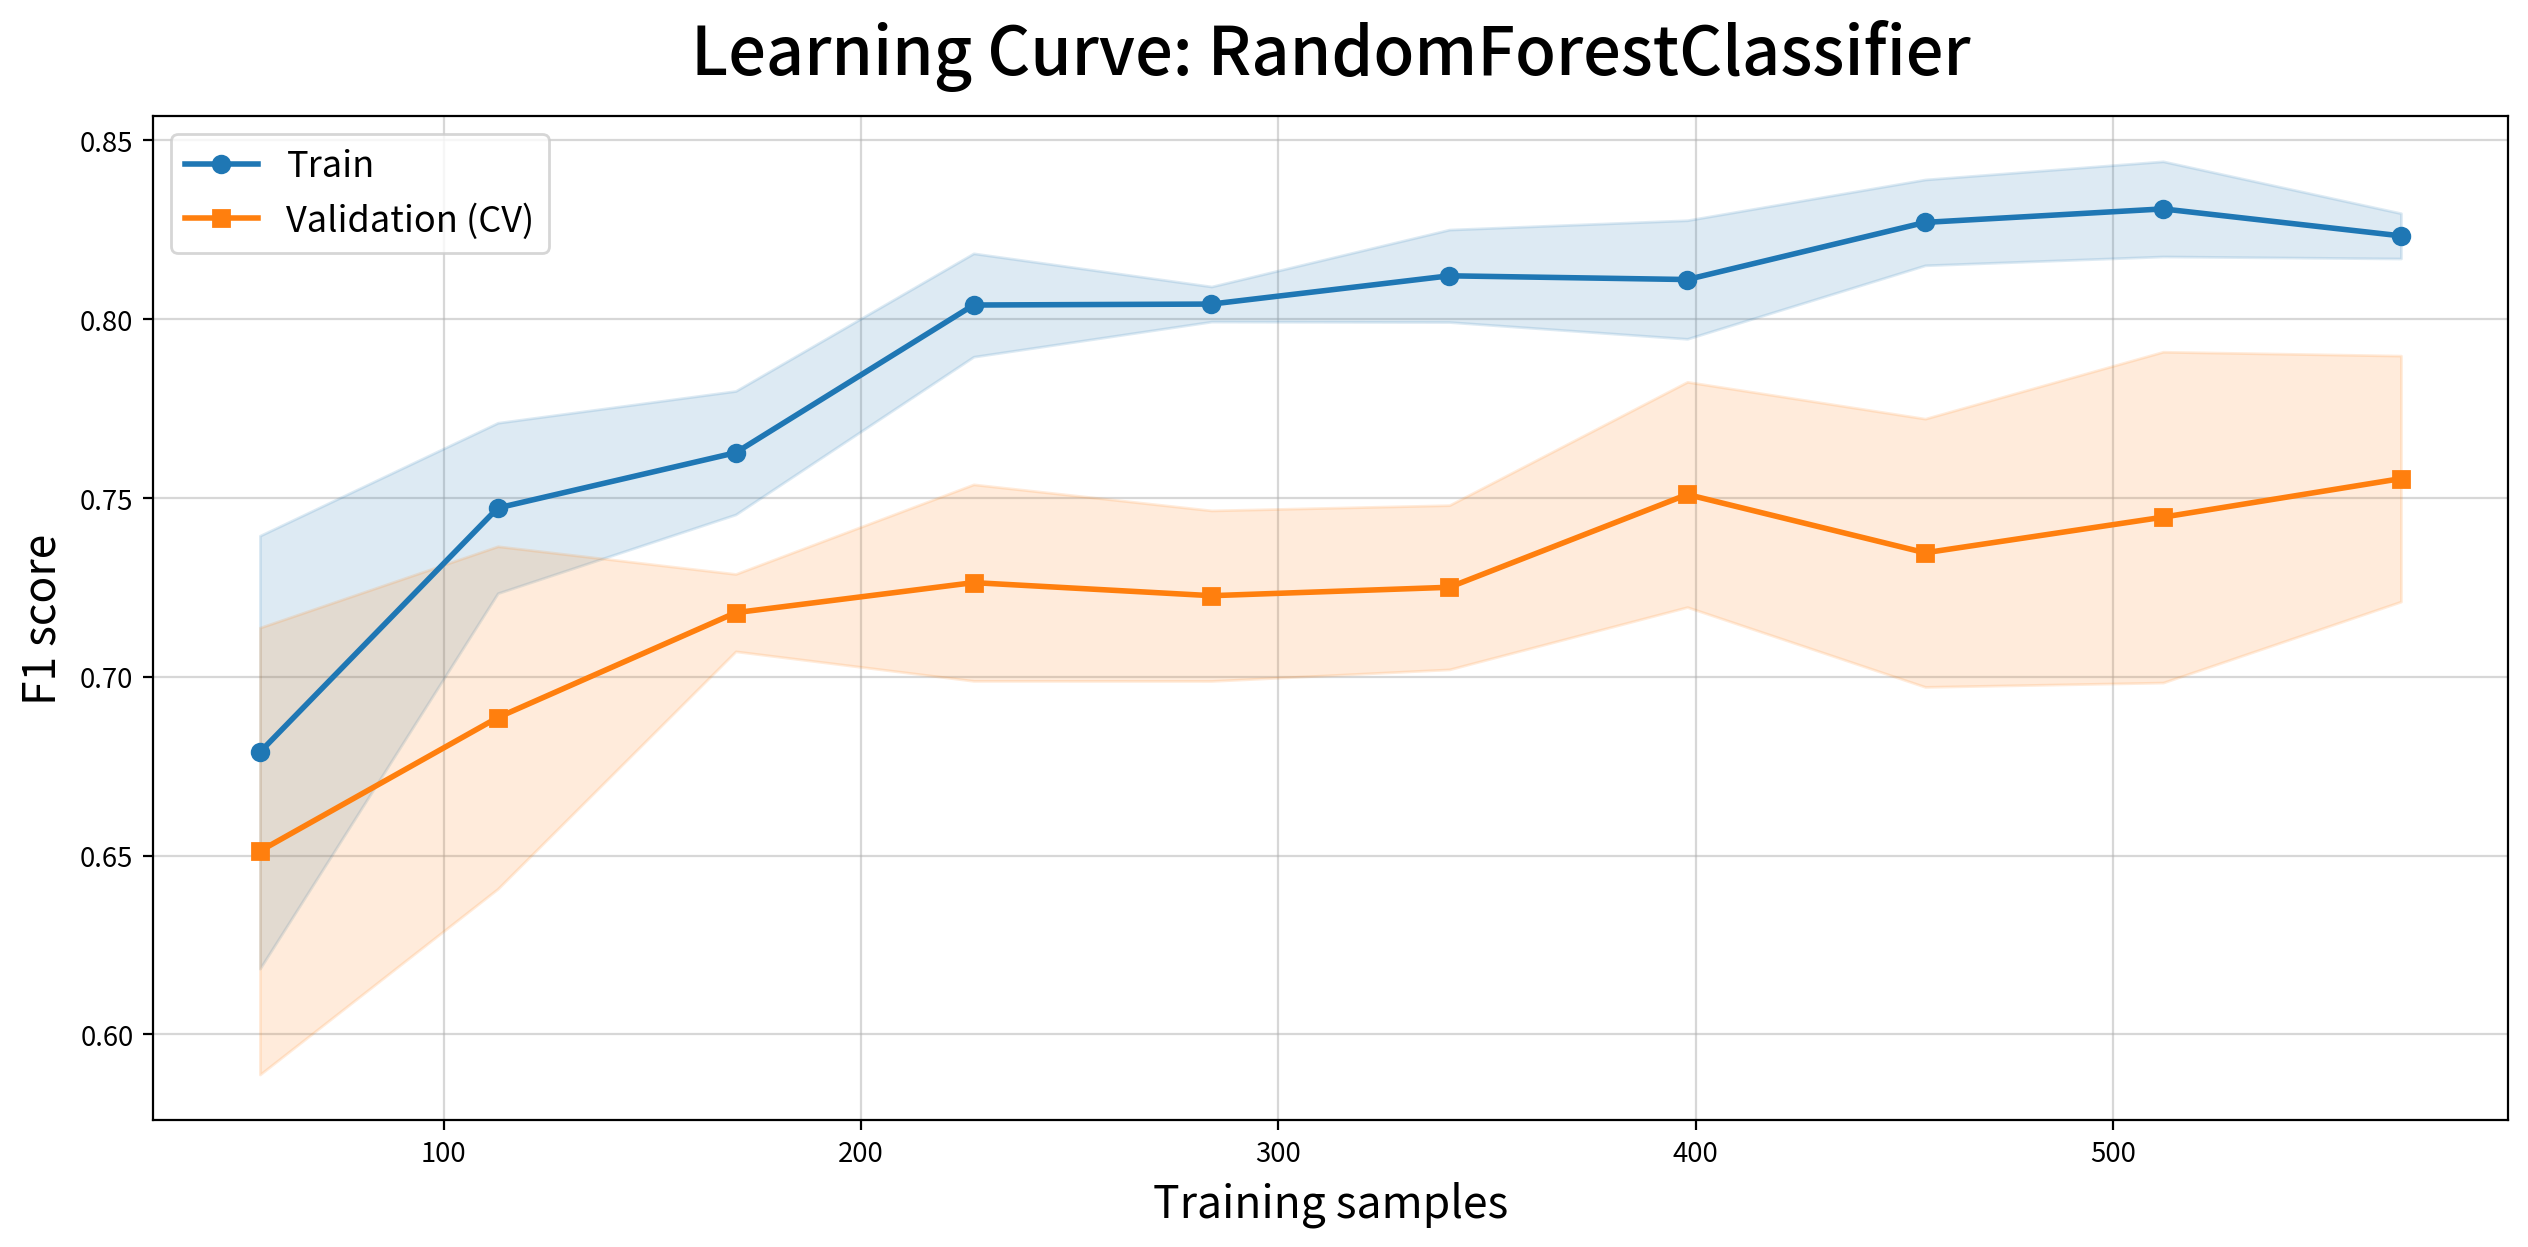


◆ Fit Diagnosis: RandomForestClassifier  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__min_samples_leaf': 5, 'model__n_estimators': 300}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - F1      Train=     0.8170  CV=     0.7560 (±0.0372)  Test=     0.7132  Gap%=    6.10%  [일반화]
   - ROC_AUC  Train=     0.9335  CV=     0.8709 (±0.0213)  Test=     0.8455  Gap%=    6.26%  [일반화]
   - Accuracy  Train=     0.8666  CV=     0.8273 (±0.0207)  Test=     0.7933  Gap%=    3.93%  [일반화]

   ▶ 진단: ✔ 일반화 (Good fit) — 격차가 작고 훈련 성능도 양호
     · train ROC_AUC=0.9335 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8709

CPU times: total: 594 ms
Wall time: 6.58 s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.817,0.756,0.037,0.713,0.061,6.100,일반화
ROC_AUC,0.934,0.871,0.021,0.845,0.063,6.260,일반화
Accuracy,0.867,0.827,0.021,0.793,0.039,3.930,일반화


In [77]:
%%time
my_ml.cls_overfit(gs, x_tr, y_train, x_te, y_test)


##### 축소 전후 비교와 판단

| 지표 | 7변수 RandomForest | 5변수 RandomForest | 변화 |
|---|---:|---:|---|
| CV F1 | 0.7635 | 0.7560 | 0.0075 감소 |
| 내부 검증 F1 | 0.7344 | 0.7132 | 0.0212 감소 |
| 내부 검증 ROC-AUC | 0.8598 | 0.8455 | 0.0143 감소 |
| 내부 검증 Accuracy | 0.8101 | 0.7933 | 약 1.68%p 감소 |
| 내부 검증 LogLoss | 0.433 | 0.455 | 증가, 확률 예측 지표도 악화 |

입력은 7개에서 5개로 줄었지만 F1·ROC-AUC·정확도·LogLoss가 모두 나빠졌다. 선택된 설정은 두 모델 모두 트리 300개·최소 잎 표본 5개였다. 따라서 **성능을 유지하면서 간소화했다는 결론은 성립하지 않으며, 성능 보존 관점에서는 7변수 RandomForest를 유지하는 쪽이 타당하다.**

5변수 모델의 훈련 F1은 0.8170, CV F1은 0.7560±0.0372로, 훈련–CV 격차도 약 0.0610이었다. 간소화했다고 과적합 격차가 줄어든 결과도 아니다. 다만 단일 분할의 작은 차이가 통계적으로 유의하다고 주장하지는 않는다.

다음 SHAP은 학습이 완료된 5변수 모델의 예측 기여를 설명하는 분석이다. 이 설명 결과를 KNN이나 7변수 RandomForest의 설명으로 바꾸어 읽지 않으며, 5변수 모델을 최종 성능 우승 모델로 제시하지 않는다.


<a id="stage-6"></a>

## 6. 변수 축소 모델의 SHAP 해석

Title·Fare·Pclass·Age·HasCabin을 사용하는 5변수 RandomForest를 설명했다. 성능이 가장 높았던 KNN과 설명 대상 모델을 구분하며, 변수 축소 실험에서 얻은 모델이 어떤 특성에 의존하는지를 분석했다.


### 분석 설정

#### 1. 라이브러리 참조

In [78]:
from jussam import load_data
from helpers import *
import glob as gl
from sklearn.model_selection import train_test_split


#### 2. 데이터 불러오기 + 범주형 타입 변환

In [79]:
# 같은 891건, 같은 파생변수, 결측 대체 전 데이터를 계속 사용한다.
origin = model_data.copy()
df = origin.copy()
assert len(df) == 891


#### 3. 데이터 분할

In [80]:
# 독립변수 분리
feature = df.drop(columns=["Survived"])

# 종속변수 분리
target = df["Survived"]

# 훈련, 검증 데이터 분할
# 분류 문제이므로 stratify=target 을 지정해 클래스 비율을 유지한다.
x_train, x_test, y_train, y_test = train_test_split(
        feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((712, 7), (179, 7), (712,), (179,))

#### 4. Feature Importance의 결과에 따른 변수 선택

In [81]:
# 앞 절에서 이번 실행으로 선택한 목록을 그대로 연결한다. 예전 5개 목록을 고정하지 않는다.
x_tr = x_train[selected].copy()
x_te = x_test[selected].copy()
print(f"SHAP 대상 원변수 {len(selected)}개: {selected}")


SHAP 대상 원변수 5개: ['Title', 'Fare', 'Pclass', 'Age', 'HasCabin']


#### 5. 저장폴더 지정

In [82]:
# 최종 모델이 저장되어 있는 위치
savedir = "titanic_train891/importance"
savedir


'titanic_train891/importance'

#### 6. 저장된 5변수 RandomForest 로드


In [83]:
gs = my_ml.load_model(f"{savedir}/randomforest.pkl")
assert list(gs.feature_names_in_) == list(x_tr.columns), "저장 모델과 SHAP 입력 열이 다릅니다."
gs


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__min_samples_leaf': [1, 5], 'model__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

### SHAP 분석

#### 1. SHAP Explainer 객체 생성

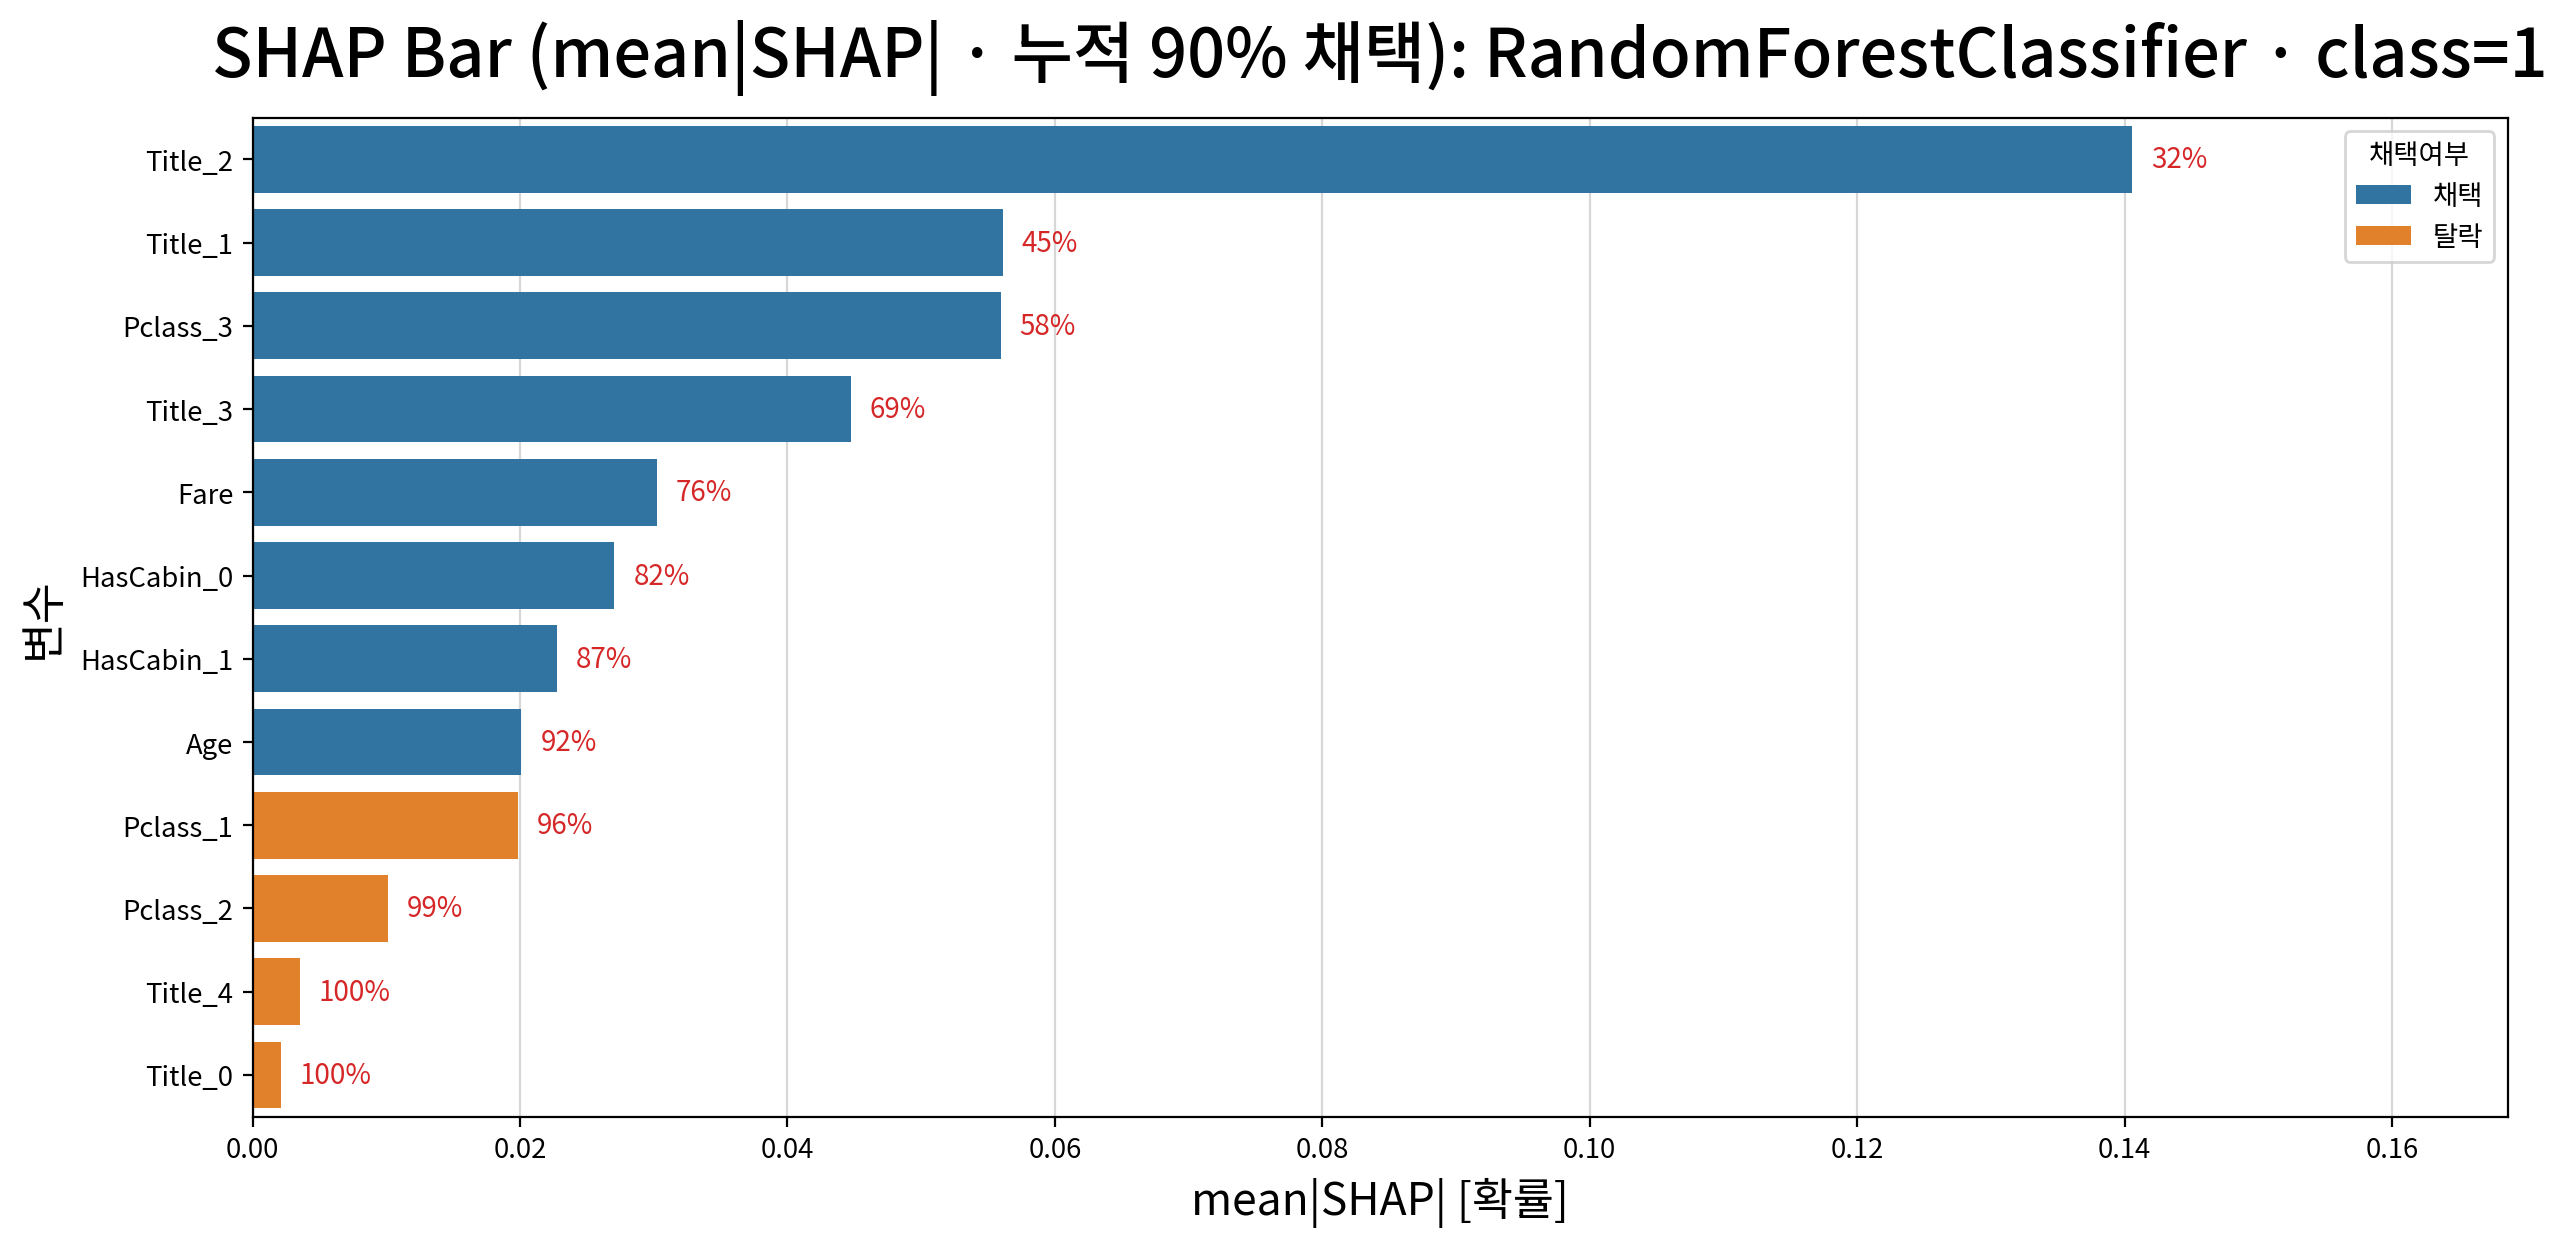

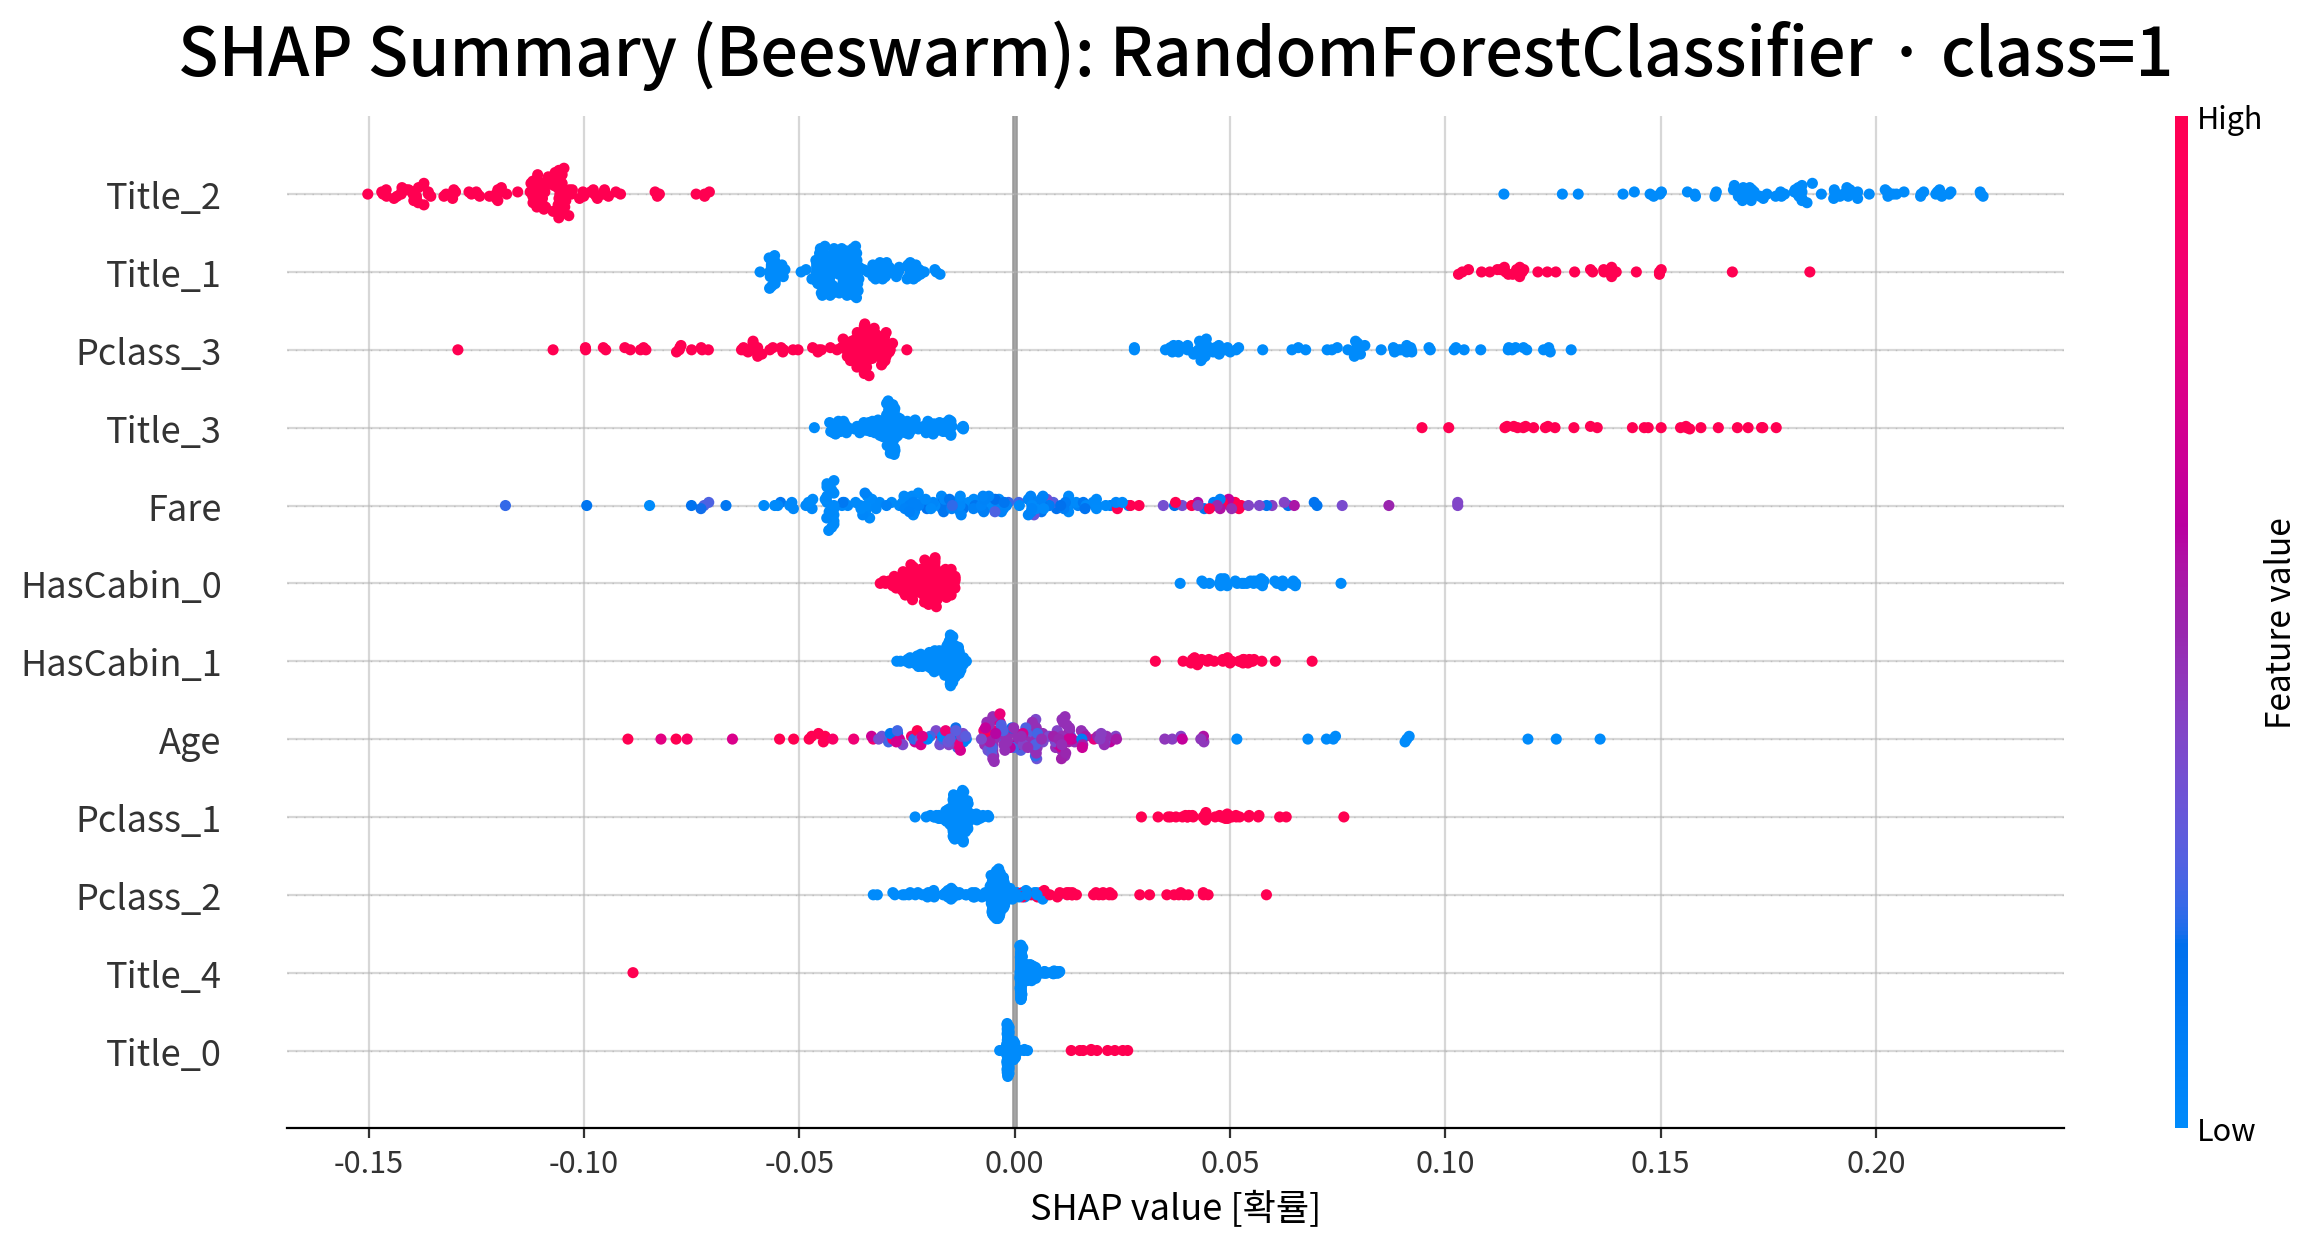


◆ SHAP Analysis: RandomForestClassifier  (TreeExplainer, classification)
   ▷ 설명 대상 클래스: 1 (index=1)
   ▷ 탐색 객체의 best_params: {'model__min_samples_leaf': 5, 'model__n_estimators': 300}
   설명 표본 200행 × 변수 12개 · base value=0.3837 · SHAP 단위=확률
   Title_2                mean|SHAP|=0.1406  방향=증가  비선형/불안정
   Title_1                mean|SHAP|=0.0561  방향=감소  비선형/불안정
   Pclass_3               mean|SHAP|=0.0559  방향=감소  비선형/불안정
   Title_3                mean|SHAP|=0.0447  방향=감소  비선형/불안정
   Fare                   mean|SHAP|=0.0303  방향=감소  비선형/불안정



In [84]:
# 이번 891건으로 학습한 변수 축소 RandomForest 후보를 설명한다.
shap = my_ml.shap_analysis(gs, x_tr)


##### SHAP 요약 해석

TreeExplainer로 훈련 데이터 중 200건을 설명했다. 대상은 생존 클래스 1이고, 5개 원변수가 원핫 인코딩 후 12개 열로 표현되었다. SHAP 단위는 **확률**, 기준값은 약 **0.3837**이다. 양의 SHAP은 이 기준 예측보다 생존 예측을 높이는 기여, 음의 값은 낮추는 기여다. 기준값은 모델·explainer의 기준 예측이지 모든 승객의 보편적인 생존확률이 아니다.

| 특성 | mean\|SHAP\| | beeswarm에서 관찰된 패턴 |
|---|---:|---|
| Title_2: Mr | 0.1406 | Mr 해당 관측치는 음의 기여, 비해당 관측치는 양의 기여 쪽에 분포 |
| Title_1: Miss | 0.0561 | 해당 관측치는 주로 양의 기여 |
| Pclass_3: 3등급 | 0.0559 | 해당 관측치는 주로 음의 기여 |
| Title_3: Mrs | 0.0447 | 해당 관측치는 주로 양의 기여 |
| Fare | 0.0303 | 저요금 구간은 기여의 분산이 크고, 높은 요금 관측치는 대체로 양의 기여 |

Mr 더미의 평균 절대 기여 0.1406은 확률 단위로 약 14.06%p이다. 모든 Mr 승객의 생존확률이 같은 크기로 낮아진다거나, 호칭을 바꾸면 생존확률이 변한다는 뜻이 아니다. 또한 각 호칭에 해당하지 않는 더미도 기여할 수 있어 개인의 Title 전체 기여는 모든 Title 더미의 SHAP을 합쳐야 한다.

출력의 `방향=증가/감소`는 부호 있는 SHAP의 표본 평균을 요약한 것이다. 예를 들어 Title_2의 출력은 '증가'이지만, 실제 Mr 해당 점들은 음의 영역에 있다. 따라서 평균 방향 문구를 'Mr이면 생존확률 증가'로 읽지 않고, 더미 값과 SHAP 분포를 함께 확인했다. `비선형/불안정` 표시 역시 모델 안정성에 대한 독립적인 통계 검정은 아니다.

HasCabin_1에 해당하는 관측치는 주로 양의 기여를 보였고, HasCabin_0에 해당하면 음의 기여가 나타났다. 이는 객실 정보가 기록된 승객 집단의 특성을 모델이 활용한 것으로 해석할 수 있으나, 기록 여부 자체의 인과효과로 단정할 수 없다. MDI와 SHAP에서 호칭이 중요하게 나타났다는 점도 독립적인 성능 검증을 대신하지 않는다.


#### 2. Dependence Plot

◆ SHAP Dependence — 변수쌍(주변수 × 상호작용변수) · 선정기준=cum_ratio=90%
   Title_2  ×  Pclass_2
   Title_1  ×  Title_3
   Pclass_3  ×  Title_2
   Title_3  ×  Title_2
   Fare  ×  Title_2
   HasCabin_0  ×  Pclass_3
   HasCabin_1  ×  Pclass_2
   Age  ×  HasCabin_0


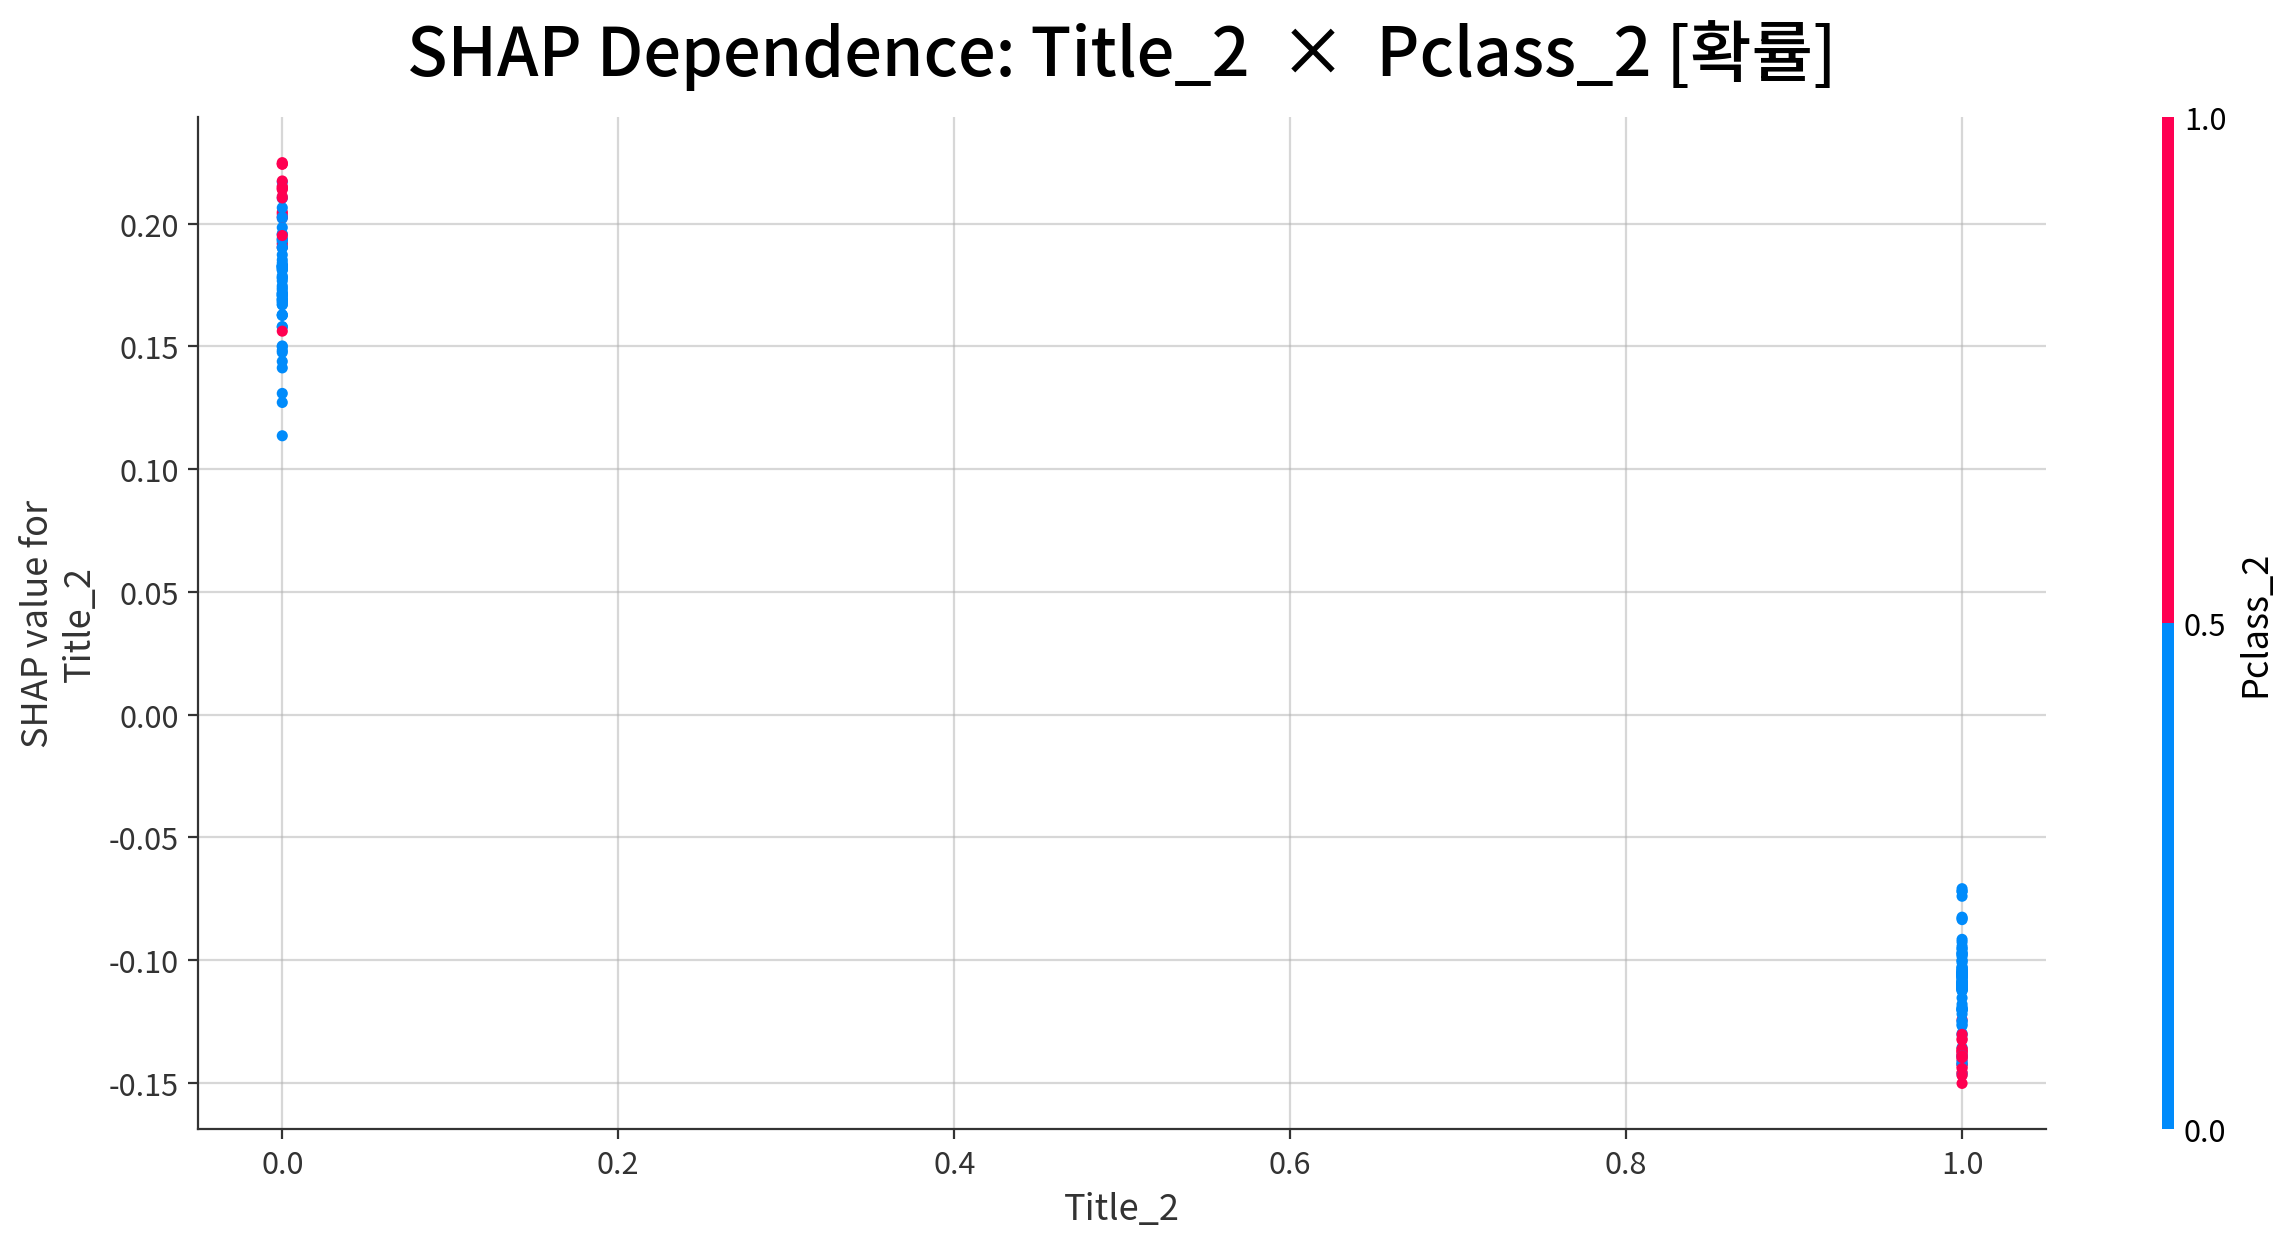

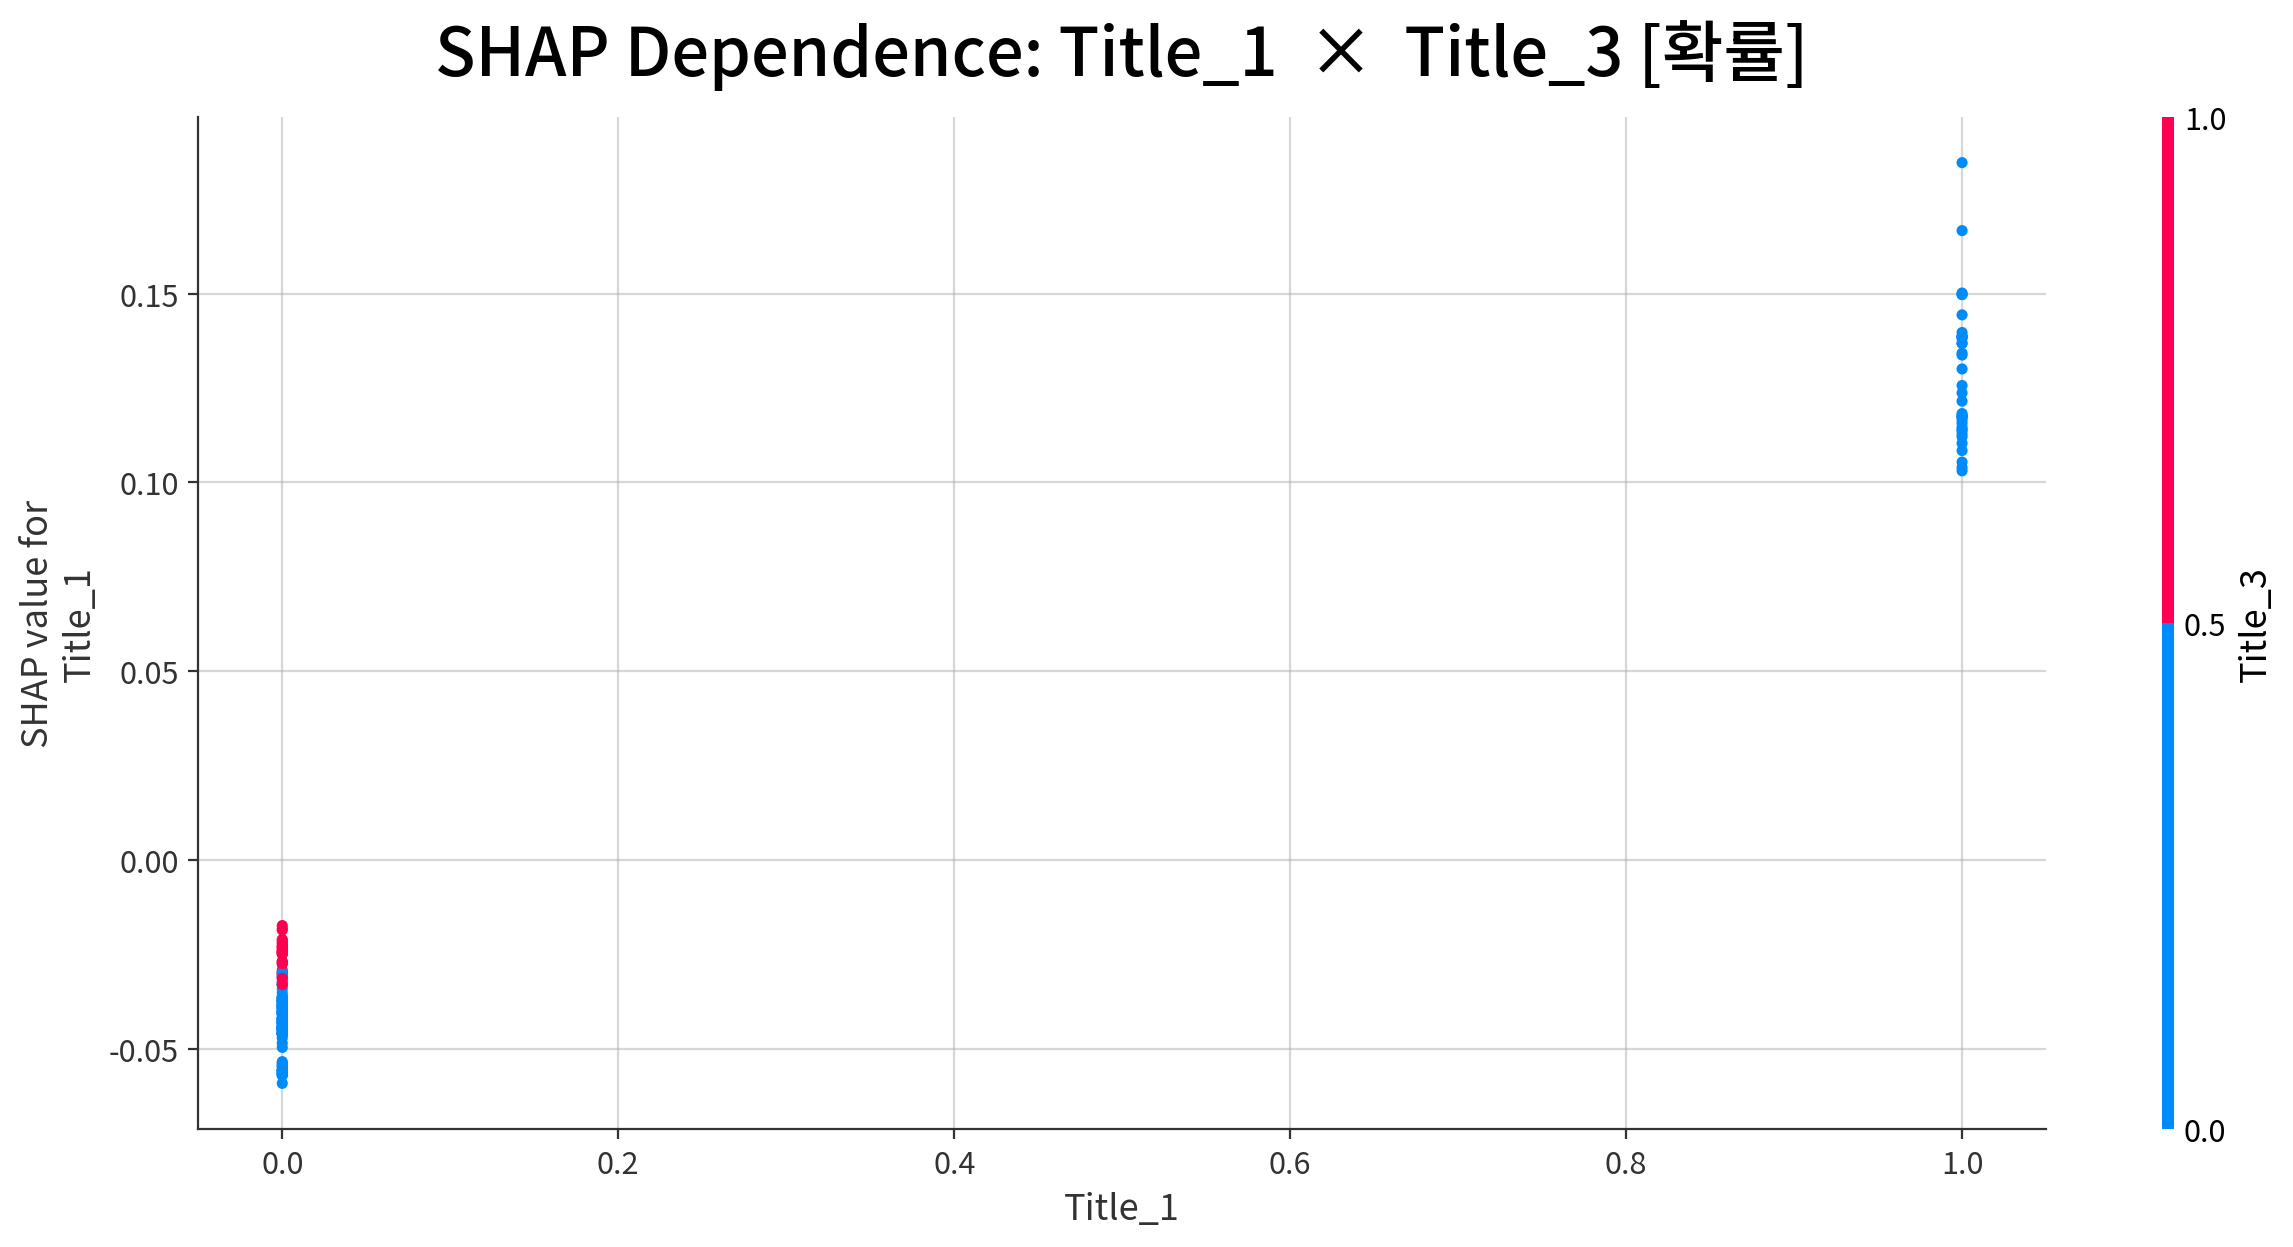

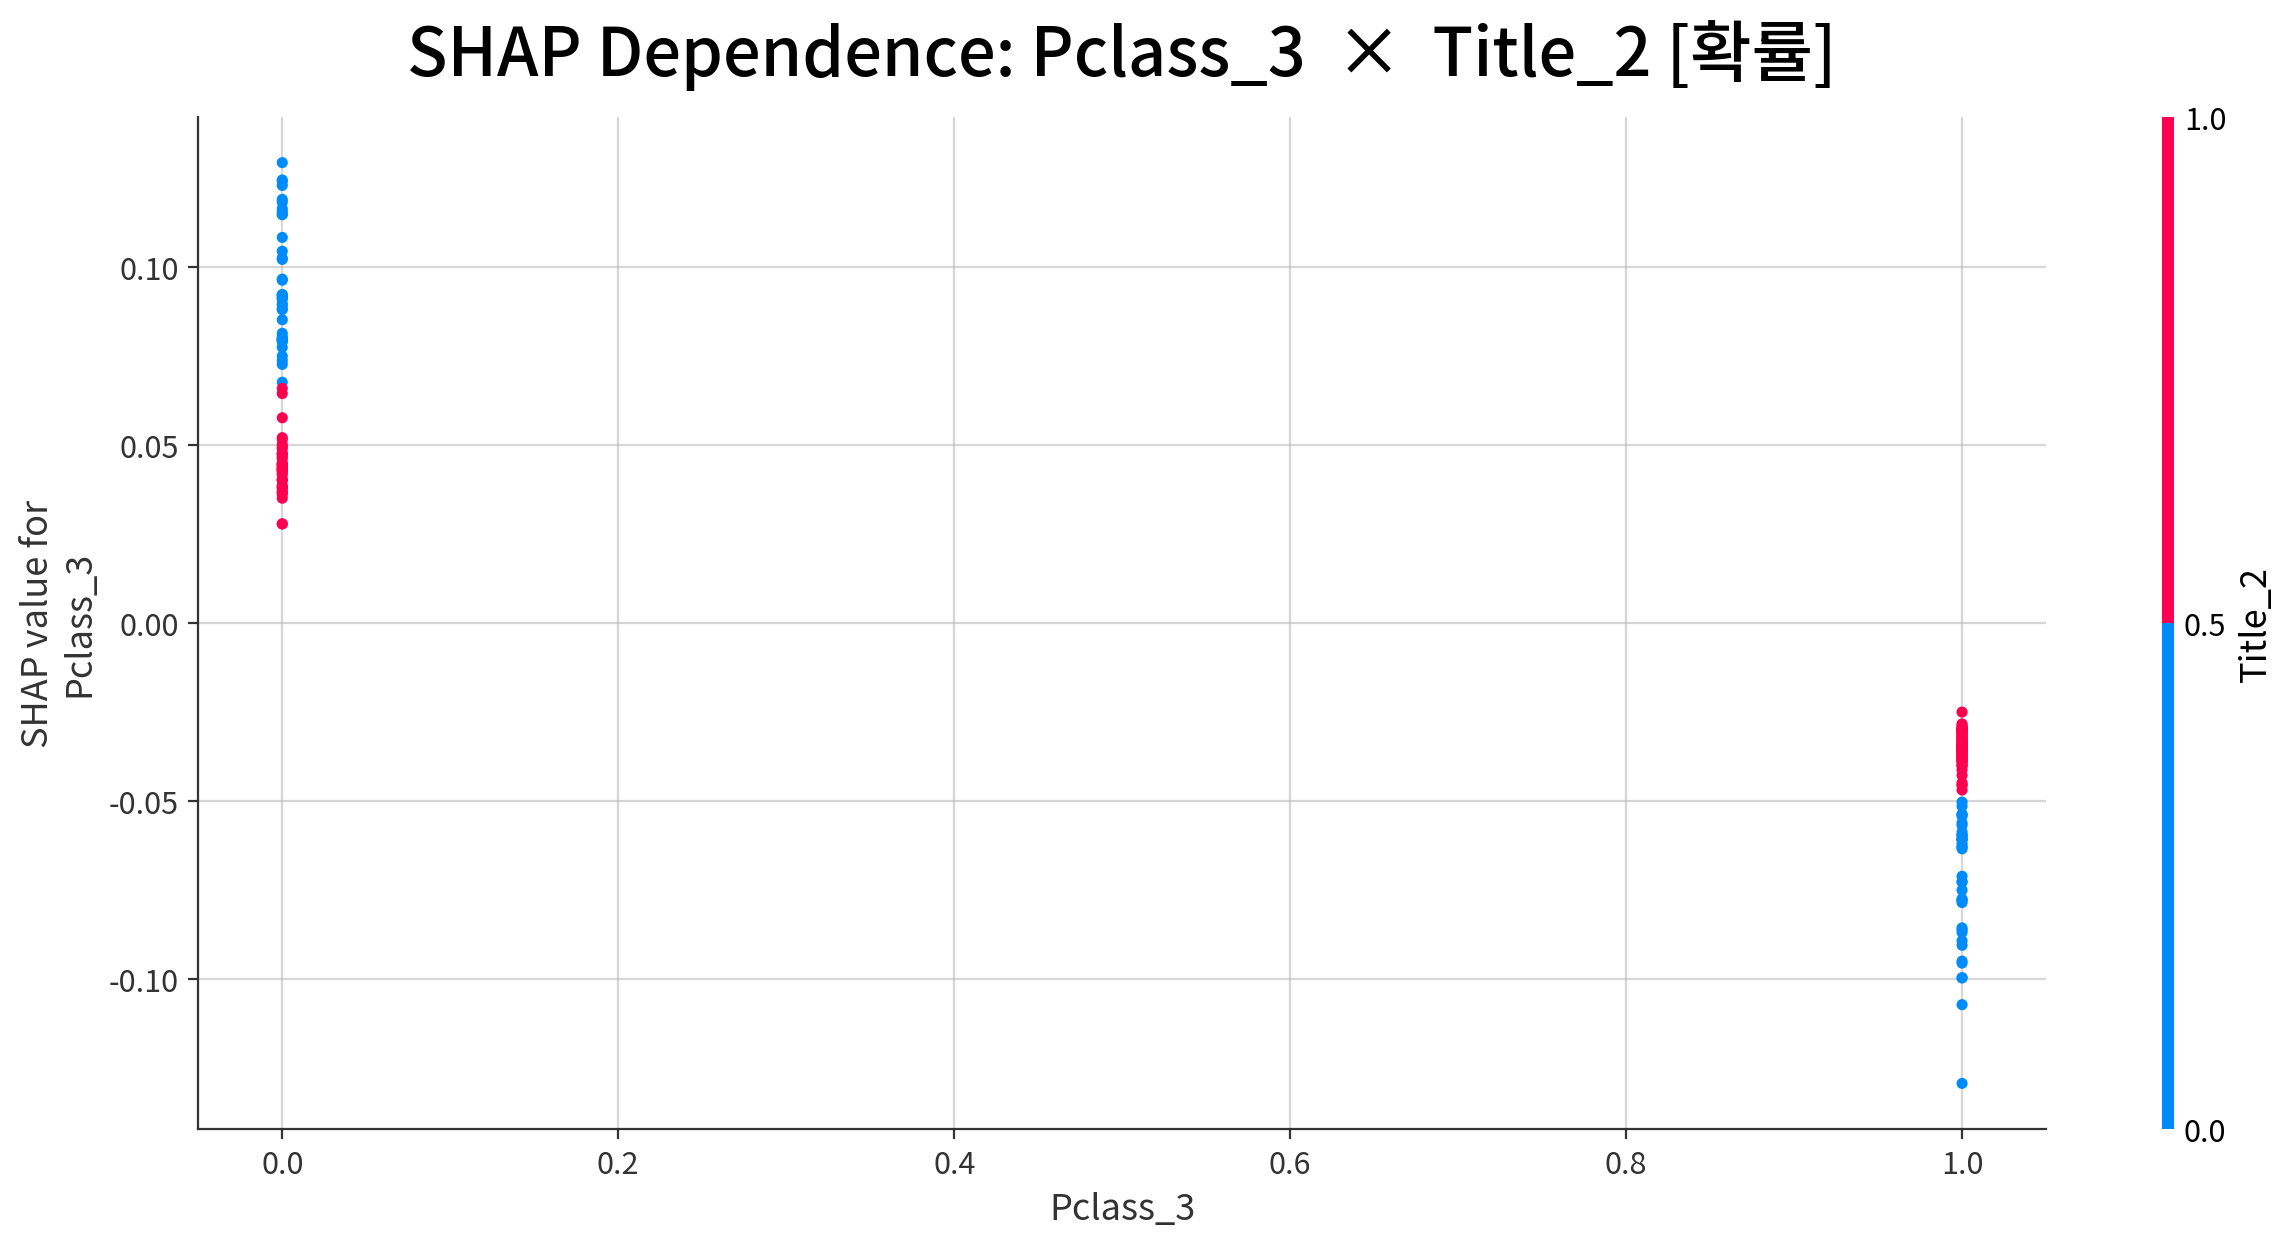

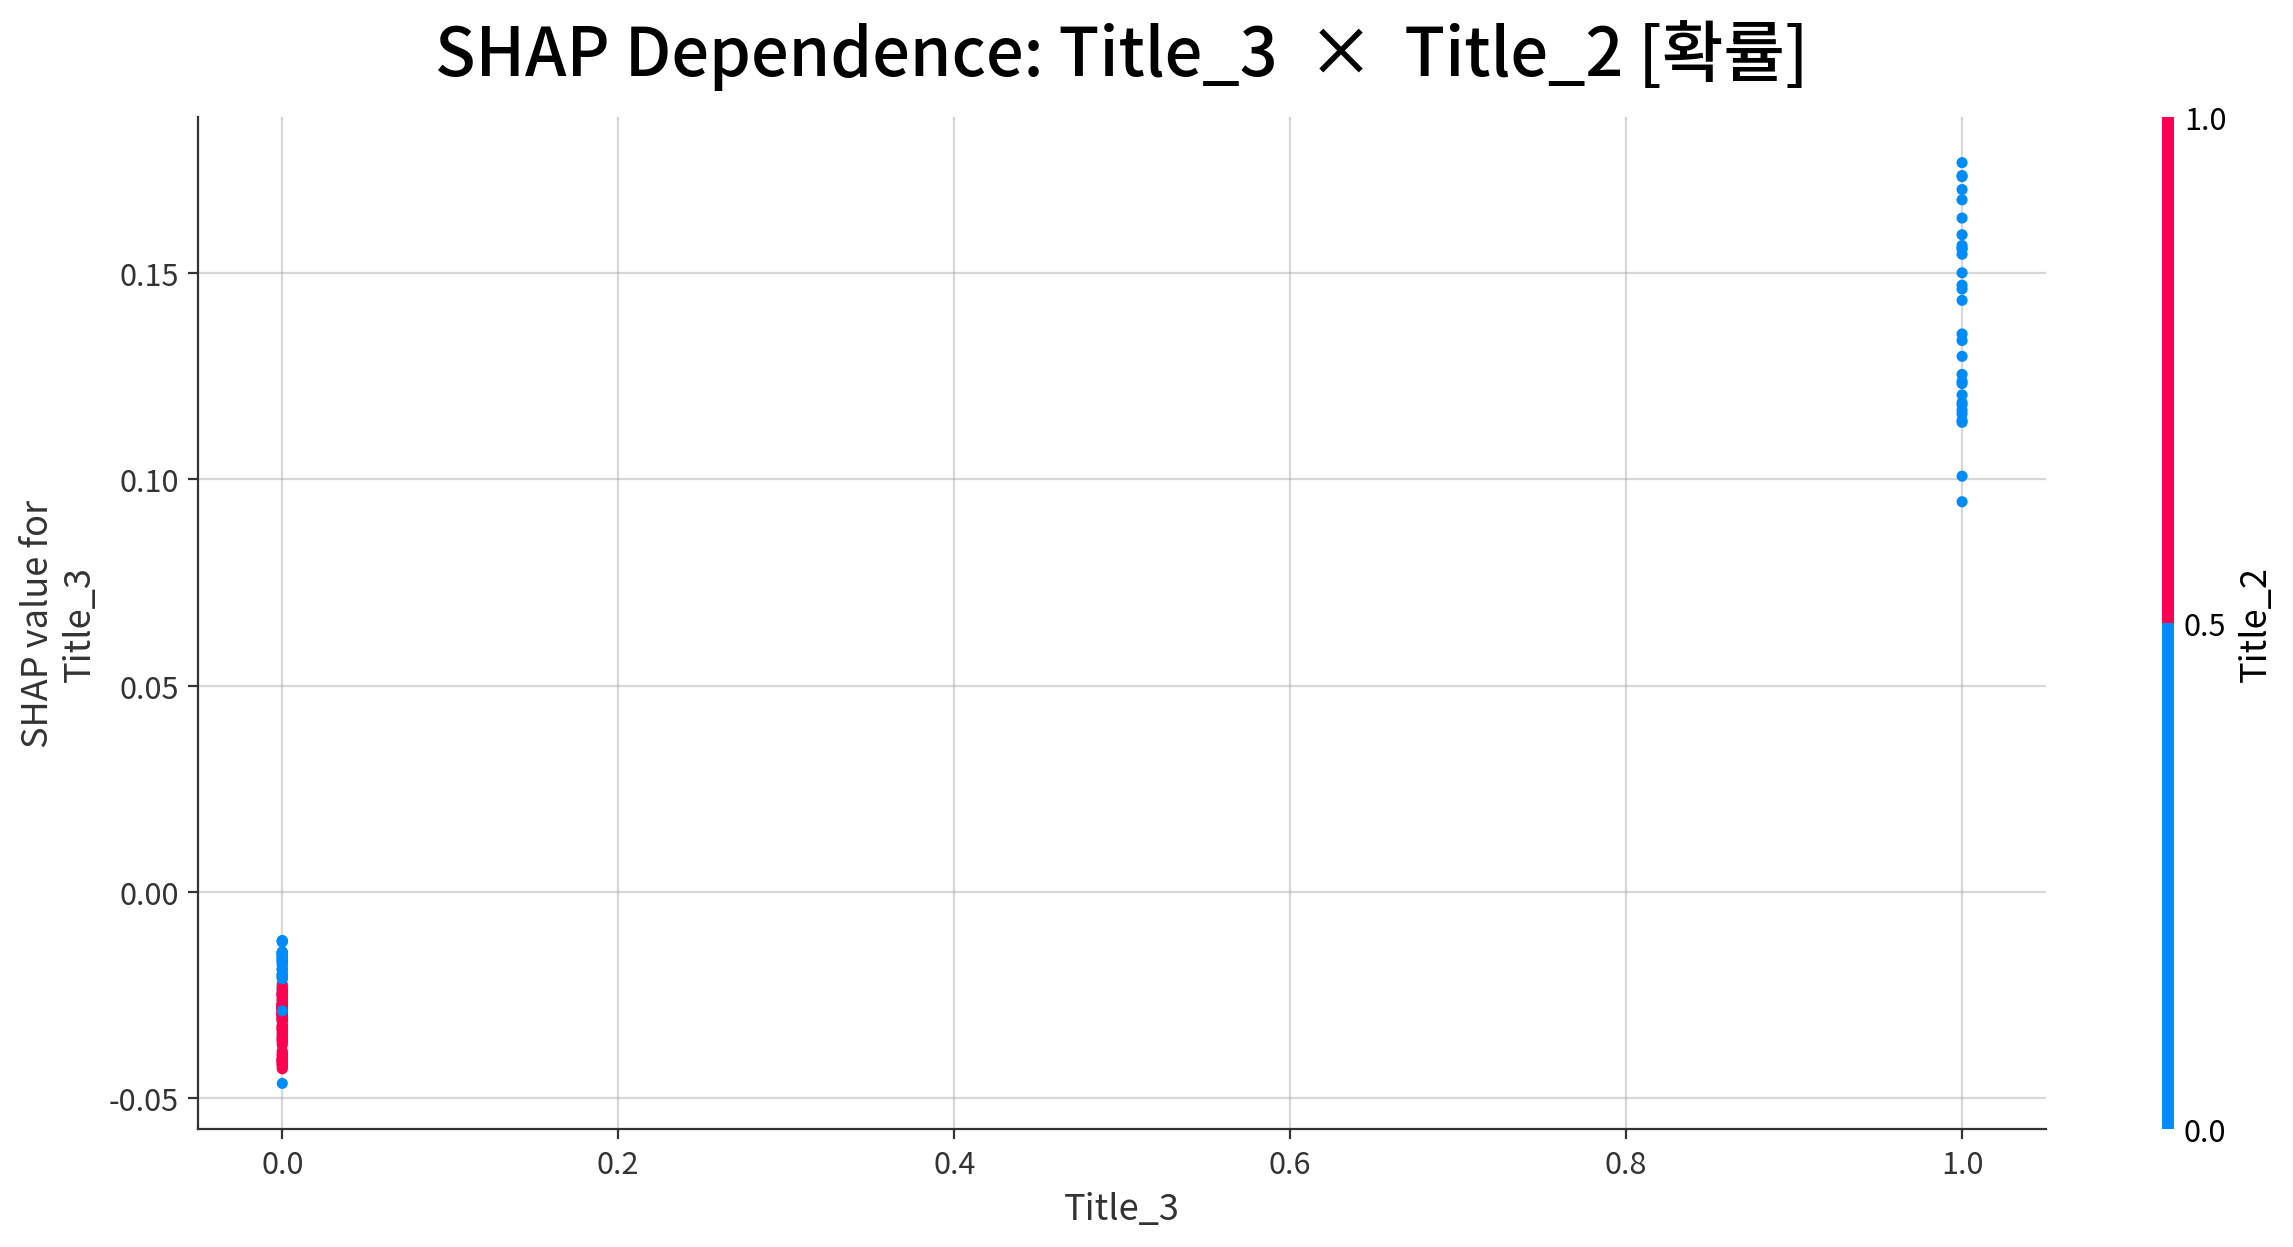

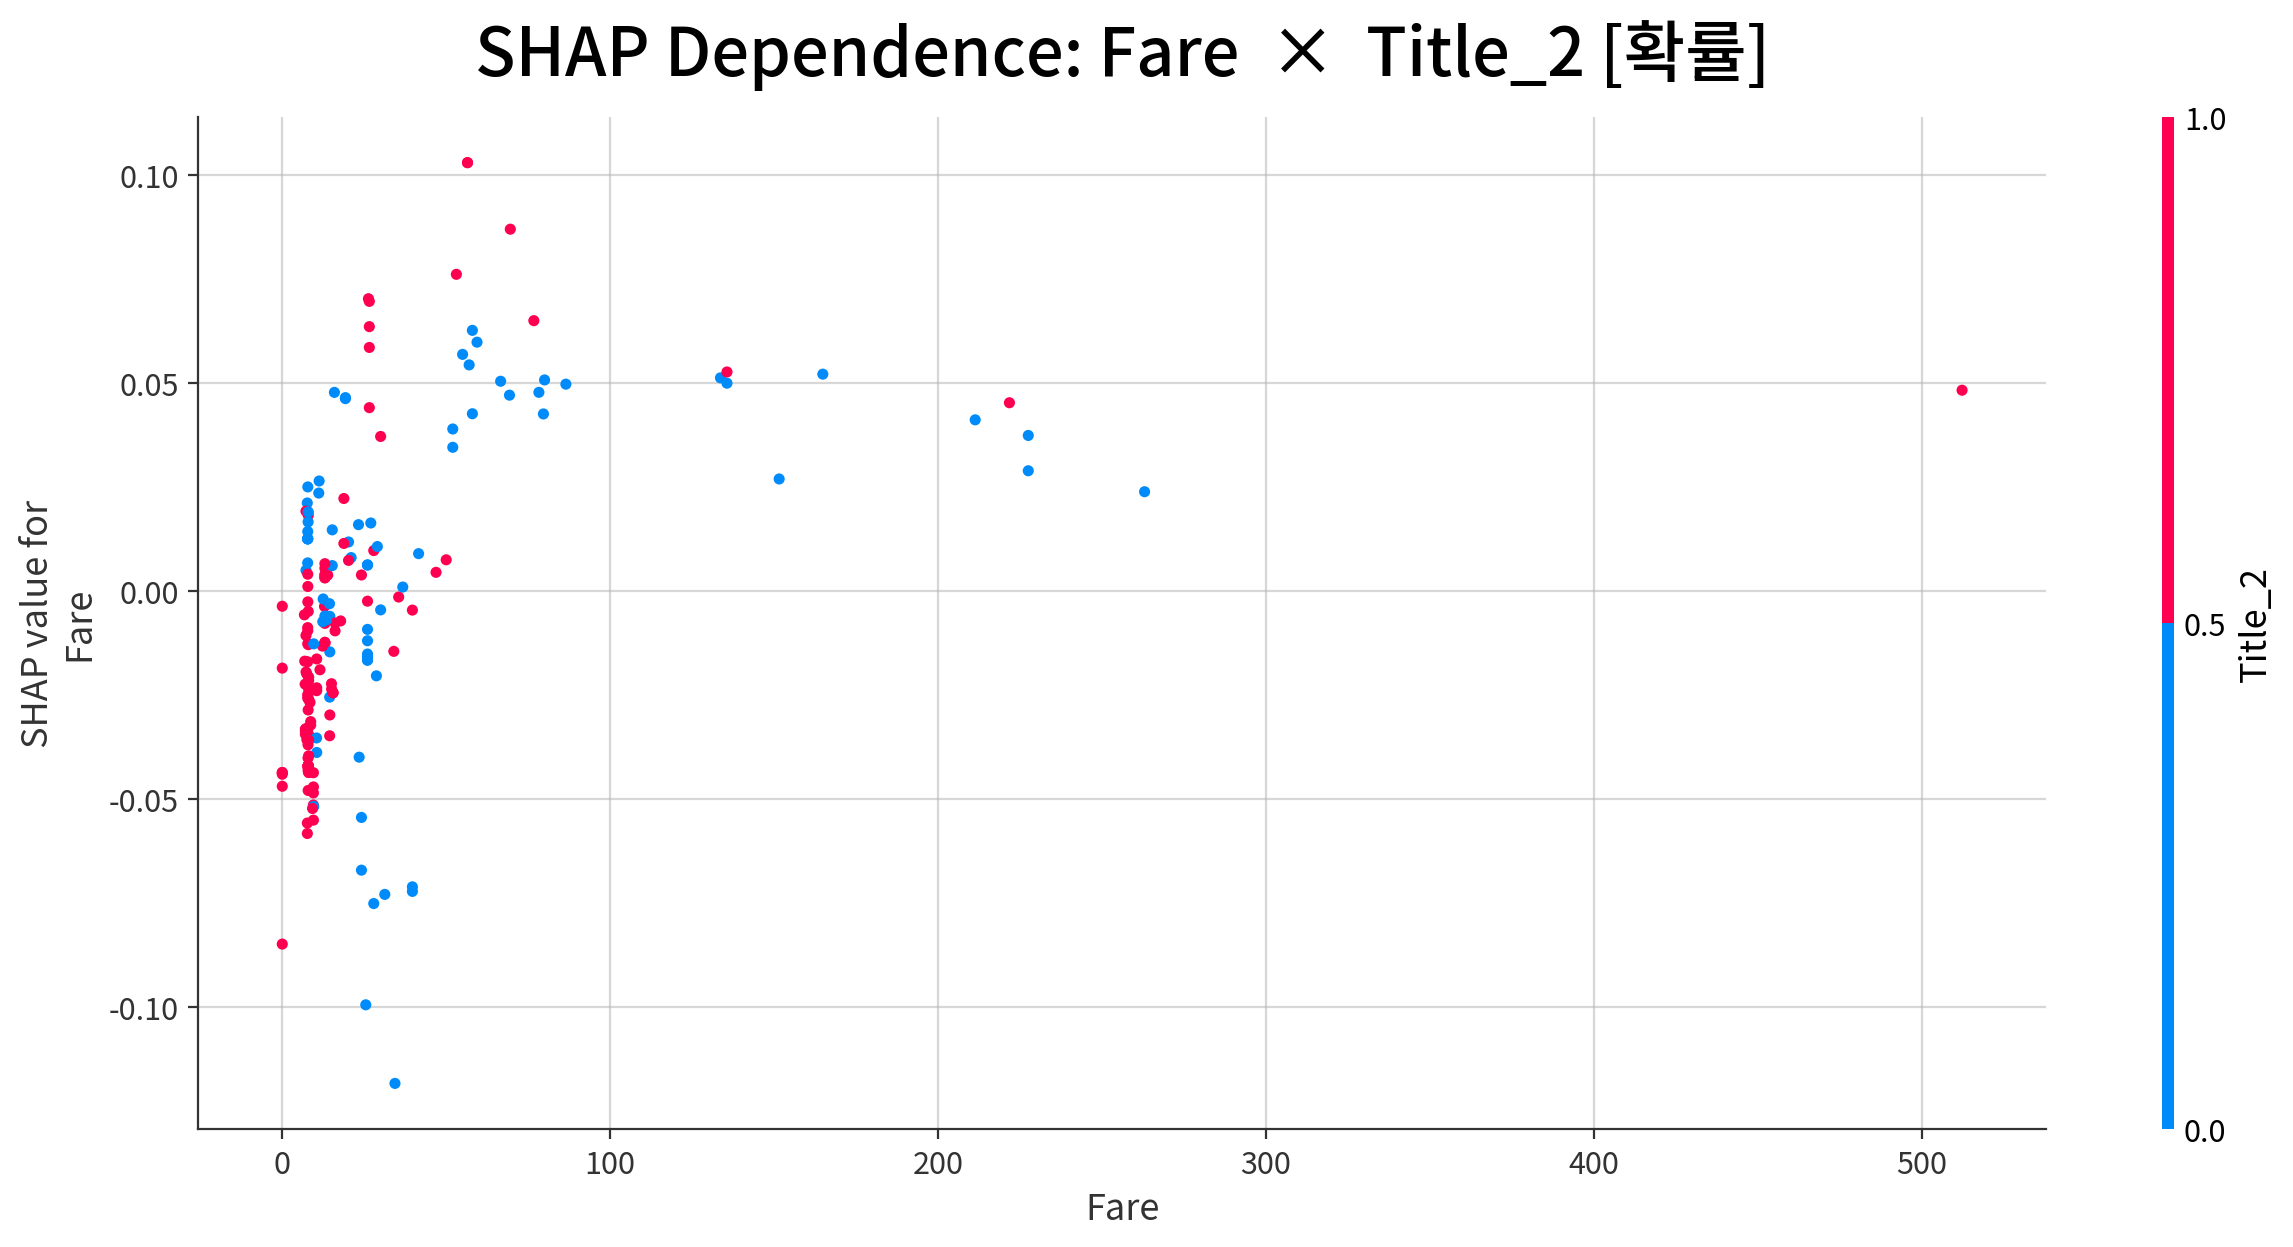

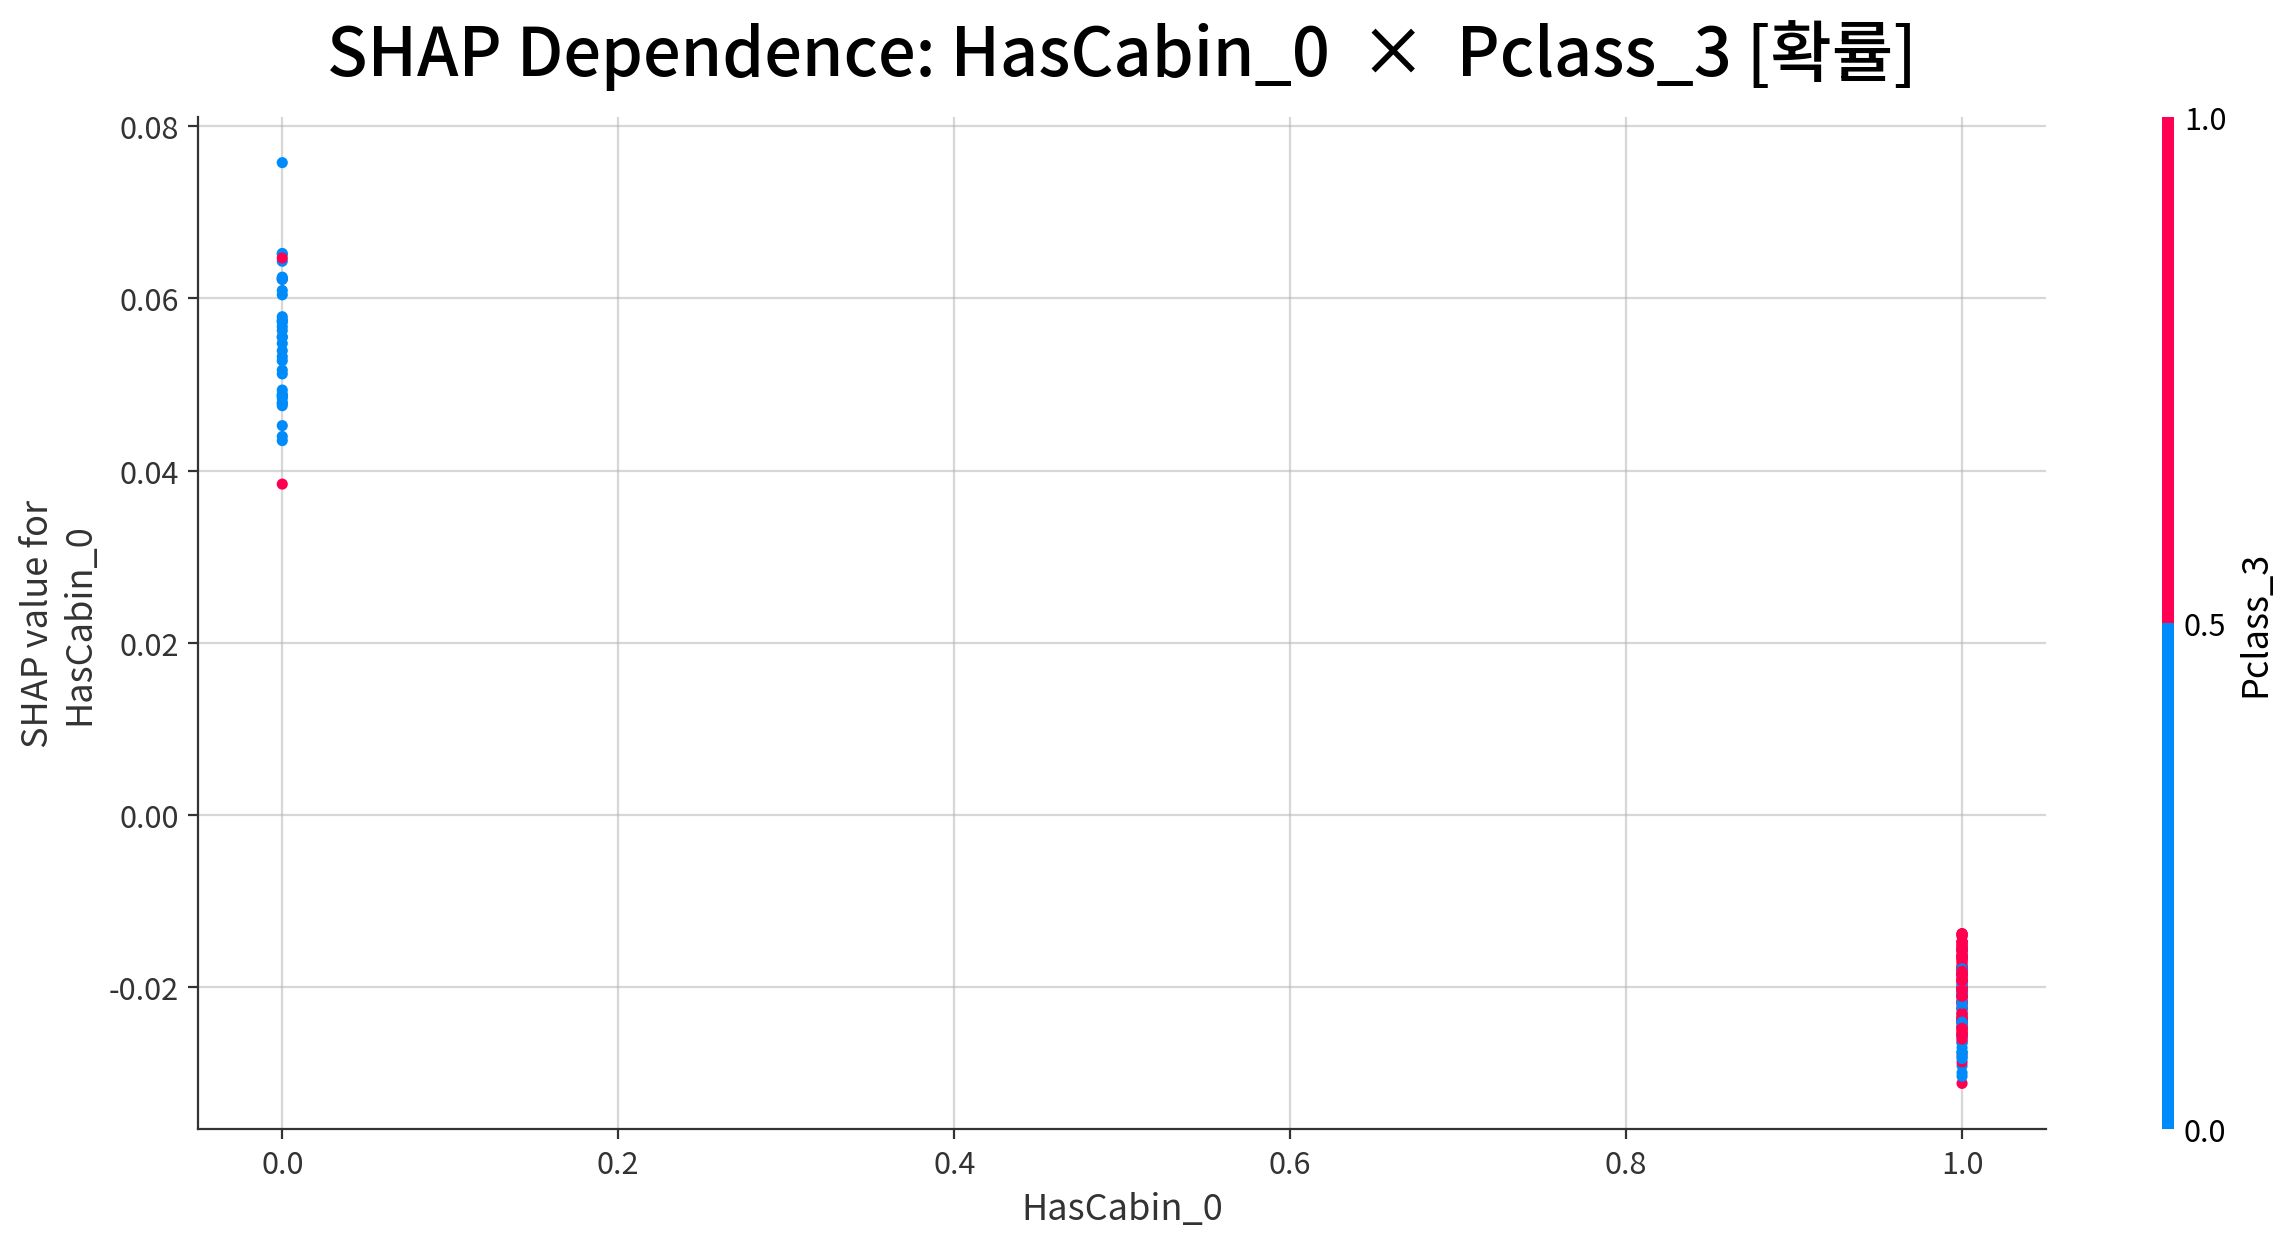

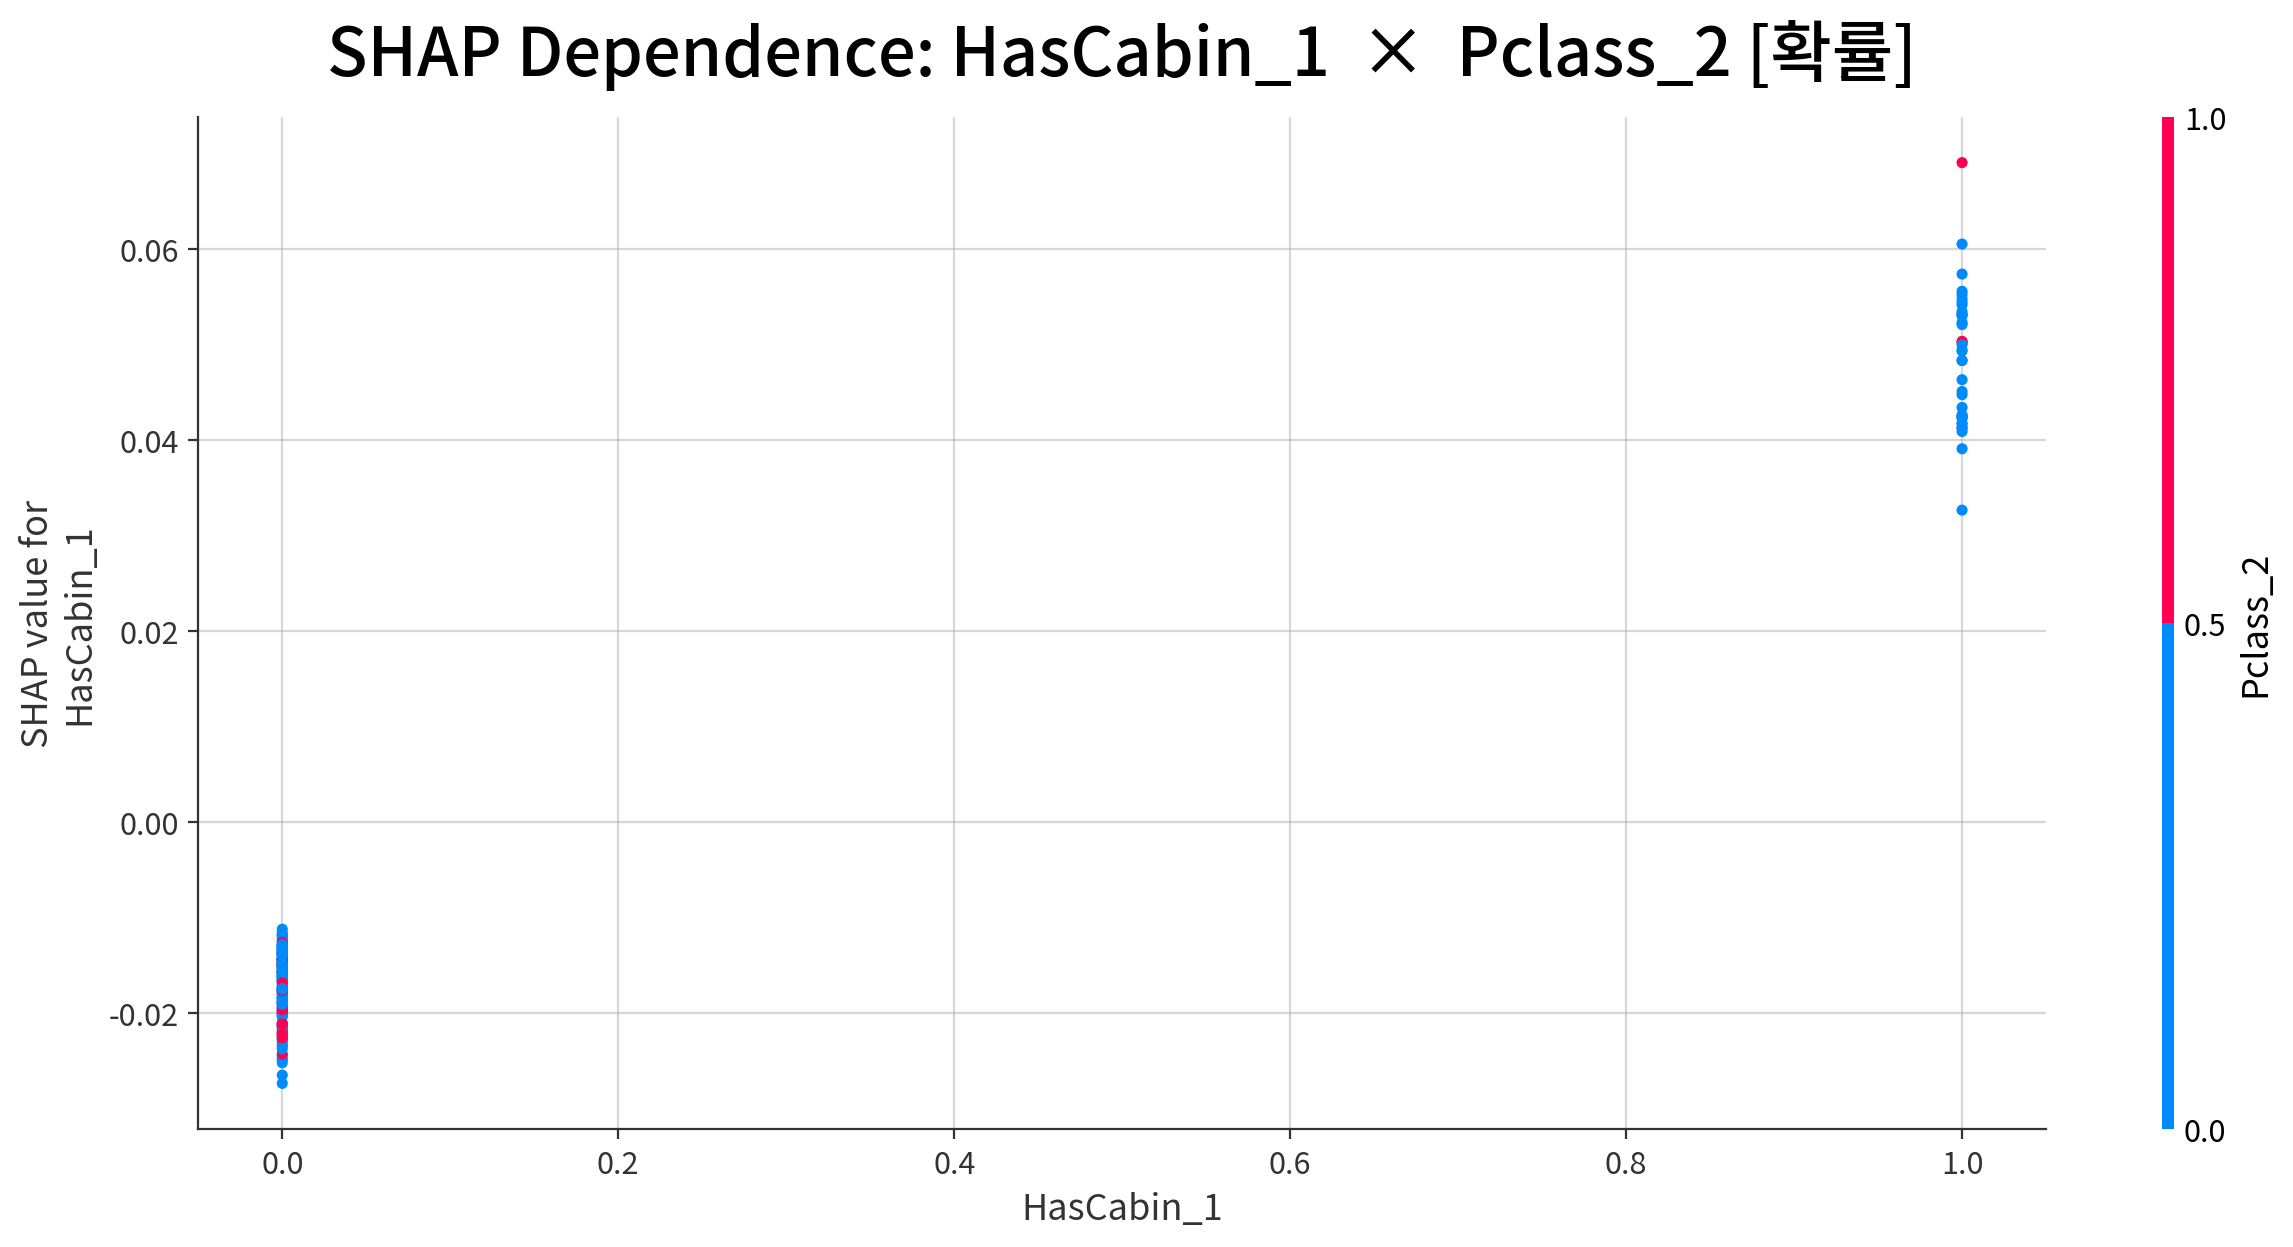

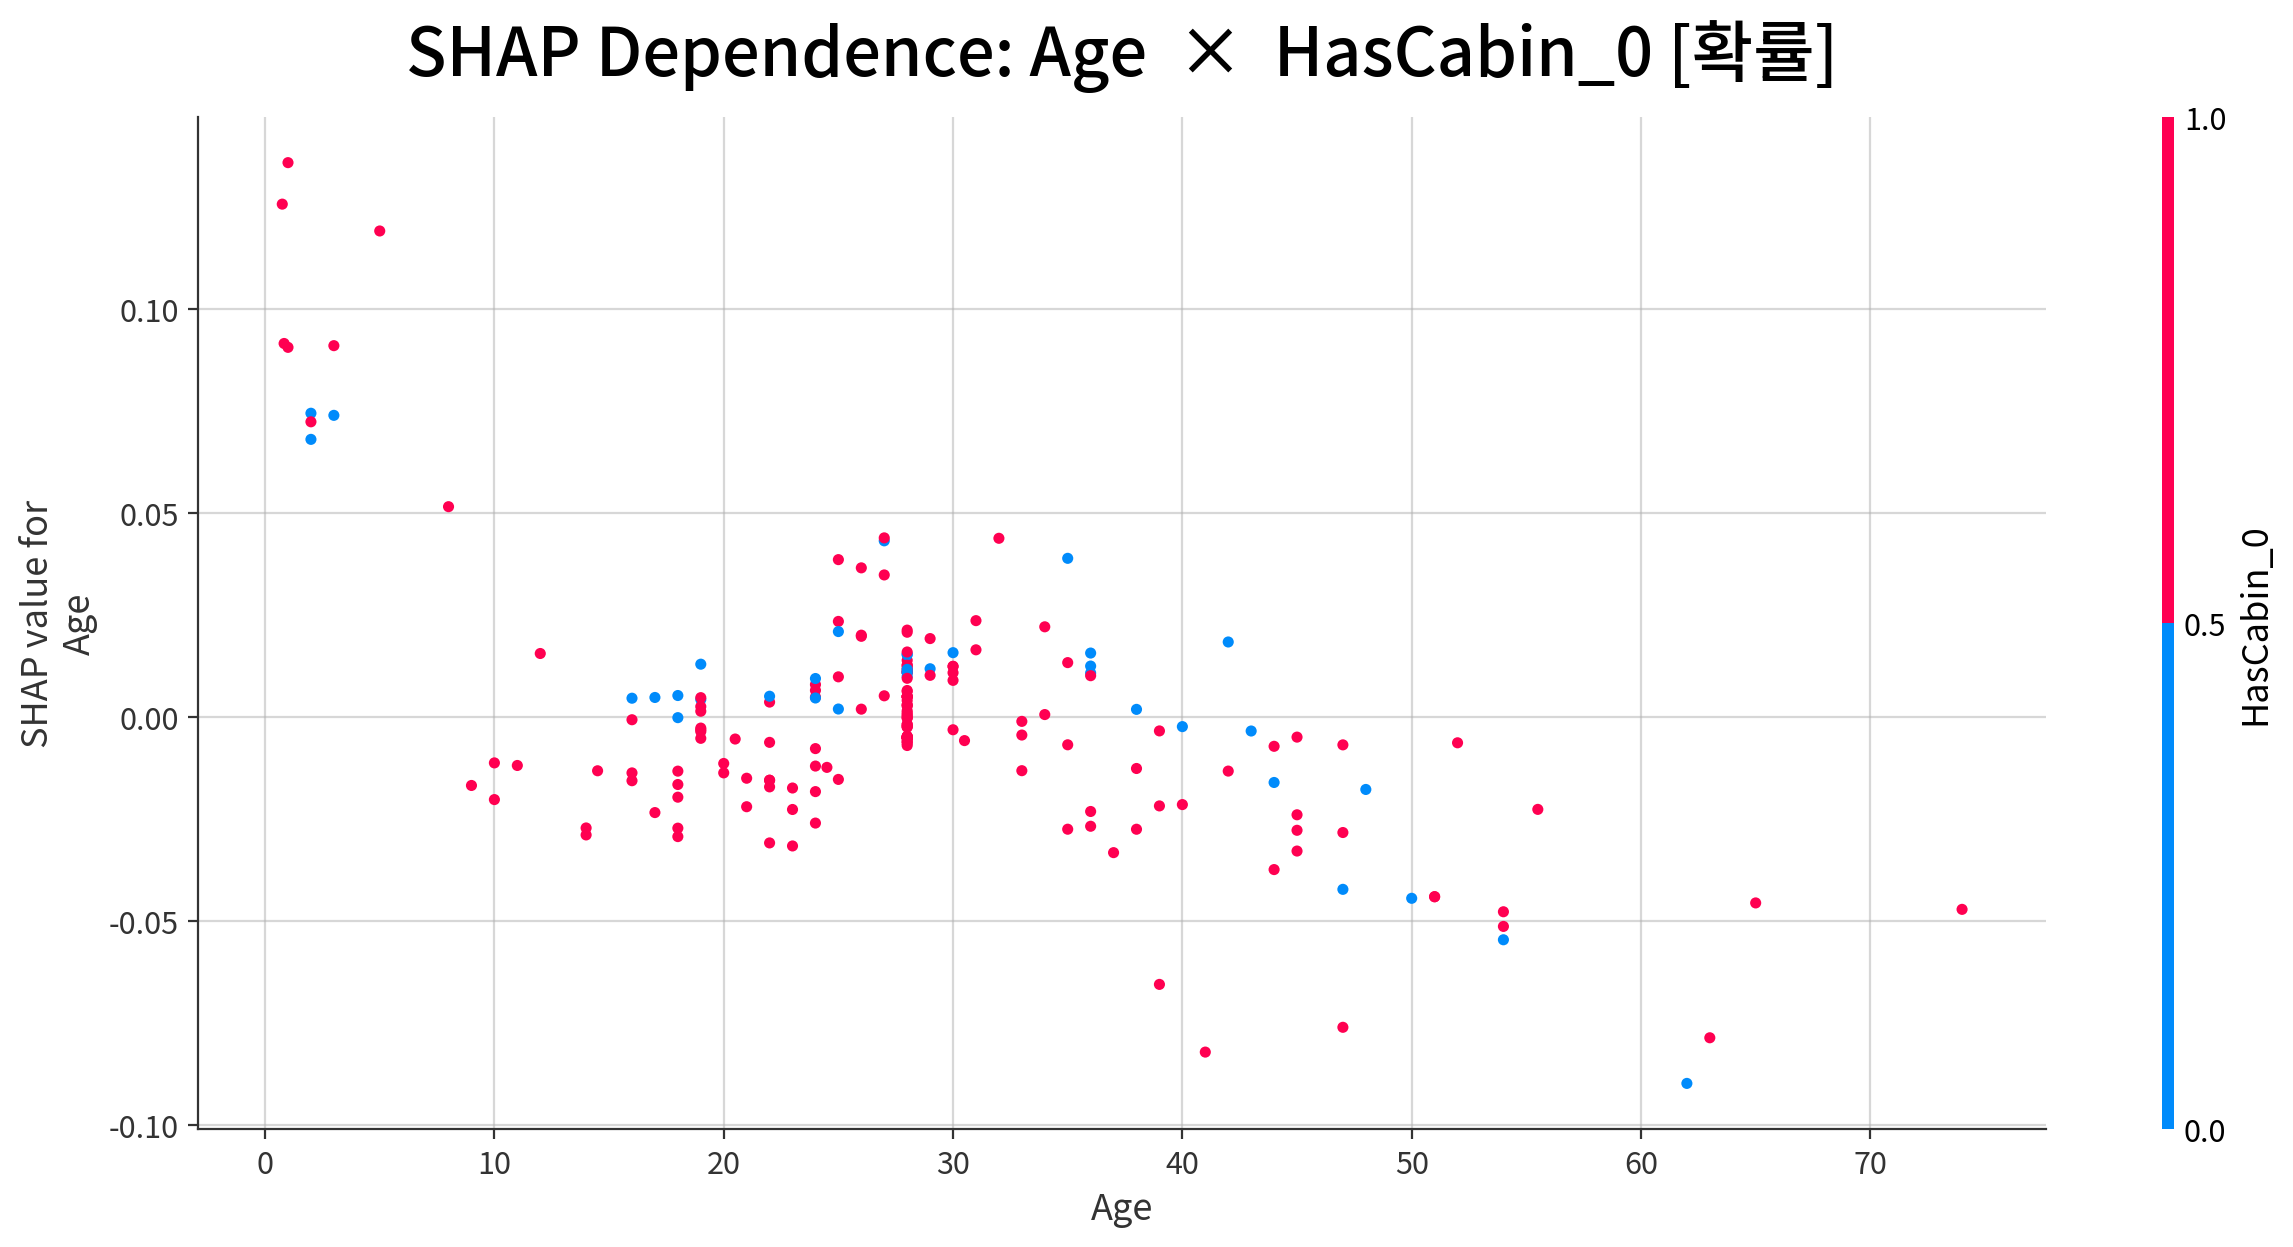

[{'feature': 'Title_2', 'interaction_feature': 'Pclass_2'},
 {'feature': 'Title_1', 'interaction_feature': 'Title_3'},
 {'feature': 'Pclass_3', 'interaction_feature': 'Title_2'},
 {'feature': 'Title_3', 'interaction_feature': 'Title_2'},
 {'feature': 'Fare', 'interaction_feature': 'Title_2'},
 {'feature': 'HasCabin_0', 'interaction_feature': 'Pclass_3'},
 {'feature': 'HasCabin_1', 'interaction_feature': 'Pclass_2'},
 {'feature': 'Age', 'interaction_feature': 'HasCabin_0'}]

In [85]:
# 데이터는 shap.attrs 에서 읽으므로 훈련데이터를 넘기지 않는다.
# features 를 비워야 cum_ratio/top_k 자동선정이 동작한다.
my_ml.shap_dependence_plot(shap)


##### 특성별 SHAP 분포와 해석 범위

**호칭과 객실 등급:** Mr 더미가 1인 경우에는 음의 기여, Miss·Mrs 더미가 1인 경우에는 양의 기여가 주로 관찰되었다. 3등급도 음의 기여 쪽에 분포했다. 호칭 더미들은 서로 배타적이므로 점의 색 분리에는 인코딩 구조와 변수 간 의존성도 반영된다. 이를 독립적인 인과효과나 구체적인 구조 순서로 읽지 않았다.

**요금:** Fare 약 0~50 구간은 양·음 기여가 섞여 있고, 같은 요금에서도 호칭 등 다른 특성에 따라 기여가 달랐다. 높은 요금 관측치에서는 양의 기여가 주로 나타났지만, 요금이 증가할수록 기여가 항상 커지는 단조관계는 아니었다. 고액 구간의 표본도 적으며 Fare는 로그값이 아닌 원래 금액이다.

**연령:** 어린 연령의 일부 관측치는 양의 기여가 컸고, 고연령 관측치는 주로 음의 기여를 보였다. 그러나 성인 구간에서는 양·음이 혼재하여 연령만으로 생존 예측을 결정할 수 없다. 28세 부근에는 결측 대체된 표본도 포함된다. 단변량 검정에서 Age가 유의하지 않았어도 다변량 모델 안에서 기여가 관찰될 수 있다는 점을 보여주며, 이것이 인과효과의 증거는 아니다.

**객실 번호 기록 유무:** 기록이 있는 집단은 양의 기여, 없는 집단은 음의 기여 쪽에 분포했다. 객실 등급·요금 등과 공유하는 정보를 고려해야 하며, 기록이 없는 승객에게 실제 객실이 없었다는 뜻으로 해석하지 않았다.

FamilySize와 Embarked는 축소 모델에 포함되지 않아 SHAP 대상에서도 제외됐다. 따라서 그 변수들이 생존과 무관하다고 결론 내릴 수 없다. 중요도 누적 90%의 SHAP 채택·탈락 표시는 설명 표시 기준이며, 여기서 모델을 다시 축소하거나 학습한 것은 아니다. 전체 결과는 200건의 훈련 표본에서 학습된 모델을 설명한 것으로 역사적 사건의 원인이나 개입 효과를 증명하지 않는다.


### 변수 축소 전후 내부 검증 지표

아래 표는 저장된 7변수·5변수 RandomForest의 동일 검증셋 지표를 나란히 제시한다.


In [86]:
# 재학습 없이 이번에 저장한 모델의 내부 검증 지표만 비교한다.
assert len(model_data) == 891 and len(x_train) == 712 and len(x_test) == 179
assert set(x_train.index).isdisjoint(x_test.index)
rf_full = my_ml.load_model("titanic_train891/tune/randomforest.pkl")
full_score = my_ml.cls_score(rf_full, x_test, y_test).iloc[0].to_dict()
selected_score = my_ml.cls_score(gs, x_te, y_test).iloc[0].to_dict()
comparison = DataFrame([full_score, selected_score],
    index=["RandomForest: 7개 입력", f"RandomForest: 선택 {len(selected)}개 입력"])
display(comparison)
print("이번 선택 변수:", selected)
print("위 수치는 반복 참조한 내부 검증셋 성능이며 Kaggle 비공개 테스트 점수가 아닙니다.")


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC
RandomForest: 7개 입력,0.810,0.797,0.681,0.734,0.860,0.841,0.433,0.592
RandomForest: 선택 5개 입력,0.793,0.767,0.667,0.713,0.845,0.826,0.455,0.556


이번 선택 변수: ['Title', 'Fare', 'Pclass', 'Age', 'HasCabin']
위 수치는 반복 참조한 내부 검증셋 성능이며 Kaggle 비공개 테스트 점수가 아닙니다.


<a id="conclusion"></a>

## 7. 종합 결론과 한계

### 분석 질문에 대한 답

**승객 특성과 생존의 관계:** 여성·여성 호칭 집단과 높은 객실 등급의 표본 생존율이 높았다. 가족 규모는 단독 승객보다 2~4명 집단의 생존율이 높았지만 큰 가족에서는 낮아져 단순 선형관계가 아니었다. 이 결과는 표본 내 연관성이지 실제 대피 행동의 인과효과가 아니다.

**예측 성능:** 동일한 내부 검증 179건에서 튜닝 KNN이 F1 0.773·정확도 83.2%·ROC-AUC 0.863으로 비교표 1위였다. 다만 LogLoss 1.710은 확률 예측을 그대로 활용하기에는 추가 검증이 필요함을 보여준다. RandomForest 7변수 모델은 F1 0.734로 낮지만 LogLoss 0.433으로 확률 출력 가능 튜닝 모델 중 가장 낮았다. 한 가지 지표를 모든 목적에서의 우수성으로 확대하지 않았다.

**변수 축소의 효과:** 누적 MDI 90% 기준으로 5개 변수를 선택했지만 F1 0.7344→0.7132, ROC-AUC 0.8598→0.8455, 정확도 81.01%→79.33%로 하락했다. 따라서 이번 축소를 성능 개선이나 성능 보존에 성공한 결과로 채택하지 않았다. RandomForest 계열에서는 성능 보존 관점에서 7개 입력을 유지하는 판단이 타당하다.

**예측 근거:** 5변수 RandomForest의 SHAP에서는 호칭이 가장 큰 기여를 보였고 객실 등급·요금·연령·객실 정보 기록 유무도 활용되었다. Mr 해당 관측치와 3등급은 주로 음의 기여, Miss·Mrs 해당 관측치는 주로 양의 기여를 보였다. 이것은 해당 축소 모델의 설명이며 KNN 또는 7변수 모델에 그대로 적용할 수 없다.

### 분석의 한계

- **데이터 범위:** 공개 학습 표본 891건의 결과이며 전체 탑승자·다른 사고·현대 집단으로 일반화할 수 없다. 정답 비공개 418건은 사용하지 않았다.
- **결측과 희소성:** Age 177건의 중앙값 대체가 분포와 해석에 영향을 준다. EDA의 Embarked 결측 2건은 잔존하여 승선항 분석은 889건 기준이다. 모델링은 별도 파이프라인으로 결측을 처리했다. 희소 호칭과 큰 가족 집단은 추정 변동성이 크다.
- **평가 독립성:** 동일한 내부 검증셋을 여러 모델 비교에 반복 참조했다. 튜닝 후 진단 CV는 중첩 교차검증이 아니며, 변수 선택 후 CV도 선택 절차 전체를 독립적으로 검증한 점수가 아니다. Kaggle 비공개 테스트 점수나 독립 최종 평가로 표현하지 않는다.
- **설명 범위:** MDI는 변수의 분할 후보 수·정보 중복 영향을 받는다. SHAP은 훈련 표본 200건의 모델 예측 설명이며 통계적 인과효과가 아니다. 성별 단독 모델 대비 Title의 추가 성능을 분리 검증하지 않았다.

### 프로젝트에서 얻은 인사이트

모델의 복잡도나 튜닝 시간보다 동일한 평가 조건에서 확인한 결과가 중요했다. KNN은 F1에서 우수했지만 확률 품질의 한계가 있었고, 중요도가 높은 변수만 남기는 간소화도 성능을 유지하지 못했다. 이 프로젝트는 가장 높은 점수만 제시하는 대신 **분류·확률 지표의 차이, 간소화에 따른 손실, 예측 설명의 적용 범위**를 함께 제시했다.

### 실행 환경과 자료

Python 3.13, pandas, NumPy, SciPy, statsmodels, scikit-learn, XGBoost, LightGBM, CatBoost, SHAP, matplotlib·seaborn, jussam 및 로컬 helpers를 사용했다. 모델 파일은 `titanic_train891/baseline/`, `titanic_train891/tune/`, `titanic_train891/importance/`에 저장했다. 본 노트북에는 실행된 표와 그래프가 포함되어 있으며, 코드를 재실행하려면 호환되는 로컬 helpers와 관련 패키지가 필요하다.

- [Kaggle Titanic: 데이터와 문제 정의](https://www.kaggle.com/competitions/titanic/data)
- [jussam 로더가 안내하는 데이터 배포본](https://www.kaggle.com/datasets/yasserh/titanic-dataset)
